# **Clasificación de Alimentos Antiinflamatorios mediante Machine Learning**

**Dataset:** USDA FoodData Central — SR Legacy  
**Problema:** Clasificación binaria supervisada  
**Variable objetivo:** `es_antiinflamatorio`

---

## Hoja de ruta

| Paso | Descripción |
|------|-------------|
| 1 | Selección y carga del dataset |
| 2 | Revisión inicial de la estructura |
| 3 | Identificación de la variable objetivo |
| 4 | Construcción del dataset integrado |
| 5 | Limpieza de datos |
| 6 | Transformaciones y construcción de la variable objetivo |
| 7 | Análisis exploratorio de datos (EDA) |
| 8 | Selección de variables |
| 9 | División en conjuntos de entrenamiento y prueba |
|10 | Construcción del pipeline de preprocesamiento |
 |11|Elección y justificación de modelos |
|12|  Entrenamiento de modelos |
|13| Evaluación con métricas |
 |14| Validación cruzada |
 |15|Visualización de resultados e interpretación |
 |16|Guardado de los modelos entrenados|
 |17| Conclusiones finales |
 |18| Anexo |


---

## **1. Selección y Carga del Dataset**

### Origen del dataset

Se utilizó el dataset **SR Legacy** de [USDA FoodData Central](https://fdc.nal.usda.gov/download-datasets), una base de datos oficial del Departamento de Agricultura de los Estados Unidos (USDA) con información nutricional estandarizada de **7.793 alimentos** entre crudos, procesados y preparados.

La base está organizada en múltiples archivos CSV relacionados por un identificador único (`fdc_id`). Los archivos utilizados fueron:

| Archivo | Contenido |
|---------|-----------|
| `food.csv` | Información general de cada alimento |
| `food_nutrient.csv` | Nutrientes y cantidades por alimento |
| `nutrient.csv` | Descripción y unidad de cada nutriente |
| `food_category.csv` | Categorías alimentarias |

Estos archivos fueron seleccionados porque contienen la información necesaria para construir variables nutricionales y analizar perfiles alimentarios.

### Pregunta de investigación

> ¿Puede el Machine Learning identificar alimentos con perfiles antiinflamatorios utilizando únicamente información nutricional?

La inflamación crónica es un factor de riesgo ampliamente reconocido en el desarrollo de enfermedades metabólicas y cardiovasculares, como la diabetes tipo 2, la obesidad y el síndrome metabólico. En este contexto, la dieta desempeña un rol clave en la modulación de los procesos inflamatorios sistémicos.

No obstante, la evaluación del potencial inflamatorio de un alimento resulta compleja cuando se realiza de manera manual, ya que requiere el análisis simultáneo de múltiples nutrientes y de sus interacciones, lo que dificulta su escalabilidad y estandarización.

En este trabajo, la variable objetivo `es_antiinflamatorio` será construida a partir del **Índice Inflamatorio Dietético (DII)**, validado en más de 200 estudios clínicos (Shivappa et al., 2014), utilizado para estimar el efecto inflamatorio de la dieta a partir de su composición nutricional.

### Justificación del dataset

- Fuente oficial con datos verificados y estandarizados.
- Formato tabular con variables numéricas continuas, adecuado para ML.
- Tamaño adecuado: 7.793 registros y 17 variables predictoras.
- Requiere integración de múltiples tablas relacionadas.
- Vinculado a un problema real de nutrición y salud pública.

Este dataset permite plantear un problema de **clasificación binaria supervisada**, donde el objetivo será identificar si un alimento presenta un perfil antiinflamatorio a partir de su composición nutricional. En etapas posteriores se evaluarán modelos como Regresión Logística, KNN, Árboles de Decisión y Random Forest.

### 1.1 Preparación del entorno de trabajo

In [2]:
# Librerías para manipulación de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Librerías para preprocesamiento y modelado
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Librerías de Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Librerías del sistema
import os

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


### 1.2 Carga del dataset desde Google Drive

In [3]:
# Montar Google Drive para acceder a los archivos CSV del dataset
from google.colab import drive
drive.mount('/content/drive')

# Verificar que los archivos estén disponibles en la carpeta de trabajo
carpeta = "/content/drive/MyDrive/ML/DATASET"
os.listdir(carpeta)

Mounted at /content/drive


['food.csv',
 'food_nutrient.csv',
 'nutrient.csv',
 'food_category.csv',
 'sr_legacy_food.csv',
 'retention_factor.csv',
 'food_nutrient_derivation.csv',
 'food_update_log_entry.csv',
 'food_portion.csv',
 'food_protein_conversion_factor.csv',
 'measure_unit.csv',
 'food_nutrient_source.csv',
 'food_nutrient_conversion_factor.csv',
 'food_calorie_conversion_factor.csv',
 'food_attribute.csv',
 'food_attribute_type.csv',
 'all_downloaded_table_record_counts.csv',
 'Download & API Field Descriptions-2019-10-11-16-22.xlsx']

In [4]:
# Definir las rutas a cada archivo del dataset
ruta_food          = f'{carpeta}/food.csv'
ruta_food_nutrient = f'{carpeta}/food_nutrient.csv'
ruta_nutrient      = f'{carpeta}/nutrient.csv'
ruta_food_category = f'{carpeta}/food_category.csv'

# Cargar cada archivo en un DataFrame separado
df_food          = pd.read_csv(ruta_food)
df_food_nutrient = pd.read_csv(ruta_food_nutrient)
df_nutrient      = pd.read_csv(ruta_nutrient)
df_food_category = pd.read_csv(ruta_food_category)

print("✅ Archivos cargados correctamente.")

# Mostrar las primeras filas de cada tabla para verificar el contenido
print("\n--- Tabla: Alimentos ---")
display(df_food.head(3))

print("\n--- Tabla: Nutrientes asociados a los alimentos ---")
display(df_food_nutrient.head(3))

print("\n--- Tabla: Descripciones de los nutrientes ---")
display(df_nutrient.head(3))

print("\n--- Tabla: Categorías Alimentarias ---")
display(df_food_category.head(3))

✅ Archivos cargados correctamente.

--- Tabla: Alimentos ---


,fdc_id,data_type,description,food_category_id,publication_date
0,167512,sr_legacy_food,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",18,2019-04-01
1,167513,sr_legacy_food,"Pillsbury, Cinnamon Rolls with Icing, refriger...",18,2019-04-01
2,167514,sr_legacy_food,"Kraft Foods, Shake N Bake Original Recipe, Coa...",18,2019-04-01



--- Tabla: Nutrientes asociados a los alimentos ---


,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,1283674,167512,1003,5.88,1,46.0,NaN,NaN,NaN,NaN,NaN
1,1283675,167512,1007,3.50,1,46.0,NaN,NaN,NaN,NaN,NaN
2,1283676,167512,1062,1286.00,0,49.0,NaN,NaN,NaN,NaN,NaN



--- Tabla: Descripciones de los nutrientes ---


,id,name,unit_name,nutrient_nbr,rank
0,2047,Energy (Atwater General Factors),KCAL,957.0,280.0
1,2048,Energy (Atwater Specific Factors),KCAL,958.0,290.0
2,1001,Solids,G,201.0,200.0



--- Tabla: Categorías Alimentarias ---


,id,code,description
0,1,100,Dairy and Egg Products
1,2,200,Spices and Herbs
2,3,300,Baby Foods


---

## **2. Revisión Inicial de la Estructura**

Antes de realizar la integración de datos, se llevó a cabo una revisión inicial de la estructura de los DataFrames para comprender la información disponible en cada archivo. En esta etapa se analizaron la cantidad de filas y columnas, los nombres de las variables, los tipos de datos y la presencia de valores faltantes. Esta inspección permitió detectar posibles inconsistencias y preparar los datos para las siguientes etapas del análisis.


In [5]:
# Agrupar los DataFrames en un diccionario para iterar sobre ellos de forma compacta.
# Esto evita repetir el mismo bloque de código cuatro veces.
archivos = {
    'Alimentos'          : df_food,
    'Nutrientes asociados' : df_food_nutrient,
    'Descripción de Nutrientes'      : df_nutrient,
    'Categorías alimentarias' : df_food_category,
}

# Recorrer cada par (nombre, DataFrame) e imprimir un resumen estructurado
# usando un bucle for
for nombre, df in archivos.items():
    print(f"{'='*55}")
    print(f"  {nombre}")
    print(f"{'='*55}")

    # shape devuelve una tupla (filas, columnas)
    print(f"Dimensiones : {df.shape[0]} filas × {df.shape[1]} columnas")

    print(f"\nColumnas disponibles:")
    # .columns.tolist() convierte el índice de columnas en una lista
    print(df.columns.tolist())

    print(f"\nTipos de datos:")
    # .dtypes muestra el tipo de dato de cada columna (int64, float64, object, etc.)
    print(df.dtypes)

    print(f"\nValores faltantes por columna:")
    # .isnull().sum() cuenta cuántos NaN hay en cada columna
    print(df.isnull().sum())
    print("=" * 90)
    print(f"\nPrimeras filas:")
    display(df.head(3))
    print()
    print("=" * 90)

  Alimentos
Dimensiones : 7793 filas × 5 columnas

Columnas disponibles:
['fdc_id', 'data_type', 'description', 'food_category_id', 'publication_date']

Tipos de datos:
fdc_id               int64
data_type           object
description         object
food_category_id     int64
publication_date    object
dtype: object

Valores faltantes por columna:
fdc_id              0
data_type           0
description         0
food_category_id    0
publication_date    0
dtype: int64

Primeras filas:


,fdc_id,data_type,description,food_category_id,publication_date
0,167512,sr_legacy_food,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",18,2019-04-01
1,167513,sr_legacy_food,"Pillsbury, Cinnamon Rolls with Icing, refriger...",18,2019-04-01
2,167514,sr_legacy_food,"Kraft Foods, Shake N Bake Original Recipe, Coa...",18,2019-04-01



  Nutrientes asociados
Dimensiones : 644125 filas × 11 columnas

Columnas disponibles:
['id', 'fdc_id', 'nutrient_id', 'amount', 'data_points', 'derivation_id', 'min', 'max', 'median', 'footnote', 'min_year_acquired']

Tipos de datos:
id                     int64
fdc_id                 int64
nutrient_id            int64
amount               float64
data_points            int64
derivation_id        float64
min                  float64
max                  float64
median               float64
footnote              object
min_year_acquired    float64
dtype: object

Valores faltantes por columna:
id                        0
fdc_id                    0
nutrient_id               0
amount                    0
data_points               0
derivation_id        181743
min                  547234
max                  547232
median               644125
footnote             643861
min_year_acquired    644125
dtype: int64

Primeras filas:


,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,1283674,167512,1003,5.88,1,46.0,NaN,NaN,NaN,NaN,NaN
1,1283675,167512,1007,3.50,1,46.0,NaN,NaN,NaN,NaN,NaN
2,1283676,167512,1062,1286.00,0,49.0,NaN,NaN,NaN,NaN,NaN



  Descripción de Nutrientes
Dimensiones : 474 filas × 5 columnas

Columnas disponibles:
['id', 'name', 'unit_name', 'nutrient_nbr', 'rank']

Tipos de datos:
id                int64
name             object
unit_name        object
nutrient_nbr    float64
rank            float64
dtype: object

Valores faltantes por columna:
id               0
name             0
unit_name        0
nutrient_nbr    12
rank            11
dtype: int64

Primeras filas:


,id,name,unit_name,nutrient_nbr,rank
0,2047,Energy (Atwater General Factors),KCAL,957.0,280.0
1,2048,Energy (Atwater Specific Factors),KCAL,958.0,290.0
2,1001,Solids,G,201.0,200.0



  Categorías alimentarias
Dimensiones : 28 filas × 3 columnas

Columnas disponibles:
['id', 'code', 'description']

Tipos de datos:
id              int64
code            int64
description    object
dtype: object

Valores faltantes por columna:
id             0
code           0
description    0
dtype: int64

Primeras filas:


,id,code,description
0,1,100,Dairy and Egg Products
1,2,200,Spices and Herbs
2,3,300,Baby Foods


### 2.1. Observaciones de la revisión inicial
El dataset de **alimentos** contiene 7.793 registros con información general como descripción, categoría y fecha de publicación, sin valores faltantes en sus variables principales.

La tabla de **nutrientes asociados** concentra más de 644 mil registros y relaciona cada alimento con múltiples nutrientes. En esta se detectó una importante cantidad de valores faltantes en variables estadísticas complementarias, algo esperable en datos nutricionales complejos. Estas columnas no serán utilizadas en este análisis.

La tabla de **descripción de nutrientes** incluye 474 nutrientes con sus respectivas unidades de medida, presentando pocos valores nulos que tampoco serán utilizados para el objetivo principal del proyecto. Finalmente, la tabla de **categorías alimentarias** contiene 28 grupos de alimentos sin datos faltantes, permitiendo clasificar los productos según su tipo alimentario.

También se identificó una estructura relacional adecuada para integrar la información nutricional mediante el identificador `fdc_id`. Esta primera inspección permitió detectar la necesidad de realizar tareas de limpieza, transformación e integración de datos para construir un dataset apto para análisis exploratorio y modelos de Machine Learning.


---

## **3. Identificación de la Variable Objetivo**

La variable objetivo de este trabajo es **`es_antiinflamatorio`**, una variable binaria que indica si un alimento tiene un perfil antiinflamatorio o proinflamatorio:

| Valor | Significado |
|-------|-------------|
| `1` | Perfil antiinflamatorio |
| `0` | Perfil proinflamatorio |

Esta variable **no existe en el dataset original** y será construida en la etapa de transformaciones (Sección 6) a partir del **Índice Inflamatorio Dietético (DII)** — un algoritmo validado en más de 200 estudios clínicos (Shivappa et al., 2014) que estima el efecto inflamatorio de la dieta mediante la ponderación de distintos nutrientes asociados a biomarcadores inflamatorios.

El DII original fue desarrollado utilizando 45 componentes dietarios entre nutrientes, compuestos bioactivos y alimentos específicos. Sin embargo, debido a las limitaciones de disponibilidad de variables en el dataset USDA SR Legacy, en este trabajo se utilizarán únicamente los nutrientes presentes en la base de datos y con evidencia reportada en el índice. De los 45 componentes originales, se identificaron **17 nutrientes disponibles** en los registros nutricionales de los alimentos, los cuales serán utilizados para construir la variable objetivo `es_antiinflamatorio`.

Por lo tanto, este trabajo plantea un problema de **clasificación binaria supervisada**.

> **Aclaración metodológica importante:** Dado que `es_antiinflamatorio` se construye directamente a partir de los mismos 17 nutrientes que luego se utilizarán como variables predictoras, el modelo de Machine Learning **no descubrirá de forma independiente** qué hace que un alimento sea antiinflamatorio. En cambio, **aprenderá a reproducir la regla de clasificación del DII adaptado** — es decir, aprenderá la combinación ponderada de nutrientes que define el índice.  Aun así, constituye un problema válido de clasificación supervisada, útil para evaluar si los algoritmos de ML pueden capturar relaciones no lineales o interacciones entre nutrientes que la fórmula lineal del DII no contempla explícitamente. Sin embargo, es importante no interpretar los resultados como un descubrimiento nutricional independiente, sino como la capacidad del modelo de aproximar una regla ya conocida.


---
## **4. Construcción del dataset integrado**

Los cuatro archivos CSV se relacionan mediante `fdc_id`. El proceso de integración consta de cuatro pasos:

1. **Filtrar** solo los 17 nutrientes del DII disponibles en el USDA.
2. **Pivotar** de formato largo (una fila por nutriente) a formato ancho (una fila por alimento).
3. **Unir** con `food.csv` para agregar nombre y categoría.
4. **Limpiar** columnas auxiliares del merge.

### 4.1 Filtrado: Selección de nutrientes relevantes.

Para ello, se creó un **diccionario** que relaciona cada `nutrient_id` con un nombre descriptivo y legible. Posteriormente, se filtró la tabla` food_nutrient `utilizando únicamente los 17 nutrientes asociados al DII presentes en la base de datos. Además, se conservaron solo las columnas necesarias para el análisis (`fdc_id`, `nutrient_id` y `amount`), reduciendo así la complejidad del dataset antes de realizar la transformación e integración de tablas.

In [6]:
# ─────────────────────────────────────────────────────────────
# PASO 1:  Diccionario nutrient_id → nombre legible
# ─────────────────────────────────────────────────────────────
# food_nutrient.csv identifica cada nutriente con un número.
# Este diccionario permite filtrar solo los 17 relevantes
# y luego renombrar las columnas con nombres comprensibles.
# ─────────────────────────────────────────────────────────────
nutrientes_dii = {
    1003: 'proteinas',
    1004: 'grasas_totales',
    1258: 'grasas_saturadas',
    1257: 'grasas_trans',
    1292: 'grasas_monoinsaturadas',
    1293: 'grasas_poliinsaturadas',
    1005: 'carbohidratos',
    2000: 'azucares',
    1079: 'fibra',
    1162: 'vitamina_c',
    1109: 'vitamina_e',
    1093: 'sodio',
    1008: 'energia_kcal',
    1090: 'magnesio',
    1087: 'calcio',
    1091: 'fosforo',
    1095: 'zinc',
}

In [7]:
# ─────────────────────────────────────────────────────────────
# PASO 2: Filtrar nutrientes relevantes para el DII
# ─────────────────────────────────────────────────────────────
# Filtrar food_nutrient — solo los nutrientes del DII
# .isin(nutrientes_dii.keys()) devuelve True para cada fila
# cuyo nutrient_id esté en la lista de IDs del diccionario nutrientes_dii.
# Seleccionar solo las 3 columnas que para el pivot:
# - fdc_id       → identificador único del alimento
# - nutrient_id  → identificador del nutriente
# - amount       → cantidad del nutriente en el alimento
# ─────────────────────────────────────────────────────────────

fn_dii = df_food_nutrient[
    df_food_nutrient['nutrient_id'].isin(nutrientes_dii.keys())
][['fdc_id', 'nutrient_id', 'amount']]

# Mostrar cantidad de filas resultantes después del filtrado
print(f"Filas después del filtro: {fn_dii.shape[0]:,}")

# Visualizar las primeras filas del dataset filtrado
print("Vista previa del formato LARGO (antes del pivot):")
display(fn_dii.head(8))

Filas después del filtro: 121,218
Vista previa del formato LARGO (antes del pivot):


,fdc_id,nutrient_id,amount
0,167512,1003,5.880
3,167512,1079,1.200
5,167512,1093,1059.000
7,167512,1257,4.412
8,167512,1258,2.941
9,167512,1004,13.240
10,167512,1005,41.180
11,167512,1008,307.000


### 4.2. Pivot: Transformación de la tabla nutricional.

La tabla `food_nutrient.cvs` se encuentra originalmente en formato largo, donde cada fila representa un nutriente asociado a un alimento. Sin embargo, para aplicar modelos de Machine Learning, se requiere una estructura en formato ancho, con **una fila por alimento y una columna por nutriente.**

Para ello, se utilizó `pivot_table`, transformando los valores de `nutrient_id `en columnas y utilizando `amount` como valor nutricional correspondiente. De esta manera, se construyó una **matriz alimento–nutriente** apta para el análisis y modelado posterior.


In [8]:
# ─────────────────────────────────────────────────────────────
# PASO 3: Transformar de formato LARGO a formato ANCHO
# ─────────────────────────────────────────────────────────────
# Se utiliza pivot_table() para reorganizar el dataset:
#
#   index='fdc_id'       → cada alimento ocupa una fila
#   columns='nutrient_id'→ cada nutriente se convierte en columna
#   values='amount'      → el valor de cada celda es la cantidad
#                          nutriente presente en el alimento
# Si un alimento no posee información para un nutriente,
# la celda queda como NaN (valor faltante), que luego será
# tratado en la etapa de limpieza y preprocesamiento.
# ─────────────────────────────────────────────────────────────

df_pivot = fn_dii.pivot_table(
    index='fdc_id',
    columns='nutrient_id',
    values='amount'
)

# Renombrar las columnas:
# Se reemplazan los IDs numéricos de nutrientes
# por nombres más interpretables usando el diccionario nutrientes_dii
df_pivot.columns = [nutrientes_dii[col] for col in df_pivot.columns]

# reset_index() convierte nuevamente fdc_id en una columna normal
# en lugar de mantenerlo como índice del DataFrame
df_pivot = df_pivot.reset_index()

# Mostrar dimensiones finales luego del pivot
print(f"\nDimensiones después del pivot: {df_pivot.shape}")

# Visualizar primeras filas del dataset en formato ancho
print("Vista previa del formato ANCHO (después del pivot):")
display(df_pivot.head(3))


Dimensiones después del pivot: (7793, 18)
Vista previa del formato ANCHO (después del pivot):


,fdc_id,proteinas,grasas_totales,carbohidratos,energia_kcal,fibra,calcio,magnesio,fosforo,sodio,zinc,vitamina_e,vitamina_c,grasas_trans,grasas_saturadas,grasas_monoinsaturadas,grasas_poliinsaturadas,azucares
0,167512,5.88,13.24,41.18,307.0,1.2,NaN,NaN,NaN,1059.0,NaN,NaN,NaN,4.412,2.941,NaN,NaN,5.88
1,167513,4.34,11.27,53.42,330.0,1.4,28.0,NaN,NaN,780.0,NaN,NaN,0.1,4.290,3.250,NaN,NaN,21.34
2,167514,6.10,3.70,79.80,377.0,NaN,NaN,NaN,NaN,2182.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4.3. Integración de tablas:

Una vez construida **la matriz alimento–nutriente**, se integró la información descriptiva de los alimentos mediante operaciones `merge`. Primero, se unió la tabla pivotada con `food.csv `utilizando `fdc_id` como clave para incorporar el nombre y la categoría de cada alimento. Posteriormente, se realizó un segundo merge con `food_category.csv `para reemplazar los identificadores numéricos de categoría por descripciones legibles.

En ambos casos se utilizó `how='left'` para conservar todos los alimentos presentes en la tabla nutricional, evitando la pérdida de registros durante el proceso de integración. Además, el parámetro `suffixes` permitió diferenciar columnas con el mismo nombre (`description`) generadas durante la integración.

In [9]:
# ─────────────────────────────────────────────────────────────
# PASO 4: Integrar información descriptiva de los alimentos
# ─────────────────────────────────────────────────────────────
# Se realiza un merge entre el dataset pivotado y la tabla
# de alimentos utilizando fdc_id como clave de unión.
#
# Del DataFrame df_food se seleccionan únicamente:
# - description       → nombre o descripción del alimento
# - food_category_id  → identificador de categoría alimentaria
#
# how='left':
# Conserva todos los alimentos presentes en df_pivot,
# incluso si alguno no encuentra coincidencia en df_food.
# ─────────────────────────────────────────────────────────────

df_integrado = df_pivot.merge(
    df_food[['fdc_id', 'description', 'food_category_id']],
    on='fdc_id',   # columna clave presente en ambos DataFrames
    how='left'
)

# Mostrar dimensiones luego de la integración
print(f"\nTras el primer merge: {df_integrado.shape}")

# Visualizar una fila del dataset integrado
print("Vista previa del merge:")
display(df_integrado.head(1))


Tras el primer merge: (7793, 20)
Vista previa del merge:


,fdc_id,proteinas,grasas_totales,carbohidratos,energia_kcal,fibra,calcio,magnesio,fosforo,sodio,zinc,vitamina_e,vitamina_c,grasas_trans,grasas_saturadas,grasas_monoinsaturadas,grasas_poliinsaturadas,azucares,description,food_category_id
0,167512,5.88,13.24,41.18,307.0,1.2,NaN,NaN,NaN,1059.0,NaN,NaN,NaN,4.412,2.941,NaN,NaN,5.88,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",18


In [10]:
# ─────────────────────────────────────────────────────────────
# PASO 5: Agregar nombre descriptivo de la categoría alimentaria
# ─────────────────────────────────────────────────────────────
# Se realiza un segundo merge para reemplazar el ID numérico
# de la categoría por un nombre más interpretable.
#
# La tabla df_food_category contiene:
# - id          → identificador de categoría
# - description → nombre de la categoría alimentaria
#
# Como las columnas clave tienen nombres distintos:
# - food_category_id en df_integrado
# - id en df_food_category
#
# se utilizan:
# - left_on  → columna del DataFrame izquierdo
# - right_on → columna del DataFrame derecho
#
# how='left':
# conserva todos los alimentos del dataset integrado.
#
# suffixes=('', '_categoria'):
# evita conflictos porque ambas tablas poseen una columna
# llamada 'description'.
#
# Luego, la nueva columna se renombra como 'categoria'
# para facilitar su interpretación.
# ─────────────────────────────────────────────────────────────

df_integrado = df_integrado.merge(
    df_food_category[['id', 'description']],
    left_on='food_category_id',
    right_on='id',
    how='left',
    suffixes=('', '_categoria')
).rename(columns={'description_categoria': 'categoria'})

# Mostrar dimensiones luego del segundo merge
print(f"Tras el segundo merge: {df_integrado.shape}")

# Visualizar una fila del dataset final integrado
print("Vista previa del merge:")
display(df_integrado.head(1))

Tras el segundo merge: (7793, 22)
Vista previa del merge:


,fdc_id,proteinas,grasas_totales,carbohidratos,energia_kcal,fibra,calcio,magnesio,fosforo,sodio,...,vitamina_c,grasas_trans,grasas_saturadas,grasas_monoinsaturadas,grasas_poliinsaturadas,azucares,description,food_category_id,id,categoria
0,167512,5.88,13.24,41.18,307.0,1.2,NaN,NaN,NaN,1059.0,...,NaN,4.412,2.941,NaN,NaN,5.88,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",18,18,Baked Products


### 4.4. Limpieza: Eliminación de columnas auxiliares y definición de variables nutricionales
Luego del proceso de integración de datos, algunas columnas utilizadas únicamente como claves de unión (`food_category_id` e `id`) dejaron de ser necesarias, ya que la información categórica había sido reemplazada por nombres descriptivos más interpretables. Por este motivo, se eliminaron las columnas auxiliares generadas durante los merge, permitiendo obtener un dataset más limpio, organizado y fácil de analizar.
Además, se definió una lista con los 17 nutrientes seleccionados para el cálculo del `Índice Inflamatorio Dietético `(DII). Esta selección permitió centralizar las variables nutricionales de interés y facilitar su reutilización en las siguientes etapas del proyecto, incluyendo limpieza de datos, análisis exploratorio, visualizaciones y modelos de Machine Learning.

In [11]:
# ─────────────────────────────────────────────────────────────
# PASO 6: Limpieza final del dataset integrado
# ─────────────────────────────────────────────────────────────
# Se eliminan columnas auxiliares utilizadas durante los merge:
#
# - food_category_id → ID numérico de categoría
# - id               → ID proveniente de food_category
#
# Estas columnas ya no son necesarias porque la categoría
# alimentaria quedó representada mediante nombres descriptivos
# en la columna 'categoria'.
# ─────────────────────────────────────────────────────────────

df_integrado = df_integrado.drop(columns=['food_category_id', 'id'])

# Confirmar estado final del dataset
print(f"\n✅ Dataset integrado listo.")
print(f"Dimensiones finales: {df_integrado.shape[0]} alimentos × {df_integrado.shape[1]} columnas")

# Mostrar nombres de columnas disponibles
print(f"\nColumnas: {df_integrado.columns.tolist()}")

# Visualizar primeras filas del dataset final
display(df_integrado.head(2))


# ─────────────────────────────────────────────────────────────
# Definición de columnas nutricionales
# ─────────────────────────────────────────────────────────────
# Se crea una lista con los 17 nutrientes seleccionados
# para el cálculo del Índice Inflamatorio Dietético (DII).
#
# Esta lista será reutilizada en etapas posteriores:
# - limpieza de datos
# - análisis exploratorio
# - visualizaciones
# - construcción del modelo de Machine Learning
# ─────────────────────────────────────────────────────────────

cols_nutrientes = [
    'proteinas', 'grasas_totales', 'carbohidratos',
    'energia_kcal', 'fibra', 'calcio', 'magnesio',
    'fosforo', 'sodio', 'zinc', 'vitamina_e',
    'vitamina_c', 'grasas_trans', 'grasas_saturadas',
    'grasas_monoinsaturadas', 'grasas_poliinsaturadas',
    'azucares'
]

# Verificar cantidad de nutrientes definidos
print(f"✅ {len(cols_nutrientes)} nutrientes definidos correctamente.")


✅ Dataset integrado listo.
Dimensiones finales: 7793 alimentos × 20 columnas

Columnas: ['fdc_id', 'proteinas', 'grasas_totales', 'carbohidratos', 'energia_kcal', 'fibra', 'calcio', 'magnesio', 'fosforo', 'sodio', 'zinc', 'vitamina_e', 'vitamina_c', 'grasas_trans', 'grasas_saturadas', 'grasas_monoinsaturadas', 'grasas_poliinsaturadas', 'azucares', 'description', 'categoria']


,fdc_id,proteinas,grasas_totales,carbohidratos,energia_kcal,fibra,calcio,magnesio,fosforo,sodio,zinc,vitamina_e,vitamina_c,grasas_trans,grasas_saturadas,grasas_monoinsaturadas,grasas_poliinsaturadas,azucares,description,categoria
0,167512,5.88,13.24,41.18,307.0,1.2,NaN,NaN,NaN,1059.0,NaN,NaN,NaN,4.412,2.941,NaN,NaN,5.88,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",Baked Products
1,167513,4.34,11.27,53.42,330.0,1.4,28.0,NaN,NaN,780.0,NaN,NaN,0.1,4.290,3.250,NaN,NaN,21.34,"Pillsbury, Cinnamon Rolls with Icing, refriger...",Baked Products


✅ 17 nutrientes definidos correctamente.


---

## **5. Limpieza de Datos**

Una vez construido el dataset integrado, es necesario verificar su calidad antes de continuar. A partir de la revisión inicial de la estructura realizada en la sección 2, se identificaron tres aspectos que requieren atención:

1. **Duplicados** — verificar si hay filas repetidas.
2. **Valores faltantes** — cuantificar los NaN y aplicar una estrategia de imputación.
3. **Valores extremos** — distinguir entre errores de carga y alimentos con composición inusual pero legítima.

### 5.1 Detección de Duplicados

Un duplicado ocurre cuando el mismo alimento aparece más de una vez con exactamente los mismos valores. Conservar duplicados inflaría artificialmente la frecuencia de esos alimentos y distorsionaría las medianas usadas en la imputación.

In [12]:
# ─────────────────────────────────────────────────────────────
# REVISIÓN DE FILAS DUPLICADAS
# ─────────────────────────────────────────────────────────────
# .duplicated() marca filas repetidas con True
# .sum() cuenta cuántas filas duplicadas existen
# ─────────────────────────────────────────────────────────────

cantidad_duplicados = df_integrado.duplicated().sum()

# Mostrar cantidad de duplicados encontrados
print(f"Filas duplicadas encontradas: {cantidad_duplicados}")

if cantidad_duplicados > 0:

    # Mostrar detalle de filas repetidas
    print("\nDetalle de filas duplicadas:")

    display(df_integrado[df_integrado.duplicated(keep=False)][
        ['fdc_id', 'description', 'categoria']
    ])

else:
    # Confirmar ausencia de duplicados
    print("✅ No hay filas duplicadas — el dataset está limpio en este aspecto.")

Filas duplicadas encontradas: 0
✅ No hay filas duplicadas — el dataset está limpio en este aspecto.


### 5.2 Análisis de Valores Faltantes

Un valor faltante (NaN) puede significar dos cosas distintas en este dataset:
- **Ausencia biológica** — el nutriente no existe en ese alimento (ej: grasas trans en una manzana).
- **Dato no registrado** — el USDA no lo midió para ese alimento.

A continuación se cuantifica la magnitud del problema por nutriente.

Filas con al menos un valor faltante: 4,736 de 7,793 (60.8%)

Detalle por columna:


,valores_faltantes,porcentaje_%
grasas_trans,3614,46.37
vitamina_e,2213,28.40
azucares,1786,22.92
fibra,562,7.21
grasas_monoinsaturadas,516,6.62
grasas_poliinsaturadas,514,6.60
vitamina_c,461,5.92
zinc,387,4.97
magnesio,372,4.77
grasas_saturadas,343,4.40


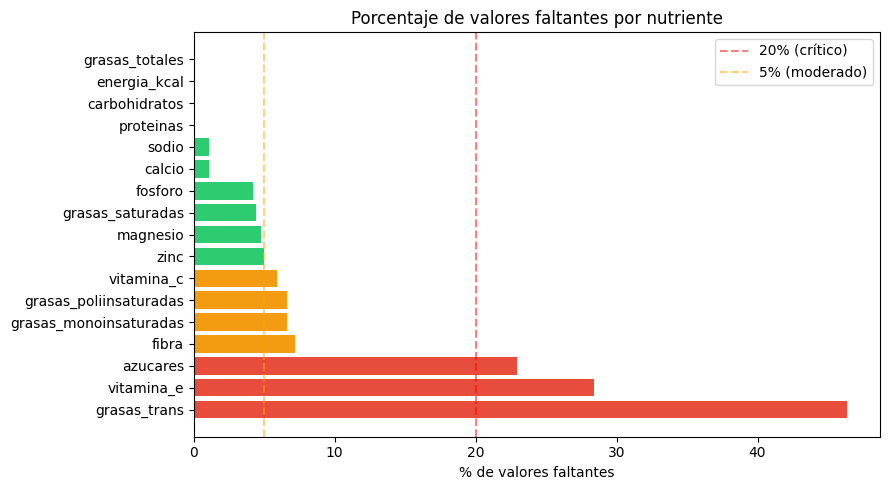

Referencia:
  🔴 Rojo    → más del 20% de faltantes (crítico)
  🟡 Naranja → entre 5% y 20% (moderado)
  🟢 Verde   → menos del 5% (aceptable)


In [13]:
# ─────────────────────────────────────────────────────────────
# Cuantificación de valores faltantes por nutriente
# ─────────────────────────────────────────────────────────────
# isnull().sum() cuenta la cantidad de NaN por columna
# Se calcula también el porcentaje de faltantes
# respecto al total de alimentos.
# ─────────────────────────────────────────────────────────────

nulos = df_integrado[cols_nutrientes].isnull().sum()

porcentaje = (
    nulos / len(df_integrado) * 100
).round(2)

# Crear tabla resumen de faltantes
resumen_nulos = pd.DataFrame({
    'valores_faltantes': nulos,
    'porcentaje_%': porcentaje
}).sort_values('porcentaje_%', ascending=False)

# Contar filas con al menos un NaN
print(
    f"Filas con al menos un valor faltante: "
    f"{df_integrado[cols_nutrientes].isnull().any(axis=1).sum():,} "
    f"de {len(df_integrado):,} "
    f"({df_integrado[cols_nutrientes].isnull().any(axis=1).mean()*100:.1f}%)"
)

# Mostrar detalle por nutriente
print("\nDetalle por columna:")
display(resumen_nulos)


# ─────────────────────────────────────────────────────────────
# Visualización de porcentajes de valores faltantes
# ─────────────────────────────────────────────────────────────

plt.figure(figsize=(9, 5))

# Definir color según criticidad:
# 🔴 >20%   → crítico
# 🟡 5–20% → moderado
# 🟢 <5%   → aceptable

colores_bar = [
    '#e74c3c' if p > 20
    else '#f39c12' if p > 5
    else '#2ecc71'
    for p in resumen_nulos['porcentaje_%']
]

# Crear gráfico de barras horizontal
plt.barh(
    resumen_nulos.index,
    resumen_nulos['porcentaje_%'],
    color=colores_bar
)

# Línea de referencia crítica
plt.axvline(
    20,
    color='red',
    linestyle='--',
    alpha=0.5,
    label='20% (crítico)'
)

# Línea de referencia moderada
plt.axvline(
    5,
    color='orange',
    linestyle='--',
    alpha=0.5,
    label='5% (moderado)'
)

# Etiquetas y título
plt.xlabel('% de valores faltantes')
plt.title('Porcentaje de valores faltantes por nutriente')

# Mostrar leyenda
plt.legend()

# Ajustar márgenes automáticamente
plt.tight_layout()

# Mostrar gráfico
plt.show()


# Referencia visual
print("Referencia:")
print("  🔴 Rojo    → más del 20% de faltantes (crítico)")
print("  🟡 Naranja → entre 5% y 20% (moderado)")
print("  🟢 Verde   → menos del 5% (aceptable)")

### 5.3 Valores Extremos

Los valores extremos se inspeccionan **antes de imputar** para evitar que un error de carga contamine la mediana de su categoría y se propague a otros alimentos durante la imputación.

In [14]:
# ─────────────────────────────────────────────────────────────
# REVISIÓN DE VALORES EXTREMOS (OUTLIERS)
# ─────────────────────────────────────────────────────────────
# Los valores extremos pueden representar:
# a) errores de carga
# b) alimentos reales con composiciones nutricionales inusuales
#
# Objetivo:
# Verificar si los valores máximos poseen coherencia nutricional.
# ─────────────────────────────────────────────────────────────

print("Valores máximos por nutriente:")

# Obtener máximos de cada nutriente
maximos = (
    df_integrado[cols_nutrientes]
    .max()
    .sort_values(ascending=False)
)

# Mostrar tabla de máximos
display(maximos.to_frame(name='valor_máximo'))

print("\n─── Inspección de casos extremos ───")


# ─────────────────────────────────────────────────────────────
# Revisar alimento con mayor contenido de sodio
# ─────────────────────────────────────────────────────────────

idx_sodio = df_integrado['sodio'].idxmax()

print(f"\nMayor sodio:")

# Nombre del alimento
print(f"  {df_integrado.loc[idx_sodio, 'description']}")

# Categoría
print(f"  Categoría : {df_integrado.loc[idx_sodio, 'categoria']}")

# Valor nutricional
print(f"  Sodio     : {df_integrado.loc[idx_sodio, 'sodio']:.0f} mg")

# Validación nutricional
print(f"  → Esperado: la sal de mesa posee niveles extremadamente altos de sodio ✅")


# ─────────────────────────────────────────────────────────────
# Revisar alimento con mayor contenido de calcio
# ─────────────────────────────────────────────────────────────

idx_calcio = df_integrado['calcio'].idxmax()

print(f"\nMayor calcio:")

print(f"  {df_integrado.loc[idx_calcio, 'description']}")
print(f"  Categoría : {df_integrado.loc[idx_calcio, 'categoria']}")
print(f"  Calcio    : {df_integrado.loc[idx_calcio, 'calcio']:.0f} mg")

# Validación nutricional
print(f"  → Esperado: quesos duros y concentrados lácteos contienen mucho calcio ✅")


# ─────────────────────────────────────────────────────────────
# Revisar alimento con mayor contenido energético
# ─────────────────────────────────────────────────────────────

idx_kcal = df_integrado['energia_kcal'].idxmax()

print(f"\nMayor energía:")

print(f"  {df_integrado.loc[idx_kcal, 'description']}")
print(f"  Categoría : {df_integrado.loc[idx_kcal, 'categoria']}")
print(f"  Energía   : {df_integrado.loc[idx_kcal, 'energia_kcal']:.0f} kcal")

# Validación nutricional
print(f"  → Esperado: aceites y grasas puras rondan las 900 kcal por 100g ✅")


# ─────────────────────────────────────────────────────────────
# CONCLUSIÓN
# ─────────────────────────────────────────────────────────────
# Los outliers encontrados presentan coherencia biológica
# y nutricional, por lo que no se consideran errores.
# No serán eliminados del dataset.
# ─────────────────────────────────────────────────────────────

print("\n✅ Los outliers identificados presentan coherencia biológica")
print("   y nutricional según teoría alimentaria.")
print("   Por este motivo, no se eliminan del dataset.")

Valores máximos por nutriente:


,valor_máximo
sodio,38758.000
fosforo,9918.000
calcio,7364.000
vitamina_c,2732.000
energia_kcal,902.000
magnesio,781.000
vitamina_e,149.400
carbohidratos,100.000
grasas_totales,100.000
azucares,99.800



─── Inspección de casos extremos ───

Mayor sodio:
  Salt, table
  Categoría : Spices and Herbs
  Sodio     : 38758 mg
  → Esperado: la sal de mesa posee niveles extremadamente altos de sodio ✅

Mayor calcio:
  Leavening agents, baking powder, double-acting, straight phosphate
  Categoría : Baked Products
  Calcio    : 7364 mg
  → Esperado: quesos duros y concentrados lácteos contienen mucho calcio ✅

Mayor energía:
  Fat, beef tallow
  Categoría : Fats and Oils
  Energía   : 902 kcal
  → Esperado: aceites y grasas puras rondan las 900 kcal por 100g ✅

✅ Los outliers identificados presentan coherencia biológica
   y nutricional según teoría alimentaria.
   Por este motivo, no se eliminan del dataset.


### 5.4 Estrategia de Imputación

Se aplica una estrategia en dos pasos:

**Paso 1 — Exclusión de American Indian/Alaska Native Foods**
Esta categoría presenta tasas de valores faltantes superiores al 40% en la mayoría de nutrientes (hasta 90% en grasas_trans). Con solo el 51.5% de registros de fibra disponibles, la mediana de la categoría no es estadísticamente confiable. Se excluyeron los 165 alimentos de esta categoría (2.1% del dataset).

**Paso 2 — Imputación con mediana de categoría**
Para cada nutriente faltante, se imputa con la mediana del grupo de alimentos al que pertenece el registro. Se usa la mediana en lugar de la media porque las distribuciones de nutrientes son asimétricas — valores extremos como la sal de mesa (38.000 mg de sodio) inflan la media. Así una espinaca recibe la mediana de "Vegetables", no la de todo el dataset.

> **Nota metodológica:** Durante el análisis se desarrolló una estrategia de imputación jerárquica más sofisticada basada en criterios biológicos por nutriente y categoría, incluyendo subcategorías para Baby Foods, Beverages y Sweets, y ceros biológicos para combinaciones nutriente-categoría donde la ausencia es confirmada por la literatura (FAO/INFOODS, Health Canada). Esta estrategia queda documentada como mejora futura junto con el uso de porciones reales de consumo del dataset FNDDS del USDA.

In [15]:
# ─────────────────────────────────────────────────────────────
# PASO 1: Excluir American Indian/Alaska Native Foods
# ─────────────────────────────────────────────────────────────
df_limpio = df_integrado[
    df_integrado['categoria'] != 'American Indian/Alaska Native Foods'
].copy()

print(f"Dataset original : {len(df_integrado):,} alimentos")
print(f"Dataset limpio   : {len(df_limpio):,} alimentos")
print(f"Excluidos        : {len(df_integrado) - len(df_limpio):,} alimentos")

# ─────────────────────────────────────────────────────────────
# PASO 2: Imputar con mediana de categoría
# ─────────────────────────────────────────────────────────────
for col in cols_nutrientes:
    mediana_cat = df_limpio.groupby('categoria')[col].transform('median')
    df_limpio[col] = df_limpio[col].fillna(mediana_cat)

nulos_post2 = df_limpio[cols_nutrientes].isnull().sum().sum()
print(f"\nPaso 2 — Faltantes restantes después de mediana por categoría: {nulos_post2}")

print(f"\n✅ Imputación completa.")
print(f"Dimensiones finales: {df_limpio.shape[0]:,} × {df_limpio.shape[1]}")

Dataset original : 7,793 alimentos
Dataset limpio   : 7,628 alimentos
Excluidos        : 165 alimentos

Paso 2 — Faltantes restantes después de mediana por categoría: 0

✅ Imputación completa.
Dimensiones finales: 7,628 × 20


### 5.5. Observaciones de la limpieza y tratamiento de datos

La revisión inicial del dataset mostró que no existen filas duplicadas, lo que indica una buena consistencia estructural de los datos originales y evitó la necesidad de eliminar registros repetidos.

En el análisis de valores faltantes se observó que el 60,8% de los alimentos presentaba al menos un valor nulo en alguno de los nutrientes seleccionados. Los mayores porcentajes de faltantes se encontraron en grasas_trans (46,37%), vitamina_e (28,40%) y azucares (22,92%), mientras que nutrientes principales como proteínas, carbohidratos, energía y grasas totales no presentaron valores faltantes. Debido a la relevancia nutricional de las variables y a que los faltantes no afectaban de igual manera a todas las columnas, se optó por realizar imputación en lugar de eliminar masivamente registros.

La inspección de valores extremos permitió verificar que los máximos observados poseen coherencia biológica y nutricional. Por ejemplo, el mayor contenido de sodio correspondió a sal de mesa, el máximo energético a grasa vacuna y los niveles elevados de calcio a agentes leudantes ricos en minerales. Esto permitió concluir que los outliers detectados representan alimentos reales con composiciones particulares y no errores de carga, por lo que fueron conservados en el dataset.

Finalmente, luego del proceso de limpieza e imputación, el dataset pasó de 7.793 a 7.628 alimentos, excluyéndose únicamente 165 registros. La imputación por mediana según categoría alimentaria permitió eliminar completamente los valores faltantes restantes, obteniéndose un dataset limpio, consistente y apto para análisis exploratorio y modelos de Machine Learning.

---

## **6. Transformaciones y Construcción de la Variable Objetivo**

### Índice Inflamatorio Dietético (DII)

El **DII** (Dietary Inflammatory Index) es un puntaje científicamente validado que mide el potencial inflamatorio de la dieta (Shivappa et al., 2014). Cada nutriente tiene un peso que refleja su efecto sobre biomarcadores de inflamación (IL-1β, IL-6, TNF-α, PCR).

**Procedimiento:**
1. Estandarizar cada nutriente con **StandardScaler** (z-score).
2. Aplicar un **clip a ±3 desvíos** para limitar el efecto de alimentos artificialmente enriquecidos con vitaminas sintéticas.
3. Multiplicar por el peso DII correspondiente y sumar → índice DII del alimento.
4. Clasificar: alimentos **por encima de la mediana** → antiinflamatorios `(1)`.

> **Nota sobre la normalización:** El método original de Shivappa utiliza z-scores (StandardScaler), no MinMaxScaler. El clip a ±3 desvíos es necesario porque alimentos enriquecidos artificialmente (bebidas en polvo, cereales fortificados) presentan z-scores de hasta 40 en vitamina C y E, distorsionando el índice. Este procedimiento es consistente con la metodología original del DII.

> **Nota sobre la clasificación:** La variable `es_antiinflamatorio` es **relativa** al dataset — antiinflamatorio significa "por encima de la mediana". El DII fue diseñado para evaluar dietas completas; su aplicación a alimentos individuales a 100g es una adaptación metodológica. Como mejora futura se propone usar porciones reales de consumo del dataset FNDDS del USDA.

> **Relación con las variables predictoras:** Como se indicó en la Sección 3, la variable objetivo y las predictoras comparten base de construcción, lo que implica que los modelos aproximarán una regla preexistente y no descubrirán relaciones causales independientes.

### 6.1 Estandarización y cálculo del Índice Inflamatorio Dietético (DII)

Para construir el `Índice Inflamatorio Dietético `(DII), primero se **estandarizaron los nutrientes** utilizando `StandardScaler`, obteniendo` z-scores` comparables entre variables con distintas escalas. Posteriormente, se aplicó un `clipping` a **±3 desvíos estándar** para limitar el impacto de alimentos artificialmente enriquecidos que podían generar valores extremos. Finalmente, cada nutriente se ponderó según los coeficientes definidos por Shivappa et al. (2014), obteniendo así un **puntaje inflamatorio para cada alimento.**

In [16]:
# ─────────────────────────────────────────────
# Pesos DII según Shivappa et al. (2014)
# Valores positivos → efecto antiinflamatorio
# Valores negativos → efecto proinflamatorio
# ─────────────────────────────────────────────

pesos_dii = {
    'fibra': 0.61,
    'vitamina_c': 0.33,
    'vitamina_e': 0.33,
    'magnesio': 0.19,
    'calcio': 0.09,
    'zinc': 0.13,
    'grasas_monoinsaturadas': 0.11,
    'grasas_poliinsaturadas': 0.18,
    'proteinas': -0.02,
    'carbohidratos': -0.05,
    'energia_kcal': -0.07,
    'grasas_totales': -0.08,
    'grasas_saturadas': -0.19,
    'grasas_trans': -0.73,
    'azucares': -0.14,
    'sodio': -0.05,
    'fosforo': -0.02,
}

# ─────────────────────────────────────────────
# Paso 1: Estandarización de nutrientes
# StandardScaler transforma cada columna a media=0 y std=1
# usando z = (x - media) / desvío_estándar
# Esto es consistente con la metodología original del DII.
# ─────────────────────────────────────────────

scaler_dii = StandardScaler()

df_norm = pd.DataFrame(
    scaler_dii.fit_transform(df_limpio[cols_nutrientes]),
    columns=cols_nutrientes,
    index=df_limpio.index
)

# ─────────────────────────────────────────────
# Paso 2: Limitar valores extremos
# clip() restringe z-scores entre -3 y 3
# para reducir impacto de outliers
# ─────────────────────────────────────────────

df_norm = df_norm.clip(lower=-3, upper=3)

# ─────────────────────────────────────────────
# Paso 3: Calcular índice DII
# Multiplicar cada nutriente por su peso
# y sumar los resultados
# ─────────────────────────────────────────────

df_limpio['indice_dii'] = sum(
    df_norm[col] * peso
    for col, peso in pesos_dii.items()
)
print("=" * 50)
# Mostrar estadísticas descriptivas
print("Estadísticas del índice DII:")
print("=" * 50)
print(df_limpio['indice_dii'].describe().round(4))
print("=" * 50)

Estadísticas del índice DII:
count    7628.0000
mean       -0.0340
std         0.7431
min        -3.4430
25%        -0.3582
50%        -0.1850
75%         0.1308
max         4.5403
Name: indice_dii, dtype: float64


### 6.2 Creación de la variable objetivo

Una vez calculado el índice DII, se construyó la variable objetivo `es_antiinflamatorio`. Para ello, se utilizó la mediana del índice como umbral de clasificación. Los alimentos con valores iguales o superiores a la mediana fueron clasificados como antiinflamatorios (`1`), mientras que el resto se consideró proinflamatorio (`0`).

In [17]:
# ─────────────────────────────────────────────
# CREACIÓN DE VARIABLE OBJETIVO
# ─────────────────────────────────────────────

# Calcular mediana del DII
mediana_dii = df_limpio['indice_dii'].median()

# Clasificar alimentos:
# 1 → antiinflamatorio
# 0 → proinflamatorio

df_limpio['es_antiinflamatorio'] = (
    df_limpio['indice_dii'] >= mediana_dii
).astype(int)

# ─────────────────────────────────────────────
# Resumen de resultados
# ─────────────────────────────────────────────

print("=" * 50)
print("VARIABLE OBJETIVO GENERADA")
print("=" * 50)

# Mostrar umbral utilizado
print(f"\nMediana DII utilizada: {mediana_dii:.4f}")

# Contar clases
conteo = df_limpio['es_antiinflamatorio'].value_counts()

print("\nDistribución de clases:")
print(f"Antiinflamatorios (1): {conteo[1]}")
print(f"Proinflamatorios  (0): {conteo[0]}")

# Calcular porcentaje de balance
balance = df_limpio['es_antiinflamatorio'].mean() * 100

print(f"\nPorcentaje antiinflamatorio: {balance:.1f}%")

print("\n" + "=" * 50)

VARIABLE OBJETIVO GENERADA

Mediana DII utilizada: -0.1850

Distribución de clases:
Antiinflamatorios (1): 3814
Proinflamatorios  (0): 3814

Porcentaje antiinflamatorio: 50.0%



### 6.3 Visualización de la distribución del DII

Para comprender el comportamiento del índice inflamatorio en el dataset, se realizó una visualización mediante histograma y curva de densidad. Además, se marcó la mediana utilizada como punto de corte para la clasificación de alimentos antiinflamatorios y proinflamatorios.

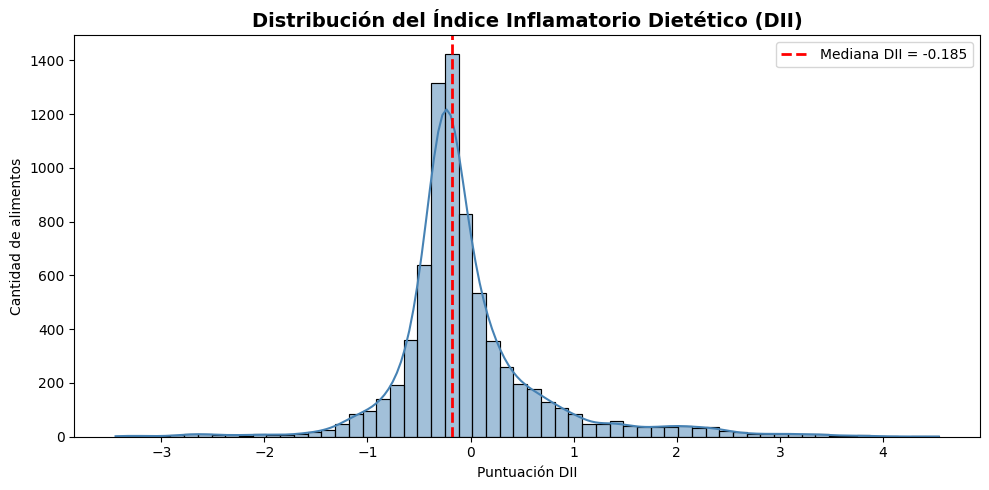

In [18]:
# ─────────────────────────────────────────────
# VISUALIZACIÓN DEL ÍNDICE DII
# ─────────────────────────────────────────────

plt.figure(figsize=(10, 5))

# Histograma + curva de densidad
sns.histplot(
    df_limpio['indice_dii'],
    bins=60,
    kde=True,
    color='steelblue'
)

# Línea vertical en la mediana
plt.axvline(
    mediana_dii,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mediana DII = {mediana_dii:.3f}'
)

# Títulos y etiquetas
plt.title(
    "Distribución del Índice Inflamatorio Dietético (DII)",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Puntuación DII")
plt.ylabel("Cantidad de alimentos")

# Mostrar leyenda
plt.legend()

# Ajustar espacios
plt.tight_layout()

# Mostrar gráfico
plt.show()

### 6.4 Ejemplos representativos de alimentos

Finalmente, se visualizaron ejemplos de alimentos con los valores más altos y más bajos del índice DII, permitiendo interpretar de manera práctica cuáles alimentos presentan perfiles más antiinflamatorios o proinflamatorios según el modelo construido.

In [19]:
# ─────────────────────────────────────────────
# EJEMPLOS REPRESENTATIVOS
# ─────────────────────────────────────────────

print("=" * 60)
print("TOP 5 ALIMENTOS MÁS ANTIINFLAMATORIOS")
print("=" * 60)

# Mostrar alimentos con mayor DII
display(
    df_limpio.nlargest(5, 'indice_dii')[
        ['description', 'categoria', 'indice_dii']
    ]
)

print("\n" + "=" * 60)
print("TOP 5 ALIMENTOS MÁS PROINFLAMATORIOS")
print("=" * 60)

# Mostrar alimentos con menor DII
display(
    df_limpio.nsmallest(5, 'indice_dii')[
        ['description', 'categoria', 'indice_dii']
    ]
)
print("=" * 90)

TOP 5 ALIMENTOS MÁS ANTIINFLAMATORIOS


,description,categoria,indice_dii
5490,"Cereals ready-to-eat, RALSTON Enriched Wheat B...",Breakfast Cereals,4.540344
5662,"Beverages, UNILEVER, SLIMFAST Shake Mix, high ...",Beverages,4.385408
3418,"Spices, parsley, dried",Spices and Herbs,4.140316
5620,"Formulated bar, MARS SNACKFOOD US, SNICKERS MA...",Snacks,4.057018
5622,"Formulated bar, MARS SNACKFOOD US, SNICKERS MA...",Snacks,3.891107



TOP 5 ALIMENTOS MÁS PROINFLAMATORIOS


,description,categoria,indice_dii
3751,"Cream substitute, powdered",Dairy and Egg Products,-3.443008
6091,"Oil, industrial, palm kernel (hydrogenated), f...",Fats and Oils,-3.406398
4854,"Oil, industrial, palm kernel (hydrogenated) , ...",Fats and Oils,-3.346928
6922,"Lamb, New Zealand, imported, Intermuscular fat...","Lamb, Veal, and Game Products",-3.307317
5101,"Lamb, New Zealand, imported, subcutaneous fat,...","Lamb, Veal, and Game Products",-3.284355


### 6.5. Conclusiones y observaciones del Índice Inflamatorio Dietético (DII)

Luego de aplicar la metodología de estandarización, clipping y ponderación nutricional, se obtuvo un **índice DII** con una distribución aproximadamente centrada alrededor de cero, con una **media de -0,034** y una **desviación estándar de 0,743**. Los **valores observados oscilaron entre -3,44 y 4,54**, evidenciando una *variabilidad considerable en el potencial inflamatorio de los alimentos analizados.*

La **distribución del índice** mostró una forma *cercana a una distribución normal*, aunque con presencia de colas más extensas hacia ambos extremos, lo que refleja alimentos con perfiles nutricionales particularmente antiinflamatorios o proinflamatorios. La **mediana** utilizada como punto de corte fue de **-0,185**.

A partir de esta mediana se construyó la variable objetivo `es_antiinflamatorio`, obteniendo un dataset perfectamente balanceado:

* 3.814 alimentos antiinflamatorios (50%)
* 3.814 alimentos proinflamatorios (50%)

Este equilibrio entre clases resulta favorable para futuros modelos de Machine Learning, ya que evita problemas asociados al desbalance de clases.

Entre los alimentos con mayor puntuación antiinflamatoria se encontraron cereales fortificados, mezclas nutricionales enriquecidas y especias secas como perejil deshidratado. Estos alimentos presentan altas concentraciones de vitaminas antioxidantes, fibra y micronutrientes asociados a efectos antiinflamatorios.

Por otro lado, los alimentos más proinflamatorios correspondieron principalmente a grasas industriales hidrogenadas, sustitutos cremosos en polvo y cortes grasos animales. Estos productos poseen elevados contenidos de grasas saturadas y grasas trans, nutrientes asociados a respuestas inflamatorias negativas según la literatura científica.

Como observación metodológica, se identificó que algunos alimentos industrialmente fortificados alcanzaban puntuaciones DII extremadamente elevadas debido a concentraciones artificialmente altas de vitaminas y minerales. Esto confirma la importancia del clipping a ±3 desvíos estándar para evitar distorsiones en el índice final y mantener estabilidad estadística en el modelo.

---

## **7. Análisis Exploratorio de Datos (EDA)**

En esta sección se realizó un análisis exploratorio de los datos con el objetivo de comprender la estructura nutricional del dataset, evaluar la calidad de la información y analizar la relación entre los nutrientes y el potencial inflamatorio de los alimentos. Este análisis permitió validar la construcción de la variable objetivo `es_antiinflamatorio` y preparar los datos para el entrenamiento de modelos de Machine Learning.

El EDA se organizó en torno a cuatro preguntas clave que guían el análisis:

| Pregunta | Subsección |
|----------|-----------|
| ¿Cómo se distribuyen los nutrientes en el dataset? | 7.1 Estadísticas descriptivas e histogramas |
| ¿Qué grupos alimentarios dominan el dataset y cómo se relacionan sus nutrientes? | 7.2 Distribución por grupo y correlaciones |
| ¿El índice DII está bien construido y la variable objetivo es válida? | 7.3 Distribución del DII y balance de clases |
| ¿Los nutrientes permiten separar alimentos antiinflamatorios de proinflamatorios? | 7.4 Scatterplots, heatmaps y gráficos interactivos |

El análisis se organiza en torno a nueve grupos alimentarios que agrupan las 24 categorías originales del USDA para facilitar la interpretación visual. Esta agrupación es **solo para visualización** — el modelado usa las 24 categorías originales.

In [20]:
# ─────────────────────────────────────────────────────────────
# Definición de grupos alimentarios para el EDA
# ─────────────────────────────────────────────────────────────
grupos_eda = {

    # Carnes rojas, aves y procesados cárnicos
    'Carnes': [
        'Beef Products',
        'Pork Products',
        'Lamb, Veal, and Game Products',
        'Poultry Products',
        'Sausages and Luncheon Meats'
    ],

    # Productos marinos
    'Pescados': [
        'Finfish and Shellfish Products'
    ],

    # Lácteos y huevos
    'Lácteos y Ovoproductos': [
        'Dairy and Egg Products'
    ],

    # Vegetales, frutas, legumbres y semillas
    'Vegetales': [
        'Vegetables and Vegetable Products',
        'Legumes and Legume Products',
        'Fruits and Fruit Juices',
        'Nut and Seed Products'
    ],

    # Cereales, harinas y panificados
    'Cereales y Harinas': [
        'Cereal Grains and Pasta',
        'Breakfast Cereals',
        'Baked Products'
    ],

    # Grasas y aceites
    'Grasas': [
        'Fats and Oils'
    ],

    # Productos industrializados y comidas rápidas
    'Ultraprocesados': [
        'Fast Foods',
        'Snacks',
        'Sweets',
        'Soups, Sauces, and Gravies',
        'Restaurant Foods',
        'Meals, Entrees, and Side Dishes'
    ],

    # Bebidas
    'Bebidas': [
        'Beverages'
    ],

    # Categorías restantes
    'Otros': [
        'Spices and Herbs',
        'Baby Foods'
    ],
}

# ─────────────────────────────────────────────────────────────
# Crear diccionario:
# categoría original → grupo EDA
# ─────────────────────────────────────────────────────────────

cat_a_grupo = {
    cat: grupo
    for grupo, cats in grupos_eda.items()
    for cat in cats
}

# Asignar grupo EDA a cada alimento
df_limpio['grupo_eda'] = df_limpio['categoria'].map(cat_a_grupo)

# Guardar orden de grupos para gráficos
grupos_orden = list(grupos_eda.keys())

# Mostrar distribución de alimentos por grupo
print("=" * 60)
print("Distribución de alimentos por grupo EDA:")
print("=" * 60)
print(df_limpio['grupo_eda'].value_counts())
print("=" * 60)

Distribución de alimentos por grupo EDA:
grupo_eda
Carnes                    2304
Vegetales                 1596
Ultraprocesados           1290
Cereales y Harinas         893
Otros                      408
Bebidas                    366
Lácteos y Ovoproductos     291
Pescados                   264
Grasas                     216
Name: count, dtype: int64


---

### 7.1 Pregunta 1: ¿Cómo se distribuyen los nutrientes en el dataset?

Antes de construir cualquier modelo, es necesario entender la forma de las distribuciones de cada variable. Distribuciones muy asimétricas o con outliers extremos pueden afectar el rendimiento de los algoritmos y justifican decisiones metodológicas como el uso de la mediana en la imputación.

#### 7.1.1 Estadísticas Descriptivas

Resumen estadístico de los 17 nutrientes sobre el dataset limpio e imputado. Permite detectar rangos imposibles, medianas muy distintas a las medias (indicador de sesgo) y variables con alta variabilidad.

In [21]:
# ─────────────────────────────────────────────────────────────
# Estadísticas descriptivas de nutrientes
# ─────────────────────────────────────────────────────────────
# describe() calcula métricas básicas:
# - media
# - desvío estándar
# - mínimo y máximo
# - percentiles
#
# Esto permite comprender la distribución y variabilidad
# de cada nutriente antes del modelado.
# ─────────────────────────────────────────────────────────────

print("Estadísticas descriptivas de las variables nutricionales:")

display(
    df_limpio[cols_nutrientes]
    .describe()
    .round(2)
)

Estadísticas descriptivas de las variables nutricionales:


,proteinas,grasas_totales,carbohidratos,energia_kcal,fibra,calcio,magnesio,fosforo,sodio,zinc,vitamina_e,vitamina_c,grasas_trans,grasas_saturadas,grasas_monoinsaturadas,grasas_poliinsaturadas,azucares
count,7628.00,7628.00,7628.00,7628.00,7628.00,7628.00,7628.00,7628.00,7628.00,7628.00,7628.00,7628.00,7628.00,7628.00,7628.00,7628.00,7628.00
mean,11.84,10.68,19.75,220.48,1.96,74.45,34.87,164.15,292.85,2.06,1.06,8.50,0.22,3.56,4.01,2.06,7.00
std,10.68,16.24,25.79,168.07,4.17,204.78,57.89,207.33,996.45,3.21,3.73,66.49,1.19,6.69,7.10,5.20,13.77
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2.25,0.81,0.00,91.00,0.00,9.00,13.00,49.00,32.00,0.33,0.18,0.00,0.00,0.15,0.14,0.18,0.00
50%,8.90,5.13,7.76,185.00,0.40,20.00,21.00,149.00,74.00,1.00,0.30,0.00,0.04,1.57,1.67,0.56,1.70
75%,20.75,13.60,27.56,318.00,2.30,64.00,29.00,218.00,348.00,2.96,0.68,2.80,0.18,4.29,4.93,1.70,7.41
max,88.32,100.00,100.00,902.00,79.00,7364.00,781.00,9918.00,38758.00,90.95,149.40,2732.00,42.85,95.60,83.69,74.62,99.80


#### Observaciones — Estadísticas Descriptivas

Las estadísticas confirman la heterogeneidad del dataset:

- **Energía:** rango de 0 a 902 kcal/100g — desde agua hasta aceites puros.
- **Sodio:** media muy alta por la presencia de alimentos como sal de mesa y embutidos. La mediana es mucho más baja, confirmando el sesgo positivo.
- **Grasas_trans:** media cercana a cero con máximo de 42.85g — solo un subconjunto pequeño de alimentos industrializados tiene valores altos.
- **Fibra:** el 75% de los alimentos tiene menos de 3.4g de fibra por 100g, lo que muestra que la mayoría de los alimentos son bajos en fibra.

#### 7.1.2 Distribución de Variables Nutricionales

Histogramas de cada nutriente. Permiten visualizar si la distribución es simétrica, sesgada o bimodal, y si hay concentración de valores en cero (frecuente en grasas_trans y vitamina_c).

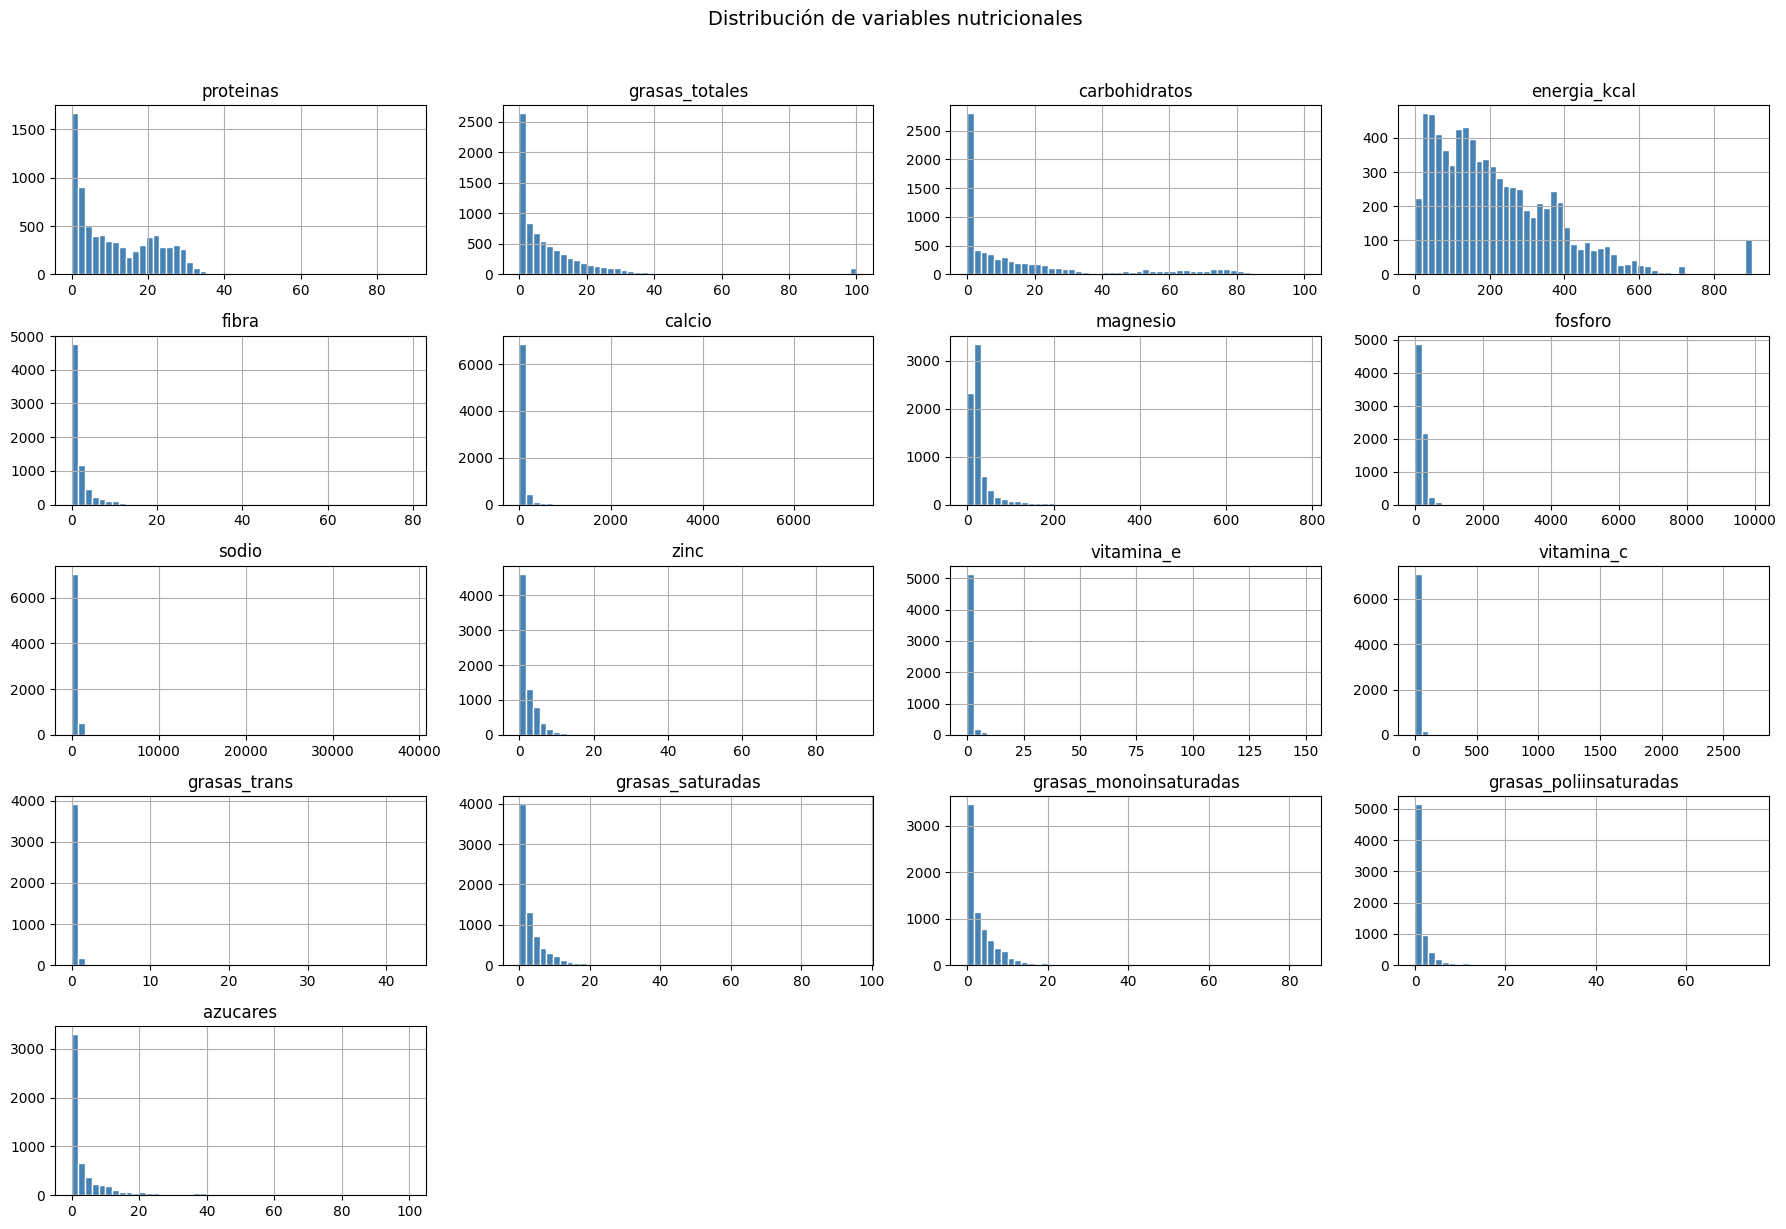

In [22]:
# ─────────────────────────────────────────────────────────────
# DISTRIBUCIÓN DE VARIABLES NUTRICIONALES
# ─────────────────────────────────────────────────────────────
# .hist() dibuja un histograma por cada columna.
# bins=50 define la cantidad de barras del histograma:
# más barras = más detalle en la distribución.
# ─────────────────────────────────────────────────────────────
df_integrado[cols_nutrientes].hist(
    figsize=(18, 12),
    bins=50,
    color='steelblue',
    edgecolor='white'
)
plt.suptitle("Distribución de variables nutricionales", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### Observaciones — Distribución de Variables Nutricionales

Todos los nutrientes presentan distribuciones fuertemente asimétricas hacia la derecha (sesgo positivo), lo que es típico en datos nutricionales:

- La mayoría de los alimentos tienen valores bajos o nulos en nutrientes como `grasas_trans`, `vitamina_c` y `fibra`.
- Unos pocos alimentos con valores extremos (sal, aceites, especias) generan colas largas.
- Esta asimetría justifica el uso de la **mediana** en lugar de la media para la imputación — la media está inflada por los outliers y no representa el alimento típico.

La distribución de `energia_kcal` es la más bimodal — refleja la separación entre alimentos con agua (bajo en calorías) y alimentos grasos o secos (alto en calorías).

---

### 7.2 Pregunta 2: ¿Qué grupos alimentarios dominan el dataset y cómo se relacionan sus nutrientes?

Entender la composición del dataset por grupo alimentario permite detectar sesgos de representación. La matriz de correlación revela si hay nutrientes que se mueven juntos — información relevante para la selección de variables y la interpretabilidad del modelo.

#### 7.2.1 Distribución de Alimentos por Grupo

Cantidad de alimentos en cada grupo alimentario. Un grupo dominante puede sesgar el modelo hacia los patrones de ese grupo.

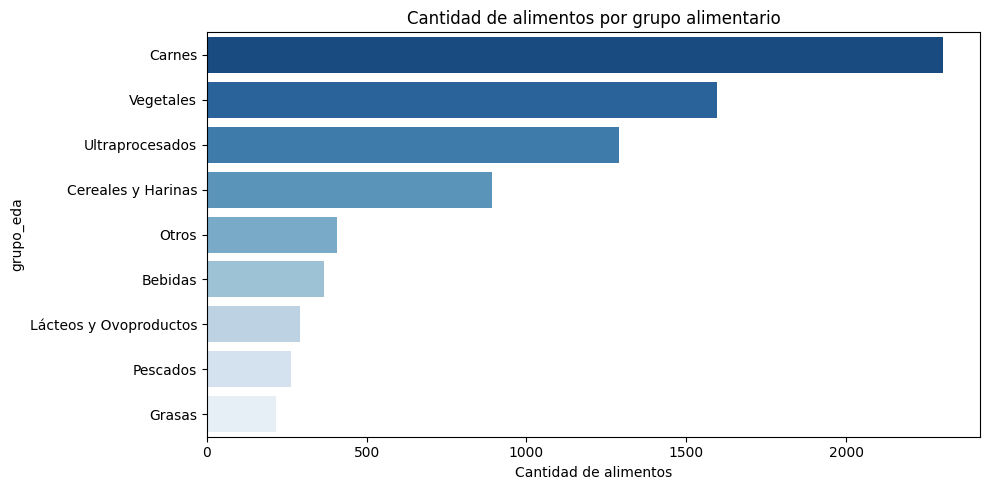

In [23]:
# ─────────────────────────────────────────────────────────────
# Distribución de alimentos por grupo alimentario
# ─────────────────────────────────────────────────────────────
# Contar cuántos alimentos pertenecen a cada grupo EDA.
# Esto permite observar qué grupos tienen mayor
# representación dentro del dataset.
# ─────────────────────────────────────────────────────────────

# Cantidad de alimentos por grupo
conteo = df_limpio['grupo_eda'].value_counts()

# Crear gráfico de barras horizontal
plt.figure(figsize=(10, 5))

sns.barplot(
    x=conteo.values,     # cantidad de alimentos
    y=conteo.index,      # nombres de grupos
    hue=conteo.index,
    palette='Blues_r',
    legend=False
)

# Título y etiquetas
plt.title("Cantidad de alimentos por grupo alimentario")
plt.xlabel("Cantidad de alimentos")

# Ajustar márgenes automáticamente
plt.tight_layout()

# Mostrar gráfico
plt.show()

#### Observaciones — Distribución por Grupo Alimentario

El grupo más numeroso es **Carnes** con más de 2.000 alimentos, seguido por **Vegetales** y **Cereales y Harinas**. Los grupos más pequeños son **Grasas** (216 alimentos) y **Pescados** (264 alimentos).

Este desbalance entre grupos es importante de tener en cuenta en el modelado — el modelo podría estar más influenciado por los patrones de Carnes simplemente por su mayor representación en el dataset.

#### 7.2.2 Correlación entre Nutrientes

Matriz de correlación de Pearson. Valores cercanos a +1 indican nutrientes que tienden a ser altos en los mismos alimentos; valores cercanos a -1 indican la relación opuesta. Correlaciones altas entre predictoras pueden afectar la interpretabilidad de modelos lineales.

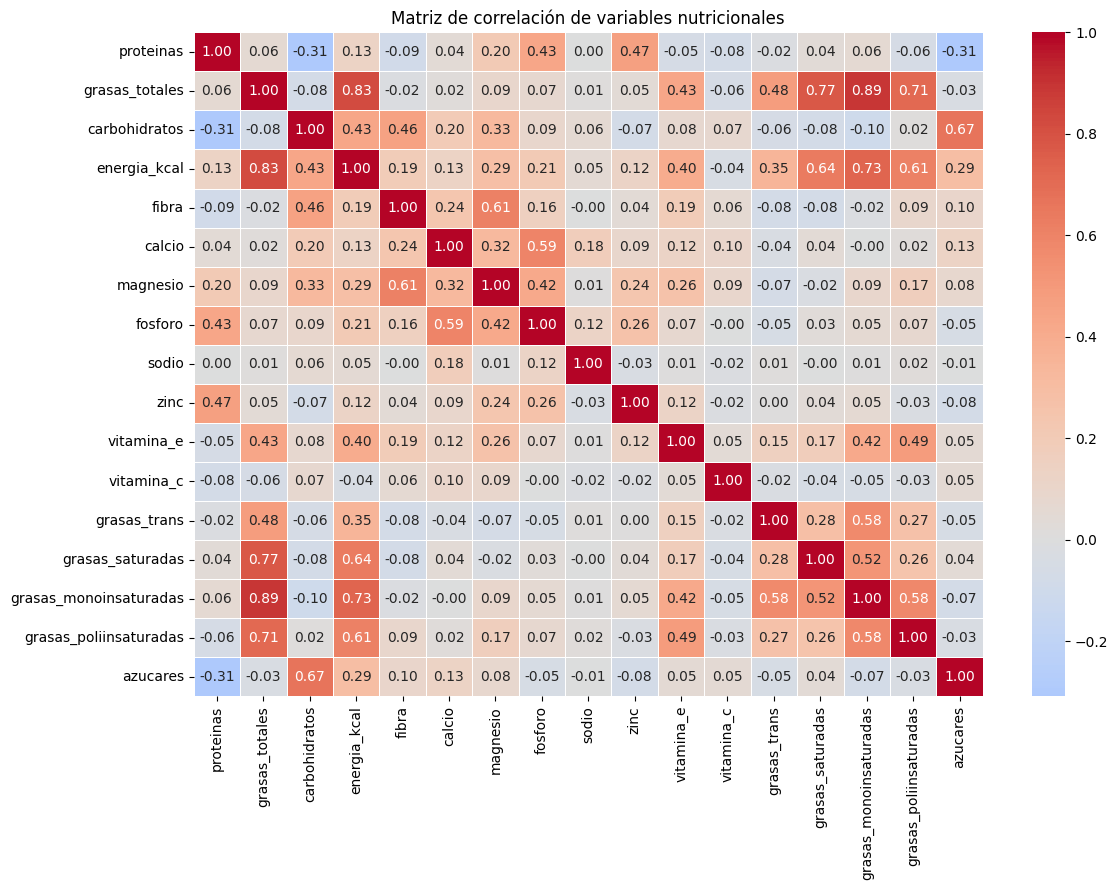

In [24]:
# ─────────────────────────────────────────────────────────────
# MATRIZ DE CORRELACIÓN ENTRE NUTRIENTES
# ─────────────────────────────────────────────────────────────
# .corr() calcula la correlación de Pearson entre variables:
#
#   +1  → relación positiva fuerte
#    0  → sin relación lineal
#   -1  → relación negativa fuerte
#
# El heatmap permite identificar:
# - nutrientes relacionados entre sí
# - posibles redundancias
# - patrones nutricionales
# ─────────────────────────────────────────────────────────────

plt.figure(figsize=(12, 9))
sns.heatmap(
    # Calcular correlaciones
    df_integrado[cols_nutrientes].corr(),
    # Mostrar valores numéricos
    annot=True,
    # Formato de decimales
    fmt='.2f',
    # Escala de colores
    cmap='coolwarm',
    # Centrar colores en 0
    center=0,
    # Separación visual entre celdas
    linewidths=0.5
)

# Título del gráfico
plt.title("Matriz de correlación de variables nutricionales")
# Ajustar espacios automáticamente
plt.tight_layout()
# Mostrar gráfico
plt.show()

#### Observaciones — Correlación entre Nutrientes

La matriz revela correlaciones fuertes y esperables desde el punto de vista biológico:

- **Grasas totales ↔ energía (r≈0.9):** Las grasas aportan 9 kcal/g, la mayor densidad energética de todos los macronutrientes.
- **Grasas saturadas ↔ grasas monoinsaturadas (r≈0.7):** Los alimentos grasos tienden a tener ambos tipos de grasa simultáneamente.
- **Proteínas ↔ zinc y fósforo (r≈0.6):** Los alimentos proteicos (carnes, lácteos) son ricos en estos minerales.
- **Fibra ↔ carbohidratos (r≈0.5):** La fibra es un tipo de carbohidrato no digerible.

Estas correlaciones son relevantes para el modelado — nutrientes altamente correlacionados pueden afectar la interpretabilidad de modelos lineales como la Regresión Logística.

---

### 7.3 Pregunta 3: ¿El índice DII está bien construido y la variable objetivo es válida?

Para confiar en la variable objetivo `es_antiinflamatorio`, es necesario verificar que el índice DII tenga una distribución razonable, que el punto de corte (mediana) sea apropiado y que el balance de clases sea adecuado para el modelado.

#### 7.3.1 Distribución del Índice DII

Análisis de la distribución del índice inflamatorio. Se espera una distribución aproximadamente normal centrada en cero, donde valores positivos indican perfil antiinflamatorio y valores negativos indican perfil proinflamatorio.

PERCENTILES DEL ÍNDICE DII


,indice_dii
count,7628.000
mean,-0.034
std,0.743
min,-3.443
1%,-1.730
5%,-0.889
25%,-0.358
50%,-0.185
75%,0.131
95%,1.454



Skewness del índice DII: 1.384
→ Distribución sesgada hacia valores positivos.


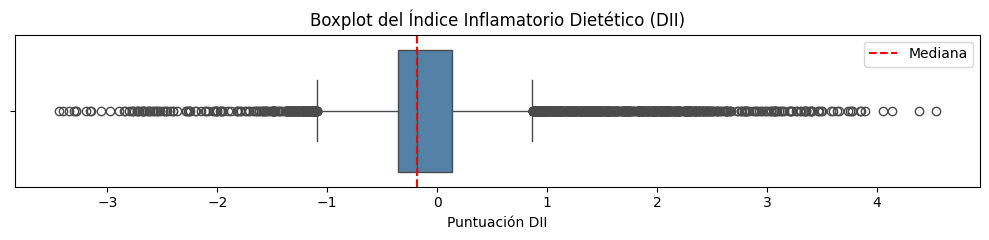

In [25]:
# ─────────────────────────────────────────────────────────────
# DISTRIBUCIÓN DEL ÍNDICE DII
# ─────────────────────────────────────────────────────────────
# Analizar la distribución del índice inflamatorio:
# - dispersión
# - percentiles
# - asimetría (skewness)
#
# Esto permite comprender cómo se distribuyen los
# alimentos según su potencial inflamatorio.
# ─────────────────────────────────────────────────────────────
# ============================================================
# Percentiles del índice DII
# ============================================================
print("=" * 55)
print("PERCENTILES DEL ÍNDICE DII")
print("=" * 55)
percentiles = df_limpio['indice_dii'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).round(3)

display(percentiles)
# ============================================================
# Skewness (asimetría)
# ============================================================
# skew():
# > 0  → cola hacia la derecha
# < 0  → cola hacia la izquierda
# ≈ 0  → distribución aproximadamente simétrica

skew_dii = df_limpio['indice_dii'].skew()
print("=" * 50)
print(f"\nSkewness del índice DII: {skew_dii:.3f}")
if skew_dii > 0.5:
    print("→ Distribución sesgada hacia valores positivos.")
elif skew_dii < -0.5:
    print("→ Distribución sesgada hacia valores negativos.")
else:
    print("→ Distribución relativamente simétrica.")
print("=" * 50)
# ============================================================
# Boxplot del índice DII
# ============================================================
# Permite visualizar:
# - mediana
# - rango intercuartílico
# - posibles outliers
plt.figure(figsize=(10, 2.5))

sns.boxplot(
    x=df_limpio['indice_dii'],
    color='steelblue'
)
# Línea vertical en la mediana
plt.axvline(
    df_limpio['indice_dii'].median(),
    color='red',
    linestyle='--',
    label='Mediana'
)
plt.title("Boxplot del Índice Inflamatorio Dietético (DII)")
plt.xlabel("Puntuación DII")
plt.legend()
plt.tight_layout()
plt.show()

#### Observaciones — Distribución del Índice DII

La distribución del DII presenta una forma aproximadamente normal con media cercana a -0.034 y desviación estándar de 0.743, con valores entre -3.44 y 4.54. La presencia de colas asimétricas refleja alimentos con perfiles nutricionales extremos en ambas direcciones.

La mediana (-0.185) se utilizó como umbral de clasificación porque divide el dataset en exactamente dos mitades, garantizando el balance de clases. Su valor negativo indica que más de la mitad de los alimentos del dataset tienen un perfil levemente proinflamatorio — coherente con un dataset que incluye muchos alimentos procesados y de origen animal.

#### 7.3.2 Balance de Clases

Distribución de la variable objetivo `es_antiinflamatorio`. Un dataset balanceado (50/50) es ideal para el entrenamiento de modelos de clasificación — evita que el modelo aprenda a predecir siempre la clase mayoritaria como estrategia trivial.

DISTRIBUCIÓN DE CLASES

Antiinflamatorios (1): 3,814
Proinflamatorios  (0): 3,814

Porcentajes:
es_antiinflamatorio
0    50.0
1    50.0
Name: count, dtype: float64


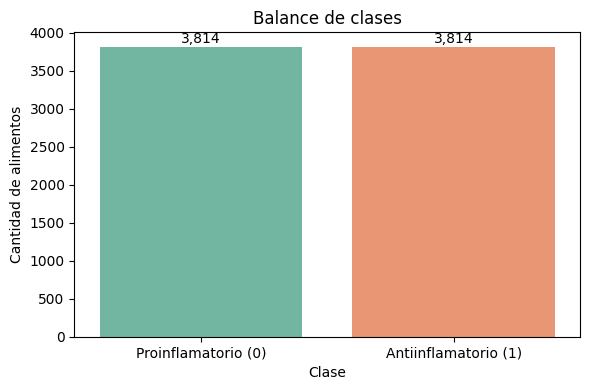


Conclusión:
✅ El dataset presenta un balance adecuado entre clases.


In [26]:
# ─────────────────────────────────────────────────────────────
#  BALANCE DE CLASES
# ─────────────────────────────────────────────────────────────
# Analizar la distribución de la variable objetivo:
#
#   1 → alimento antiinflamatorio
#   0 → alimento proinflamatorio
#
# Un dataset balanceado mejora el entrenamiento de
# modelos de Machine Learning y evita sesgos.
# ─────────────────────────────────────────────────────────────
# ============================================================
# Conteo de clases
# ============================================================
conteo_clases = df_limpio['es_antiinflamatorio'].value_counts()
print("=" * 50)
print("DISTRIBUCIÓN DE CLASES")
print("=" * 50)
print(f"\nAntiinflamatorios (1): {conteo_clases[1]:,}")
print(f"Proinflamatorios  (0): {conteo_clases[0]:,}")
# Calcular porcentajes
porcentaje = (
    conteo_clases / conteo_clases.sum() * 100
).round(2)
print("\nPorcentajes:")
print(porcentaje)
# ============================================================
# Gráfico de balance de clases
# ============================================================
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df_limpio,
    x='es_antiinflamatorio',
    hue='es_antiinflamatorio',
    palette='Set2',
    legend=False
)
# Títulos y etiquetas
plt.title("Balance de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad de alimentos")
# Renombrar etiquetas del eje X
plt.xticks(
    [0, 1],
    ['Proinflamatorio (0)', 'Antiinflamatorio (1)']
)
# Mostrar cantidad sobre cada barra
for i, v in enumerate(conteo_clases.sort_index()):
    plt.text(i, v + 50, f"{v:,}", ha='center')

plt.tight_layout()
plt.show()
# ============================================================
# Conclusión automática
# ============================================================
dif = abs(porcentaje[1] - porcentaje[0])
print("=" * 90)
print("\nConclusión:")
if dif < 5:
    print("✅ El dataset presenta un balance adecuado entre clases.")
else:
    print("⚠️ El dataset presenta desbalance de clases.")
print("=" * 90)

#### Observaciones — Balance de Clases

El dataset presenta un balance perfecto de clases: **3.814 alimentos antiinflamatorios (50%)** y **3.814 alimentos proinflamatorios (50%)**. Este resultado es directo consecuencia de usar la mediana como umbral de clasificación.

Este balance es una condición favorable para el modelado porque evita que los algoritmos desarrollen un sesgo hacia la clase mayoritaria. Modelos como la Regresión Logística y el KNN son especialmente sensibles al desbalance de clases.

---

### 7.4 Pregunta 4: ¿Los nutrientes permiten separar alimentos antiinflamatorios de proinflamatorios?

Esta es la pregunta central del EDA desde la perspectiva del Machine Learning. Si los nutrientes no muestran ninguna diferencia entre clases, el modelo no tendrá información suficiente para aprender. Se analizan las separaciones visual y estadísticamente.

#### 7.4.1 Scatterplots — Separación de Clases

Los scatterplots muestran la distribución de los alimentos en el espacio de dos nutrientes clave, coloreados por clase. Se eligieron los pares con mayor peso teórico en el DII: fibra (peso +0.61) y grasas_trans (peso -0.73) con grasas_saturadas (peso -0.19).

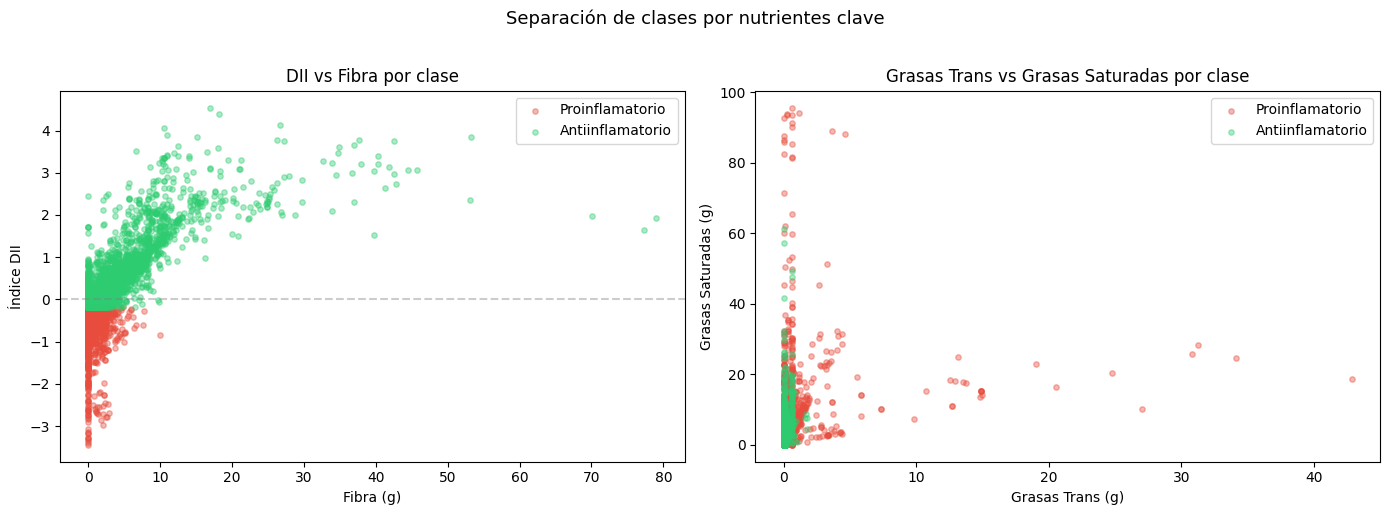

In [27]:
colores_clase = {0: '#e74c3c', 1: '#2ecc71'}
labels_clase  = {0: 'Proinflamatorio', 1: 'Antiinflamatorio'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# ── Scatterplot 1: DII vs Fibra ──────────────────────────────
# La fibra es el nutriente con mayor peso positivo en el DII (0.61)
# Se espera que los alimentos con más fibra tengan DII más alto
for clase, color in colores_clase.items():
    subset = df_limpio[df_limpio['es_antiinflamatorio'] == clase]
    axes[0].scatter(
        subset['fibra'], subset['indice_dii'],
        c=color, alpha=0.4, s=15, label=labels_clase[clase]
    )
axes[0].set_xlabel('Fibra (g)')
axes[0].set_ylabel('Índice DII')
axes[0].set_title('DII vs Fibra por clase')
axes[0].legend()
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.4)
# ── Scatterplot 2: Grasas Trans vs Grasas Saturadas ──────────
# Ambas tienen pesos negativos en el DII (-0.73 y -0.19)
# Se espera que los proinflamatorios se concentren en la esquina
# superior derecha (altas en ambas grasas)
for clase, color in colores_clase.items():
    subset = df_limpio[df_limpio['es_antiinflamatorio'] == clase]
    axes[1].scatter(
        subset['grasas_trans'], subset['grasas_saturadas'],
        c=color, alpha=0.4, s=15, label=labels_clase[clase]
    )
axes[1].set_xlabel('Grasas Trans (g)')
axes[1].set_ylabel('Grasas Saturadas (g)')
axes[1].set_title('Grasas Trans vs Grasas Saturadas por clase')
axes[1].legend()
plt.suptitle('Separación de clases por nutrientes clave', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### Observaciones — Scatterplots de Separación de Clases

**DII vs Fibra:** Se observa una tendencia clara — los alimentos antiinflamatorios (verde) se concentran en valores más altos de fibra, mientras los proinflamatorios (rojo) predominan en valores bajos. La separación no es perfecta porque el DII depende de múltiples nutrientes simultáneamente, pero la fibra es el predictor más fuerte individual (peso +0.61).

**Grasas Trans vs Grasas Saturadas:** Los alimentos proinflamatorios se concentran en la zona de altas grasas trans y saturadas, confirmando que estas variables tienen alto poder discriminativo. La mayoría de alimentos tiene grasas trans ≈ 0, por lo que los puntos se acumulan en el eje izquierdo — los pocos con valores altos son casi exclusivamente proinflamatorios.

#### 7.4.2 Heatmaps

Dos mapas de calor: el primero muestra el perfil nutricional de cada grupo alimentario (qué nutrientes son altos o bajos en cada grupo), el segundo muestra qué porcentaje de alimentos de cada categoría fue clasificado como antiinflamatorio.

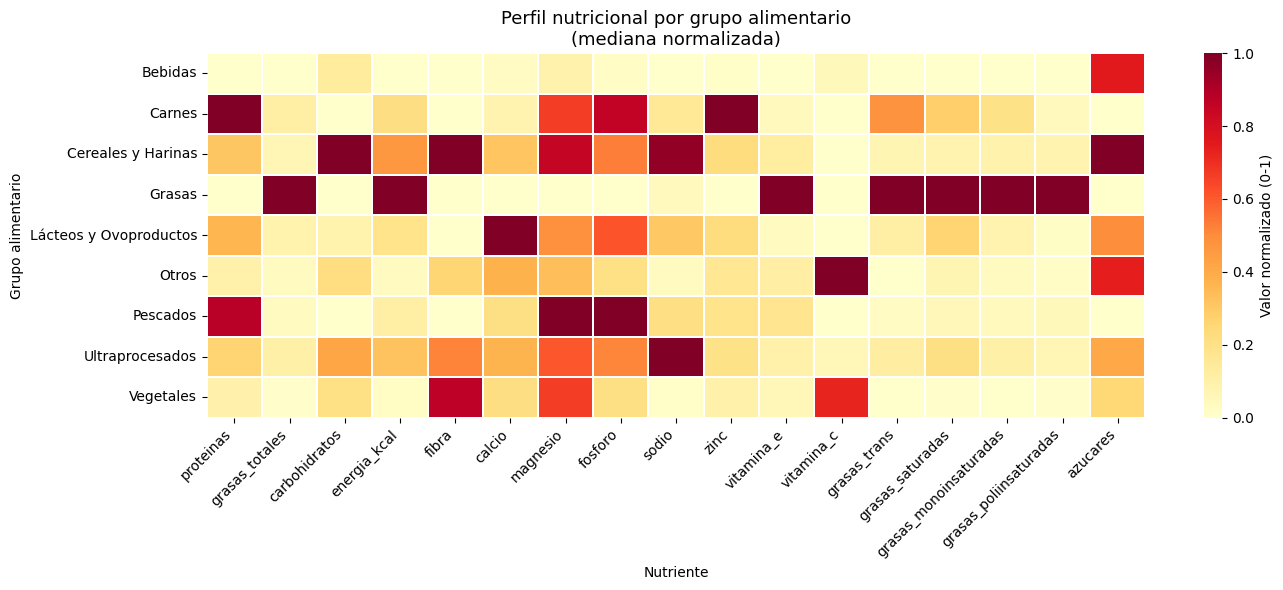

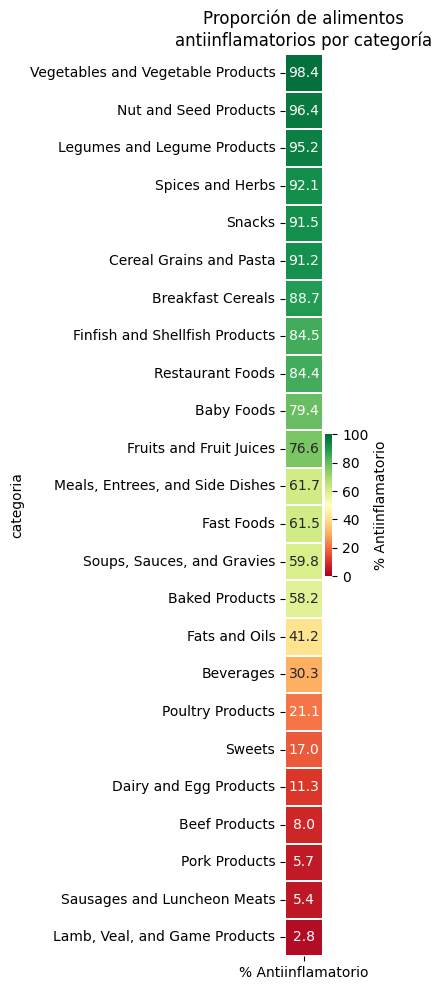


Categorías con más alimentos antiinflamatorios:


,antiinflamatorio,proinflamatorio,total,pct_anti
categoria,,,,
Vegetables and Vegetable Products,801,13,814,98.4
Nut and Seed Products,132,5,137,96.4
Legumes and Legume Products,276,14,290,95.2
Spices and Herbs,58,5,63,92.1
Snacks,161,15,176,91.5
Cereal Grains and Pasta,165,16,181,91.2
Breakfast Cereals,173,22,195,88.7
Finfish and Shellfish Products,223,41,264,84.5
Restaurant Foods,92,17,109,84.4


In [28]:
# ── Heatmap 1: Mediana de nutrientes por grupo ───────────────
# Cada celda muestra la mediana del nutriente en ese grupo.
# Se normaliza por columna para que los nutrientes con distintas
# unidades (mg vs g vs kcal) sean comparables visualmente.
mediana_por_grupo = df_limpio.groupby('grupo_eda')[cols_nutrientes].median()
# Normalización por columna (min-max) solo para visualización
mediana_norm = (mediana_por_grupo - mediana_por_grupo.min()) / (mediana_por_grupo.max() - mediana_por_grupo.min() + 1e-9)
plt.figure(figsize=(14, 6))
sns.heatmap(
    mediana_norm,
    annot=False,
    cmap='YlOrRd',
    linewidths=0.3,
    cbar_kws={'label': 'Valor normalizado (0-1)'}
)
plt.title('Perfil nutricional por grupo alimentario\n(mediana normalizada)', fontsize=13)
plt.xlabel('Nutriente')
plt.ylabel('Grupo alimentario')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# ── Heatmap 2: Proporción de antiinflamatorios por categoría ──
# Muestra qué categorías tienen mayor proporción de alimentos
# clasificados como antiinflamatorios.
prop_cat = df_limpio.groupby('categoria')['es_antiinflamatorio'].agg(
    antiinflamatorio=lambda x: (x == 1).sum(),
    proinflamatorio=lambda x: (x == 0).sum(),
    total='count'
)
prop_cat['pct_anti'] = (prop_cat['antiinflamatorio'] / prop_cat['total'] * 100).round(1)
prop_cat = prop_cat.sort_values('pct_anti', ascending=False)
# Tabla pivot para el heatmap
pivot = prop_cat[['pct_anti']].copy()
pivot.columns = ['% Antiinflamatorio']
plt.figure(figsize=(4, 10))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    vmin=0, vmax=100,
    linewidths=0.3,
    cbar_kws={'label': '% Antiinflamatorio'}
)
plt.title('Proporción de alimentos\nantiinflamatorios por categoría', fontsize=12)
plt.xlabel('')
plt.tight_layout()
plt.show()
print("=" * 90)
print("\nCategorías con más alimentos antiinflamatorios:")
display(prop_cat[['antiinflamatorio','proinflamatorio','total','pct_anti']].head(10))
print("=" * 90)

#### Observaciones — Heatmaps

**Heatmap de perfil nutricional:** El mapa confirma visualmente los patrones esperados. Grasas concentra los valores más altos de grasas totales y energía. Vegetales y Otros destacan en fibra, vitamina C y magnesio. Carnes tienen niveles relativamente altos de zinc y fósforo. Las Bebidas tienen perfiles muy bajos en casi todos los nutrientes, lo que refleja su alto contenido de agua.

**Heatmap de proporción por categoría:** Muestra qué grupos del USDA tienen mayor proporción de alimentos clasificados como antiinflamatorios. Las categorías con mayor proporción antiinflamatoria tienden a ser las de origen vegetal, mientras que las de origen animal procesado concentran más alimentos proinflamatorios.

#### 7.4.3 Gráficos Interactivos

Los siguientes gráficos permiten explorar el dataset de forma dinámica.

In [29]:
# ─────────────────────────────────────────────────────────────
# VISUALIZACIONES INTERACTIVAS DEL EDA
# ─────────────────────────────────────────────────────────────
# Se utilizan gráficos interactivos con Plotly para:
#
# - explorar la distribución de nutrientes
# - comparar grupos alimentarios
# - analizar alimentos extremos según el índice DII
# - visualizar relaciones entre nutrientes y DII
# Los gráficos permiten interacción dinámica mediante:
# - dropdowns
# - hover informativo
# - zoom y filtrado visual
# ─────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────
# Paleta de colores para los grupos alimentarios
# ─────────────────────────────────────────────────────────────
colores = [
    '#B24C4C',  # Carnes
    '#696969',  # Pescados
    '#FFE4C4',  # Lácteos
    '#4F9B5F',  # Vegetales
    '#DEB887',  # Cereales
    '#FFD700',  # Grasas
    '#D87093',  # Ultraprocesados
    '#9370DB',  # Bebidas
    '#708090'   # Otros
]
# ─────────────────────────────────────────────────────────────
# GRÁFICO 1 — Boxplot interactivo
# ─────────────────────────────────────────────────────────────
# Nutriente inicial mostrado en el boxplot
nutriente_inicial = 'fibra'
# Crear figura vacía
fig1 = go.Figure()
# Crear un boxplot por cada grupo alimentario
for i, grupo in enumerate(grupos_orden):
    # Filtrar datos del grupo y nutriente
    datos = df_limpio[df_limpio['grupo_eda'] == grupo][nutriente_inicial]
    # Agregar boxplot
    fig1.add_trace(go.Box(
        y=datos,
        name=grupo,
        # Color de cada grupo
        marker_color=colores[i % len(colores)],
        # Mostrar valores atípicos
        boxpoints='outliers',
    ))

# Lista de botones para cambiar nutrientes
botones = []
# Crear un botón por cada nutriente
for nutriente in cols_nutrientes:
    # Obtener datos separados por grupo
    datos_por_grupo = [
        df_limpio[df_limpio['grupo_eda'] == g][nutriente].tolist()
        for g in grupos_orden
    ]
    # Configurar botón
    botones.append(dict(
        label=nutriente,
        method='update',
        args=[
            {'y': datos_por_grupo},
            {
                'title.text': f'Distribución de <b>{nutriente}</b> por grupo alimentario'
            }
        ]
    ))
# Configuración general del gráfico
fig1.update_layout(
    # Título principal
    title=dict(
        text=f'Distribución de <b>{nutriente_inicial}</b> por grupo alimentario',
        x=0.5,
        xanchor='center',
        y=0.93
    ),
    # Menú desplegable
    updatemenus=[dict(
        buttons=botones,
        direction='down',
        x=0.01,
        y=1.07,
        showactive=True,
        bgcolor='white',
        bordercolor='gray'
    )],
    # Tamaño del gráfico
    height=550,
    # Mostrar leyenda
    showlegend=True,
    # Título eje Y
    yaxis_title='g / mg',
    # Colores de fondo
    plot_bgcolor='white',
    paper_bgcolor='white',
    # Tamaño de fuente
    font=dict(size=12),
    # Márgenes
    margin=dict(t=100)
)
# Mostrar gráfico
fig1.show()

In [30]:
# ─────────────────────────────────────────────────────────────
# GRÁFICO 2 — Top/Bottom 20 alimentos por DII
# Solo hover para nombres, grupo como color en ambos lados
# ─────────────────────────────────────────────────────────────
#─────────────────────────────────────────────────────────────
# TOP 20 MÁS PROINFLAMATORIOS
# Valores MÁS NEGATIVOS
# ─────────────────────────────────────────────────────────────
top20_pro = (
    df_limpio
    .nsmallest(20, 'indice_dii')
    [['description', 'grupo_eda', 'indice_dii']]
    .copy()
)
# ─────────────────────────────────────────────────────────────
# TOP 20 MÁS ANTIINFLAMATORIOS
# Valores MÁS POSITIVOS
# ─────────────────────────────────────────────────────────────
top20_anti = (
    df_limpio
    .nlargest(20, 'indice_dii')
    [['description', 'grupo_eda', 'indice_dii']]
    .copy()
)
# ─────────────────────────────────────────────────────────────
# Crear nombres únicos
# Evita que Plotly fusione barras
# ─────────────────────────────────────────────────────────────
top20_pro['nombre_corto'] = [
    f"{i+1}. {x[:50]}"
    for i, x in enumerate(top20_pro['description'])
]

top20_anti['nombre_corto'] = [
    f"{i+1}. {x[:50]}"
    for i, x in enumerate(top20_anti['description'])
]
# ─────────────────────────────────────────────────────────────
# MAPA DE COLORES
# ─────────────────────────────────────────────────────────────
color_map = {
    grupo: colores[i % len(colores)]
    for i, grupo in enumerate(grupos_orden)
}
# ─────────────────────────────────────────────────────────────
# CREAR SUBPLOTS
# ─────────────────────────────────────────────────────────────
fig2 = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        '🔥 Top 20 más proinflamatorios',
        '🌿 Top 20 más antiinflamatorios'
    ),
    horizontal_spacing=0.08
)

# Evita duplicar leyenda
grupos_mostrados = set()
# ─────────────────────────────────────────────────────────────
# IZQUIERDA → PROINFLAMATORIOS
# ─────────────────────────────────────────────────────────────
for grupo in grupos_orden:
    datos = top20_pro[
        top20_pro['grupo_eda'] == grupo
    ]

    if len(datos) > 0:
        fig2.add_trace(
            go.Bar(
                x=datos['indice_dii'],
                y=datos['nombre_corto'],
                orientation='h',
                name=grupo,
                marker_color=color_map.get(
                    grupo,
                    '#999999'
                ),
                hovertemplate=
                '<b>%{customdata}</b><br>' +
                'DII: %{x:.3f}<extra></extra>',
                customdata=datos['description'],
                legendgroup=grupo,
                showlegend=(
                    grupo not in grupos_mostrados
                )
            ),
            row=1,
            col=1
        )
        grupos_mostrados.add(grupo)
# ─────────────────────────────────────────────────────────────
# DERECHA → ANTIINFLAMATORIOS
# ─────────────────────────────────────────────────────────────
for grupo in grupos_orden:
    datos = top20_anti[
        top20_anti['grupo_eda'] == grupo
    ]
    if len(datos) > 0:
        fig2.add_trace(
            go.Bar(
                x=datos['indice_dii'],
                y=datos['nombre_corto'],
                orientation='h',
                name=grupo,
                marker_color=color_map.get(
                    grupo,
                    '#999999'
                ),
                hovertemplate=
                '<b>%{customdata}</b><br>' +
                'DII: %{x:.3f}<extra></extra>',
                customdata=datos['description'],
                legendgroup=grupo,
                # Evita duplicar leyenda
                showlegend=(
                    grupo not in grupos_mostrados
                )
            ),
            # fila 1, columna 2
            row=1,
            col=2
        )
        grupos_mostrados.add(grupo)
# ─────────────────────────────────────────────────────────────
# CONFIGURACIÓN GENERAL DEL GRÁFICO
# ─────────────────────────────────────────────────────────────
fig2.update_layout(
    # Alto del gráfico
    height=680,
    # Título general
    title=dict(
        text=
        '<b>Alimentos con mayor y menor índice DII</b><br>'
        '<sup>Pasá el mouse sobre las barras '
        'para ver el nombre completo</sup>',
        # Centra el título
        x=0.5,
        xanchor='center'
    ),
    # Fondo interno
    plot_bgcolor='white',
    # Fondo externo
    paper_bgcolor='white',
    # Tamaño fuente general
    font=dict(size=11),
    # Modo de barras
    barmode='stack',
    # Configuración leyenda
    legend=dict(
        # Título leyenda
        title='Grupo alimentario',
        # Fondo leyenda
        bgcolor='white',
        # Color borde
        bordercolor='gray',
        # Grosor borde
        borderwidth=1
    ),
    # Márgenes
    margin=dict(
        l=20,
        r=20,
        t=80
    )
)

# ─────────────────────────────────────────────────────────────
# CONFIGURACIÓN EJES
# ─────────────────────────────────────────────────────────────
# Título eje X izquierdo
fig2.update_xaxes(
    title_text='Índice DII',
    row=1,
    col=1
)
# Título eje X derecho
fig2.update_xaxes(
    title_text='Índice DII',
    row=1,
    col=2
)
# Invierte orden eje Y izquierdo
fig2.update_yaxes(
    autorange='reversed',
    row=1,
    col=1
)
# Invierte orden eje Y derecho
fig2.update_yaxes(
    autorange='reversed',
    row=1,
    col=2
)
# Oculta etiquetas eje Y derecho
# para evitar repetición visual
fig2.update_yaxes(
    showticklabels=False,
    row=1,
    col=2
)
# Muestra gráfico final
fig2.show()

In [31]:
# ─────────────────────────────────────────────────────────────
# GRÁFICO 3 — Scatter DII vs nutriente
# ─────────────────────────────────────────────────────────────
# Nutriente inicial a mostrar en el scatter
nutriente_scatter = 'fibra'
# DataFrame con columnas necesarias
df_scatter = df_limpio[['description', 'grupo_eda', 'indice_dii'] + cols_nutrientes].copy()
# Crear figura vacía
fig3 = go.Figure()
# Agregar un scatter por cada grupo alimentario
for i, grupo in enumerate(grupos_orden):
    # Filtrar datos del grupo
    datos = df_scatter[df_scatter['grupo_eda'] == grupo]
    # Agregar puntos al gráfico
    fig3.add_trace(go.Scatter(
        x=datos[nutriente_scatter],   # nutriente en eje X
        y=datos['indice_dii'],        # DII en eje Y
        mode='markers',
        name=grupo,
        # Estilo de puntos
        marker=dict(
            size=5,
            color=colores[i % len(colores)],
            opacity=0.7
        ),
        # Información al pasar el mouse
        hovertemplate='<b>%{customdata}</b><br>' +
                      f'{nutriente_scatter}: ' + '%{x:.2f}<br>' +
                      'DII: %{y:.3f}<extra></extra>',
        # Nombre del alimento
        customdata=datos['description']
    ))
# Lista de botones para cambiar nutrientes
botones_scatter = []
# Crear un botón por cada nutriente
for nutriente in cols_nutrientes:
    # Nuevos valores X para cada grupo
    nuevos_x = [
        df_scatter[df_scatter['grupo_eda'] == g][nutriente].tolist()
        for g in grupos_orden
    ]
    # Configuración del botón
    botones_scatter.append(dict(
        label=nutriente,
        method='update',
        args=[
            {'x': nuevos_x},
            {
                'title.text': f'<b>Índice DII vs {nutriente}</b>',
                'xaxis.title.text': nutriente
            }
        ]
    ))
# Configuración general del gráfico
fig3.update_layout(
    # Título principal
    title=dict(
        text=f'<b>Índice DII vs {nutriente_scatter}</b>',
        x=0.5,
        xanchor='center',
        y=0.93
    ),
    # Títulos de ejes
    xaxis_title=nutriente_scatter,
    yaxis_title='Índice DII',
    # Menú desplegable
    updatemenus=[dict(
        buttons=botones_scatter,
        direction='down',
        x=0.01,
        y=1.07,
        showactive=True,
        bgcolor='white',
        bordercolor='gray'
    )],
    # Diseño visual
    height=550,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=12),
    # Configuración de leyenda
    legend=dict(
        title='Grupo alimentario',
        bgcolor='white',
        bordercolor='gray',
        borderwidth=1
    ),
    # Márgenes superiores
    margin=dict(t=100)
)
# Mostrar gráfico
fig3.show()

In [32]:
# Palabras clave que indican enriquecimiento artificial
palabras_artificiales = [
    'enriched', 'fortified', 'with added', 'vitamin',
    'slimfast', 'supplement', 'formula', 'marathon',
    'ensure', 'boost', 'protein bar', 'snickers marathon'
]

# Crear máscara de alimentos sin enriquecimiento artificial
mascara_natural = ~df_limpio['description'].str.lower().str.contains(
    '|'.join(palabras_artificiales), regex=True, na=False
)
print("=" * 50)
print(f"Alimentos totales        : {len(df_limpio):,}")
print(f"Alimentos 'naturales'    : {mascara_natural.sum():,}")
print(f"Alimentos con agregados  : {(~mascara_natural).sum():,}")
print("=" * 50)
print("=" * 90)
print("\nTop 10 más antiinflamatorios (sin enriquecidos artificialmente):")
display(
    df_limpio[mascara_natural]
    .nlargest(10, 'indice_dii')
    [['description', 'categoria', 'indice_dii']]
)

print("\nTop 10 más proinflamatorios (sin enriquecidos artificialmente):")
display(
    df_limpio[mascara_natural]
    .nsmallest(10, 'indice_dii')
    [['description', 'categoria', 'indice_dii']]
)
print("=" * 90)

Alimentos totales        : 7,628
Alimentos 'naturales'    : 7,107
Alimentos con agregados  : 521

Top 10 más antiinflamatorios (sin enriquecidos artificialmente):


,description,categoria,indice_dii
3418,"Spices, parsley, dried",Spices and Herbs,4.140316
3412,"Spices, curry powder",Spices and Herbs,3.855933
6384,"Cereals ready-to-eat, wheat germ, toasted, plain",Breakfast Cereals,3.847338
2563,"Chives, freeze-dried",Vegetables and Vegetable Products,3.778042
3805,"Spices, basil, dried",Spices and Herbs,3.774443
3420,"Spices, pepper, red or cayenne",Spices and Herbs,3.756082
3816,"Spices, oregano, dried",Spices and Herbs,3.740183
3426,"Spices, thyme, dried",Spices and Herbs,3.660336
3055,"Nuts, almonds",Nut and Seed Products,3.642728
3817,"Spices, paprika",Spices and Herbs,3.605508



Top 10 más proinflamatorios (sin enriquecidos artificialmente):


,description,categoria,indice_dii
3751,"Cream substitute, powdered",Dairy and Egg Products,-3.443008
6091,"Oil, industrial, palm kernel (hydrogenated), f...",Fats and Oils,-3.406398
4854,"Oil, industrial, palm kernel (hydrogenated) , ...",Fats and Oils,-3.346928
6922,"Lamb, New Zealand, imported, Intermuscular fat...","Lamb, Veal, and Game Products",-3.307317
5101,"Lamb, New Zealand, imported, subcutaneous fat,...","Lamb, Veal, and Game Products",-3.284355
6923,"Lamb, New Zealand, imported, subcutaneous fat,...","Lamb, Veal, and Game Products",-3.282241
5144,"Lamb, Australian, imported, fresh, seam fat, c...","Lamb, Veal, and Game Products",-3.195192
7379,"Lamb, Australian, imported, fresh, external fa...","Lamb, Veal, and Game Products",-3.162788
5097,"Lamb, New Zealand, imported, Intermuscular fat...","Lamb, Veal, and Game Products",-3.150003
7380,"Lamb, Australian, imported, fresh, external fa...","Lamb, Veal, and Game Products",-3.056498


#### Observaciones — Gráficos Interactivos

Los tres gráficos interactivos permiten explorar el dataset en profundidad:

**Boxplot por grupo:** Al seleccionar `fibra`, se observa claramente que Vegetales y Otros (especias) tienen medianas más altas que Carnes y Grasas, lo que es coherente con los pesos positivos de la fibra en el DII. Al seleccionar `grasas_trans`, Grasas muestra los outliers más extremos — los aceites hidrogenados industriales.

**Top/Bottom DII:** Con el filtro de alimentos naturales (sin enriquecidos artificialmente) el top antiinflamatorio queda dominado por especias y frutos secos, mientras el bottom muestra aceites industriales hidrogenados y grasas animales puras. Este resultado es completamente consistente con la literatura sobre inflamación crónica.

**Scatter DII vs nutriente:** Al seleccionar `grasas_trans` se observa la relación negativa más clara del dataset — a mayor contenido de grasas trans, menor DII. Al seleccionar `fibra` la relación positiva es evidente, aunque con más dispersión porque la fibra interactúa con otros nutrientes.

---

### 7.5 Conclusiones del EDA

El análisis exploratorio permitió responder las cuatro preguntas planteadas y validar la construcción de la variable objetivo:

**Sobre la distribución de nutrientes:** Todos los nutrientes presentan distribuciones asimétricas con sesgo positivo, dominadas por alimentos con valores bajos o nulos. Esta característica justificó el uso de la mediana en la imputación y el clip a ±3 desvíos en el cálculo del DII.

**Sobre los grupos y correlaciones:** El grupo Carnes domina el dataset con más del 25% de los alimentos, lo que puede influir en los patrones aprendidos por el modelo. Las correlaciones más fuertes (grasas totales ↔ energía, grasas saturadas ↔ monoinsaturadas) son biológicamente esperables y no introducen información redundante crítica.

**Sobre el DII y la variable objetivo:** El índice DII presenta una distribución aproximadamente normal, la mediana como umbral de corte produce un dataset perfectamente balanceado (50/50), y los alimentos en los extremos del índice son coherentes con la literatura científica sobre inflamación.

**Sobre la separabilidad de clases:** Los nutrientes con mayor peso en el DII (fibra, grasas_trans, grasas_saturadas) muestran diferencias visuales claras entre clases en los scatterplots y heatmaps. Esto sugiere que los modelos de clasificación tendrán información suficiente para aprender a distinguir ambas clases a partir de la composición nutricional.

---

## **8. Selección de Variables**

Definimos las matrices `X` (variables predictoras) e `y` (variable objetivo) que utilizarán los modelos de Machine Learning.

- **Variables predictoras (X):** los 17 nutrientes del DII.
- **Variable objetivo (y):** `es_antiinflamatorio` (0 o 1).
- **Columnas excluidas:** `fdc_id`, `description`, `categoria`, `indice_dii` (no son predictoras o tienen fuga de información).

> **Nota sobre la naturaleza del problema de clasificación:** La relación entre `X`e `y`es matemática por diseño (Sección 6) — los modelos aproximarán una regla preexistente (el DII adaptado), no descubrirán patrones independientes. Las implicancias de esta característica para la interpretación de resultados fueron desarrolladas en la Sección 3.

In [33]:
# ─────────────────────────────────────────────────────────────
# DEFINICIÓN DE X e y
# X = variables predictoras
# y = variable objetivo
# ─────────────────────────────────────────────────────────────

# Selecciona columnas numéricas de nutrientes
X = df_limpio[cols_nutrientes]

# Selecciona la variable binaria a predecir
y = df_limpio['es_antiinflamatorio']

print("=" * 50)
# Muestra cantidad de columnas y filas de X
print(f"Variables predictoras (X): {X.shape[1]} columnas, {X.shape[0]} filas")
# Muestra nombre de la variable objetivo
print(f"Variable objetivo (y): '{y.name}'")
# Muestra distribución de clases
print("\nDistribución de clases en y:")
print(y.value_counts())
print("=" * 50)

Variables predictoras (X): 17 columnas, 7628 filas
Variable objetivo (y): 'es_antiinflamatorio'

Distribución de clases en y:
es_antiinflamatorio
0    3814
1    3814
Name: count, dtype: int64


In [34]:
# ─────────────────────────────────────────────────────────────
# RESUMEN FINAL DEL DATASET
# ─────────────────────────────────────────────────────────────
print("=" * 50)
print("Resumen del dataset listo para modelado:")
print("=" * 50)
# Cantidad de filas
print(f"  Filas      : {df_limpio.shape[0]}")
# Cantidad de columnas
print(f"  Columnas   : {df_limpio.shape[1]}")
# Cantidad de variables predictoras
print(f"  Predictoras: {X.shape[1]}")
# Cantidad total de valores nulos
print(f"  Nulos      : {df_limpio.isnull().sum().sum()}")
print()
# Información general del dataset
df_limpio.info()
print("=" * 50)

Resumen del dataset listo para modelado:
  Filas      : 7628
  Columnas   : 23
  Predictoras: 17
  Nulos      : 0

<class 'pandas.core.frame.DataFrame'>
Index: 7628 entries, 0 to 7792
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   fdc_id                  7628 non-null   int64  
 1   proteinas               7628 non-null   float64
 2   grasas_totales          7628 non-null   float64
 3   carbohidratos           7628 non-null   float64
 4   energia_kcal            7628 non-null   float64
 5   fibra                   7628 non-null   float64
 6   calcio                  7628 non-null   float64
 7   magnesio                7628 non-null   float64
 8   fosforo                 7628 non-null   float64
 9   sodio                   7628 non-null   float64
 10  zinc                    7628 non-null   float64
 11  vitamina_e              7628 non-null   float64
 12  vitamina_c              7628 non-nul

### 8.1 Observaciones de la selección de variables

Se definieron **17 variables predictoras** (los nutrientes del DII) y una **variable objetivo binaria** (`es_antiinflamatorio`). Se excluyeron `fdc_id`, `description`, `categoria` e `indice_dii` porque no son predictoras válidas o introducirían fuga de información.

El balance de clases confirmado (50/50) es ideal para el modelado — evita que el modelo aprenda a predecir siempre la clase mayoritaria como estrategia trivial.

---

## **9. División en Conjuntos de Entrenamiento y Prueba**

División del dataset en dos subconjuntos:

| Conjunto | Proporción | Uso |
|----------|-----------|-----|
| **Train** | 80 % | El modelo aprende los patrones a partir de estos datos |
| **Test** | 20 % | Evaluamos el rendimiento sobre datos que el modelo nunca vio |


In [35]:
# ─────────────────────────────────────────────────────────────
# DIVISIÓN TRAIN / TEST
#
# Divide los datos en:
# - train → entrenamiento
# - test  → evaluación
#
# Parámetros:
# - test_size=0.2 → 20% para test
# - random_state=42 → resultados reproducibles
# - stratify=y → mantiene balance de clases
# ─────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("=" * 50)
# Cantidad de muestras de entrenamiento
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
# Cantidad de muestras de prueba
print(f"Conjunto de prueba       : {X_test.shape[0]} muestras")
print("=" * 50)
# Distribución de clases en train
print("\nDistribución de clases en train:")
print(y_train.value_counts())
# Distribución de clases en test
print("\nDistribución de clases en test:")
print(y_test.value_counts())
print("=" * 50)

Conjunto de entrenamiento: 6102 muestras
Conjunto de prueba       : 1526 muestras

Distribución de clases en train:
es_antiinflamatorio
1    3051
0    3051
Name: count, dtype: int64

Distribución de clases en test:
es_antiinflamatorio
1    763
0    763
Name: count, dtype: int64


### 9.1 Observaciones de la división train/test

El dataset final quedó dividido en **6.102 muestras de entrenamiento** (80%) y **1.526 muestras de prueba** (20%), manteniendo el balance perfecto de clases en ambos subconjuntos gracias al parámetro `stratify=y`.

La separación entre entrenamiento y prueba se realizó antes de la construcción de los modelos, permitiendo reservar un conjunto independiente para evaluar el desempeño final y estimar la capacidad de generalización de los algoritmos.

Las transformaciones necesarias para el modelado, como el escalado de variables numéricas, se incorporarán posteriormente dentro de un Pipeline de preprocesamiento. De esta manera, los parámetros de transformación serán aprendidos únicamente a partir del conjunto de entrenamiento y aplicados posteriormente al conjunto de prueba, evitando fugas de información (data leakage).

Con la división realizada, los datos quedan preparados para la etapa de construcción del Pipeline y entrenamiento de los modelos de clasificación.

---

## **10. Construcción del pipeline de preprocesamiento**


Una vez realizada la división entre entrenamiento y prueba, se construyó un Pipeline de preprocesamiento utilizando Scikit-Learn. El objetivo del Pipeline es automatizar las transformaciones necesarias antes del entrenamiento de los modelos, garantizando que los mismos pasos se apliquen de forma consistente tanto durante el entrenamiento como durante la evaluación.

Dado que la imputación de valores faltantes ya fue realizada durante la etapa de limpieza de datos (Sección 5), el Pipeline se encarga únicamente de la estandarización de las variables numéricas mediante StandardScaler. Esta transformación resulta especialmente importante para algoritmos sensibles a la escala de los datos, como la Regresión Logística y K-Nearest Neighbors (KNN).

Además, se empleó un ColumnTransformer para organizar las transformaciones por tipo de variable. Aunque en este proyecto todas las variables predictoras son numéricas, esta estructura permite mantener un flujo de trabajo flexible y fácilmente extensible ante futuras incorporaciones de variables categóricas u otros tipos de preprocesamiento.

In [36]:
# ─────────────────────────────────────────────────────────────
# CONSTRUCCIÓN DEL PIPELINE DE PREPROCESAMIENTO
# ─────────────────────────────────────────────────────────────
# ── Variables numéricas ──────────────────────────────────────
# En este proyecto, todas las columnas predictoras son numéricas.
columnas_numericas_modelo = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Columnas numéricas para el modelo:")
print(columnas_numericas_modelo)
print(f"\nTotal: {len(columnas_numericas_modelo)} variables (no hay variables categóricas como predictoras)")

# ── Transformador numérico ───────────────────────────────────
# Los valores faltantes fueron imputados previamente
# durante la etapa de limpieza (Sección 5).
# Por lo tanto, el pipeline realiza únicamente
# la estandarización de las variables.

transformador_numerico = Pipeline(
    steps=[
        ("escalador", StandardScaler())
    ]
)
print("\nTransformador numérico creado:")
print(transformador_numerico)

# ── Preprocesador general ────────────────────────────────────
# Aunque por ahora solo hay variables numéricas, se usa ColumnTransformer para
# mantener un pipeline flexible: si en el futuro se agregan categóricas,
# basta con añadir otro transformador sin modificar el resto.
preprocesamiento = ColumnTransformer(
    transformers=[
        (
            "numericas",
            transformador_numerico,
            columnas_numericas_modelo
        )
    ]
)

print("\nPreprocesador creado correctamente.")
print(preprocesamiento)

Columnas numéricas para el modelo:
['proteinas', 'grasas_totales', 'carbohidratos', 'energia_kcal', 'fibra', 'calcio', 'magnesio', 'fosforo', 'sodio', 'zinc', 'vitamina_e', 'vitamina_c', 'grasas_trans', 'grasas_saturadas', 'grasas_monoinsaturadas', 'grasas_poliinsaturadas', 'azucares']

Total: 17 variables (no hay variables categóricas como predictoras)

Transformador numérico creado:
Pipeline(steps=[('escalador', StandardScaler())])

Preprocesador creado correctamente.
ColumnTransformer(transformers=[('numericas',
                                 Pipeline(steps=[('escalador',
                                                  StandardScaler())]),
                                 ['proteinas', 'grasas_totales',
                                  'carbohidratos', 'energia_kcal', 'fibra',
                                  'calcio', 'magnesio', 'fosforo', 'sodio',
                                  'zinc', 'vitamina_e', 'vitamina_c',
                                  'grasas_trans', 'grasas_

---

## **11. Elección y justificación de modelos**

Para este problema de clasificación binaria se seleccionaron cuatro modelos de distinta complejidad, con el objetivo de comparar su desempeño y analizar qué tipo de relaciones captura cada uno. La elección del modelo final se realizó posteriormente, a partir de las métricas obtenidas en las Secciones 13, 14 y 15.

### Modelo simple: Regresión Logística

La Regresión Logística es un modelo lineal que estima la probabilidad de pertenencia a una clase a partir de una combinación ponderada de las variables predictoras. Su inclusión en la comparación no es arbitraria: el DII es en sí mismo una fórmula lineal ponderada de nutrientes, por lo que se espera que un modelo lineal sea capaz de aproximarlo con buena precisión. Además, sus coeficientes son directamente interpretables, lo que permite comparar la importancia que el modelo asigna a cada nutriente con los pesos teóricos propuestos por Shivappa et al. (2014).

### Modelos complejos

Se entrenaron tres modelos no lineales para evaluar si capturan interacciones entre nutrientes que la fórmula lineal del DII no contempla explícitamente.

**Árbol de Decisión**  
Genera reglas de clasificación jerárquicas basadas en umbrales de las variables predictoras. Es el modelo más interpretable de los tres: permite visualizar exactamente qué nutrientes y qué valores utiliza para tomar cada decisión, lo que facilita comunicar los resultados de forma transparente.

**K-Nearest Neighbors (KNN)**  
Clasifica cada alimento según la etiqueta mayoritaria de sus k vecinos más cercanos en el espacio nutricional. No construye una función explícita: agrupa alimentos por similitud de perfil nutricional, lo cual resulta intuitivo en este contexto —dos alimentos con composiciones similares deberían tener el mismo efecto inflamatorio—. Su principal limitación es la sensibilidad a la escala de las variables, por lo que requiere estandarización previa, incorporada en el Pipeline de la Sección 10.

**Random Forest**  
Construye un conjunto de árboles de decisión entrenados sobre muestras aleatorias del dataset y promedia sus predicciones. Al combinar múltiples árboles reduce el riesgo de sobreajuste propio de un árbol individual y produce estimaciones más estables. Permite además calcular la importancia de cada variable promediando su contribución a través de todos los árboles.

### Justificación de la comparación

Incluir un modelo lineal junto a tres modelos complejos permite responder una pregunta central: ¿aporta la no linealidad alguna ventaja real cuando la variable objetivo fue construida a partir de una fórmula lineal? Si la Regresión Logística alcanza un desempeño comparable al de los modelos complejos, eso confirmaría que las relaciones presentes en los datos son esencialmente lineales. Si algún modelo complejo la supera de forma significativa, podría indicar que existen interacciones entre nutrientes que el DII no captura en su formulación.

---

## **12. Entrenamiento de modelos**


Una vez definido el Pipeline de preprocesamiento, se procedió al entrenamiento de los modelos de clasificación seleccionados. Cada Pipeline integra dos etapas consecutivas: el preprocesamiento de los datos y el algoritmo de clasificación correspondiente.

Esta estrategia garantiza que las transformaciones necesarias, en particular la estandarización de las variables numéricas, se ajusten únicamente sobre el conjunto de entrenamiento y se apliquen posteriormente de forma consistente durante la predicción. De esta manera se evita la fuga de información (*data leakage*) y se asegura que todos los modelos sean evaluados bajo las mismas condiciones.

Se entrenaron cuatro clasificadores: Regresión Logística, Árbol de Decisión, K-Nearest Neighbors (KNN) y Random Forest. La utilización de Pipelines permite encapsular todo el flujo de trabajo en una única estructura, facilitando la reproducibilidad del análisis y la comparación objetiva entre modelos.


In [37]:
# ─────────────────────────────────────────────────────────────
# ENTRENAMIENTO DE LOS MODELOS MEDIANTE PIPELINES
# ─────────────────────────────────────────────────────────────
# Cada Pipeline combina:
# 1. El preprocesamiento (escalado de variables numéricas).
# 2. El algoritmo de clasificación.
# ─────────────────────────────────────────────────────────────
# ── Regresión Logística ──────────────────────────────────────
# Modelo lineal utilizado como referencia.
pipeline_logistico = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("modelo", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

pipeline_logistico.fit(X_train, y_train)
print("✅ Modelo de Regresión Logística entrenado correctamente.")

# ── Árbol de Decisión ────────────────────────────────────────
# Modelo basado en reglas y particiones jerárquicas.
pipeline_arbol = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("modelo", DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ))
])

pipeline_arbol.fit(X_train, y_train)
print("✅ Modelo de Árbol de Decisión entrenado correctamente.")

# ── K-Nearest Neighbors (KNN) ────────────────────────────────
# Clasifica según los vecinos más cercanos.
# Requiere variables escaladas para funcionar correctamente.
pipeline_knn = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("modelo", KNeighborsClassifier(
        n_neighbors=5
    ))
])

pipeline_knn.fit(X_train, y_train)
print("✅ Modelo de KNN entrenado correctamente.")


# ── Random Forest ────────────────────────────────────────────
# Conjunto de múltiples árboles de decisión.
pipeline_bosque = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("modelo", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

pipeline_bosque.fit(X_train, y_train)
print("✅ Modelo de Random Forest entrenado correctamente.")

✅ Modelo de Regresión Logística entrenado correctamente.
✅ Modelo de Árbol de Decisión entrenado correctamente.
✅ Modelo de KNN entrenado correctamente.
✅ Modelo de Random Forest entrenado correctamente.


---

## **13. Evaluación con métricas**

Una vez entrenados los modelos, se evaluó su capacidad de generalización sobre el conjunto de prueba —datos que no participaron en el entrenamiento—, lo que permite estimar el desempeño esperado de cada clasificador frente a nuevos alimentos.

Se calcularon cuatro métricas complementarias: Accuracy, Precision, Recall y F1-Score. Dado que el dataset presenta un balance perfecto entre clases (confirmado en la Sección 7), el Accuracy es una métrica representativa del desempeño global y no está distorsionada por un desbalance de clases. Las métricas restantes caracterizan el comportamiento frente a cada tipo de error.

Además, se construyeron matrices de confusión para analizar la distribución de aciertos y errores de cada modelo, lo que permite identificar no solo cuál clasificador obtiene mejores resultados globales, sino también qué tipo de errores comete.

> **Qué significa cada métrica en este problema:** el Recall mide qué proporción de los alimentos realmente antiinflamatorios el modelo logra identificar —relevante si el objetivo es no perder ningún alimento beneficioso—. La Precision mide qué proporción de los alimentos etiquetados como antiinflamatorios realmente lo son —relevante si el objetivo es evitar recomendaciones erróneas—. En un contexto de educación nutricional, el **falso positivo es el error más costoso**: recomendar un alimento proinflamatorio como saludable induce una decisión activamente equivocada. Por eso se prioriza la Precision como métrica de referencia, sin descartar el Recall —ambos quedan integrados en el F1-Score—.

In [38]:
# ─────────────────────────────────────────────────────────────
# Evaluación con métricas
# ─────────────────────────────────────────────────────────────
# Se calculan las siguientes métricas:
# - Accuracy: proporción de predicciones correctas.
# - Precision: proporción de positivos predichos correctamente.
# - Recall: capacidad de detectar los positivos reales.
# - F1-Score: media armónica entre Precision y Recall.
# ─────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ── Diccionario de modelos entrenados ─────────────────────────
modelos = {
    "Regresión Logística": pipeline_logistico,
    "Árbol de Decisión": pipeline_arbol,
    "KNN": pipeline_knn,
    "Random Forest": pipeline_bosque,
}

# ── Predicciones sobre el conjunto de prueba ──────────────────
# Cada Pipeline aplica automáticamente el preprocesamiento
# y luego genera la predicción.
predicciones = {
    nombre: modelo.predict(X_test)
    for nombre, modelo in modelos.items()
}

# Comparación rápida de las primeras predicciones
print("=" * 60)
print("Comparación de las primeras predicciones de cada modelo")
print("=" * 60)

for nombre, y_pred in predicciones.items():
    print(f"\n{nombre}:")
    print(y_pred[:20])

print("=" * 60)
print("\nValores reales:")
print(y_test.values[:20])
print("=" * 60)

# ── Tabla comparativa de métricas ─────────────────────────────
print("\nComparación de métricas:")
print("=" * 60)

resultados = pd.DataFrame([
    {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
    }
    for nombre, y_pred in predicciones.items()
])
# Ordena los modelos según F1-Score
resultados = (
    resultados
    .sort_values("F1-Score", ascending=False)
    .reset_index(drop=True)
)

display(resultados.round(4))

Comparación de las primeras predicciones de cada modelo

Regresión Logística:
[1 0 1 1 0 0 1 1 0 1 0 0 1 0 0 0 0 0 1 1]

Árbol de Decisión:
[1 0 1 1 0 0 1 1 0 1 0 0 1 0 0 0 1 0 1 1]

KNN:
[1 1 1 1 0 0 1 1 0 1 0 0 1 0 0 0 0 0 1 1]

Random Forest:
[1 0 1 1 0 0 1 1 0 1 0 0 1 0 0 0 0 0 1 1]

Valores reales:
[1 0 1 1 0 0 1 1 0 1 0 0 1 0 0 0 0 0 1 1]

Comparación de métricas:


,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regresión Logística,0.9685,0.9851,0.9515,0.9680
1,Random Forest,0.9515,0.9539,0.9489,0.9514
2,KNN,0.9187,0.9277,0.9083,0.9179
3,Árbol de Decisión,0.8670,0.9070,0.8178,0.8601


### 13.1 Observaciones de las métricas obtenidas

Las métricas se calcularon sobre la totalidad del conjunto de prueba (1.526 alimentos), lo que garantiza que la comparación entre modelos sea representativa del comportamiento general y no de un subconjunto reducido.

La **Regresión Logística** obtuvo el mejor resultado global (Accuracy = 96,85%, F1 = 0,9680). Su Precision (0,9851) supera notablemente al Recall (0,9515): cuando el modelo etiqueta un alimento como antiinflamatorio, acierta en el 98,5% de los casos, aunque deja de detectar algunos alimentos antiinflamatorios reales. En el contexto de este proyecto, esa combinación es favorable: el modelo es conservador a la hora de etiquetar algo como antiinflamatorio, reduciendo el riesgo de recomendaciones erróneas.

**Random Forest** (Accuracy = 95,15%, F1 = 0,9514) y **KNN** (Accuracy = 91,87%, F1 = 0,9179) mantienen un balance más parejo entre Precision y Recall, sin destacarse particularmente en ninguna de las dos.

El **Árbol de Decisión** presentó el desempeño más bajo (Accuracy = 86,70%, F1 = 0,8601) y la mayor brecha entre Precision (0,9070) y Recall (0,8178): es el modelo que más alimentos antiinflamatorios reales deja sin detectar, aunque cuando los detecta suele acertar.

En conjunto, los resultados son coherentes con la hipótesis planteada al inicio: dado que la variable objetivo se construyó a partir de una combinación lineal ponderada de nutrientes, un modelo lineal resulta suficiente para capturar la estructura subyacente. La ausencia de mejoras significativas en los modelos no lineales sugiere que las interacciones complejas entre nutrientes tienen una influencia limitada en esta tarea.

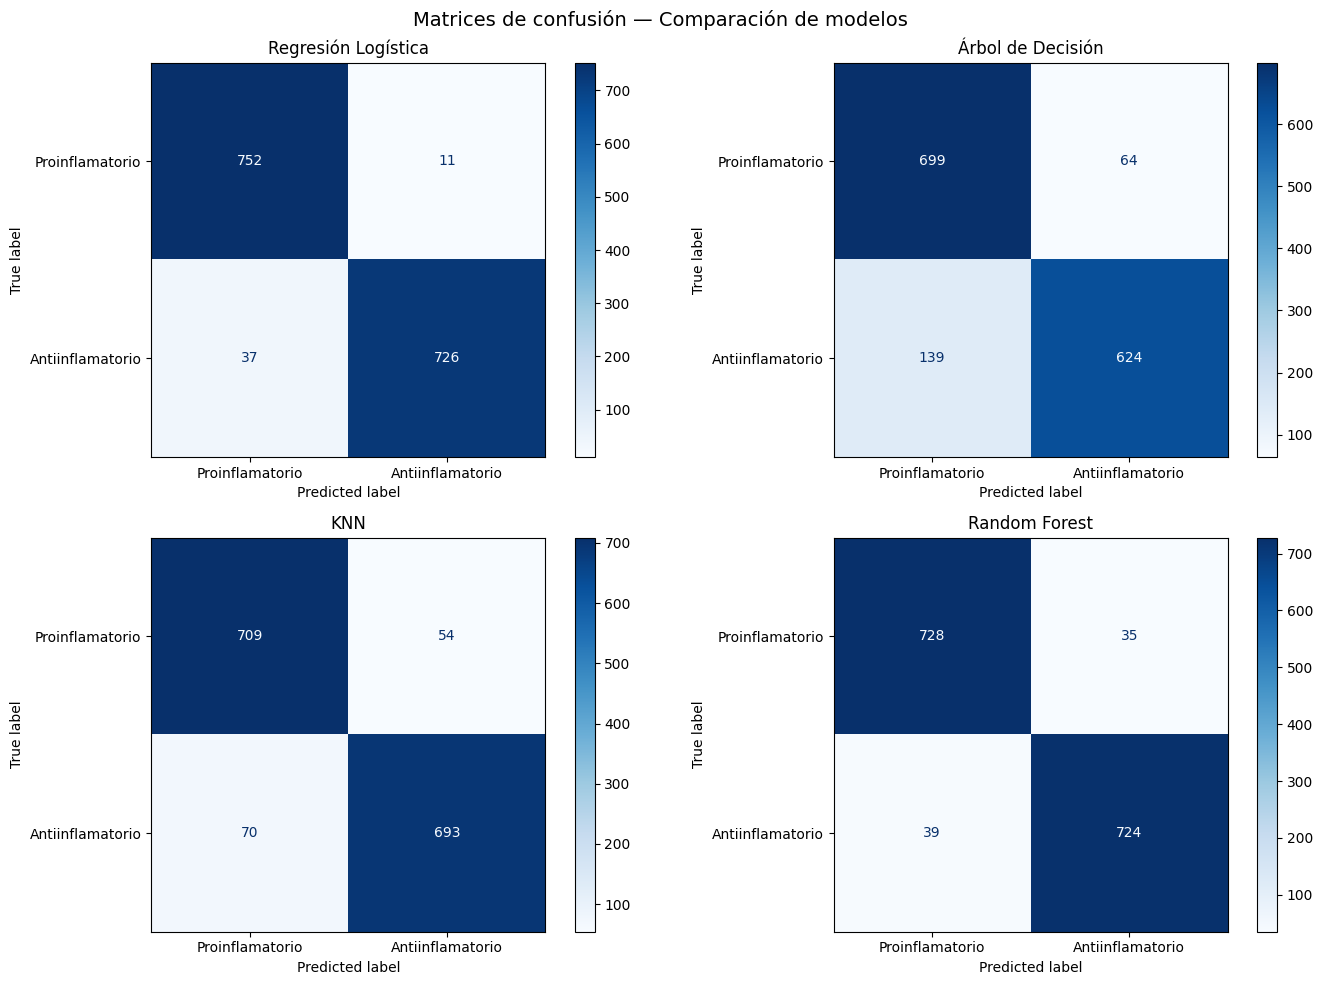

In [39]:
# ─────────────────────────────────────────────────────────────
# MATRICES DE CONFUSIÓN
# ─────────────────────────────────────────────────────────────
# Permiten visualizar:
# - Verdaderos positivos
# - Verdaderos negativos
# - Falsos positivos
# - Falsos negativos
#
# Cuanto más concentrados estén los valores en la diagonal
# principal, mejor será el desempeño del modelo.
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (nombre, y_pred) in zip(axes, predicciones.items()):
    # Calcula la matriz de confusión del modelo actual
    cm = confusion_matrix(y_test, y_pred)
    # Crea el objeto de visualización
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Proinflamatorio", "Antiinflamatorio"]
    )
    # Dibuja la matriz en el subplot correspondiente
    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=True,
        values_format="d"
    )

    ax.set_title(nombre)

plt.suptitle(
    "Matrices de confusión — Comparación de modelos",
    fontsize=14
)

plt.tight_layout()
plt.show()

### 13.2 Observaciones de las matrices de confusión

Las matrices de confusión muestran que los cuatro modelos concentran la mayoría de observaciones sobre la diagonal principal. Sin embargo, no todos los errores tienen el mismo impacto: se distingue entre **falsos positivos** (proinflamatorios clasificados como antiinflamatorios) y **falsos negativos** (antiinflamatorios clasificados como proinflamatorios).

El **falso positivo es el error más costoso**: implica recomendar activamente un alimento perjudicial. El falso negativo, en cambio, simplemente omite una opción beneficiosa —una oportunidad perdida, no una recomendación dañina.

Bajo este criterio:

- **Regresión Logística:** 752 proinflamatorios y 726 antiinflamatorios correctamente clasificados, con solo **11 falsos positivos** y 37 falsos negativos (48 errores totales). Es el modelo más conservador de los cuatro frente al error más costoso.
- **Random Forest:** 74 errores totales, con una proporción algo mayor de falsos positivos que la Regresión Logística, aunque todavía baja en términos absolutos.
- **KNN:** 124 errores totales, con un incremento notorio en ambos tipos de error respecto a los dos modelos anteriores.
- **Árbol de Decisión:** 203 errores totales, el peor desempeño. Su error predominante es el falso negativo —dificultad para identificar antiinflamatorios—, lo que en términos de costo es menos grave que los falsos positivos, pero refleja su menor capacidad de generalización.

Las matrices confirman el ranking observado en las métricas cuantitativas y refuerzan la elección de la Regresión Logística: no solo lidera en accuracy y F1, sino que también es la opción más conservadora frente al tipo de error más relevante para este problema. No se observaron patrones de error que indiquen sesgo sistemático hacia alguna de las clases en ningún modelo.

---

## **14. Validación cruzada (Cross-Validation)**

Las métricas obtenidas sobre el conjunto de prueba pueden verse influenciadas por la partición específica utilizada en la división entrenamiento-prueba. Para obtener una evaluación más robusta, se aplicó validación cruzada estratificada de 5 folds (StratifiedKFold), que preserva la proporción de clases en cada partición.

En cada iteración, una parte del conjunto de entrenamiento se reserva para validación y el resto se usa para entrenar. Cada observación participa en ambos roles a lo largo de las 5 iteraciones, lo que produce una estimación más estable del rendimiento esperado. Para cada modelo se calculó el Accuracy promedio, su desvío estándar y los valores mínimo y máximo entre folds.

El objetivo es evaluar no solo qué modelo obtiene el mejor desempeño promedio, sino también cuál es más estable frente a distintas particiones de los datos.

In [40]:
# ─────────────────────────────────────────────────────────────
# VALIDACIÓN CRUZADA (CROSS-VALIDATION)
# ─────────────────────────────────────────────────────────────
# Se utiliza StratifiedKFold para conservar la proporción de
# clases en cada partición del conjunto de entrenamiento.
#
# Para cada modelo se calcula:
# - Accuracy promedio
# - Desvío estándar
# - Accuracy mínimo
# - Accuracy máximo
#
# Estas métricas permiten evaluar tanto el desempeño como la
# estabilidad de los modelos frente a diferentes particiones
# de los datos.
# ─────────────────────────────────────────────────────────────

from sklearn.model_selection import cross_val_score, StratifiedKFold

# Estrategia de validación cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_cv = []

# Evaluación de cada modelo mediante 5-Fold Cross-Validation
for nombre, modelo in modelos.items():

    cv_scores = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    resultados_cv.append({
        "Modelo": nombre,
        "Accuracy promedio": cv_scores.mean(),
        "Desvío estándar": cv_scores.std(),
        "Min": cv_scores.min(),
        "Max": cv_scores.max()
    })

    print("\n" + "=" * 50)
    print(nombre)
    print("=" * 50)
    print("Resultados por fold:", np.round(cv_scores, 3))
    print(f"Accuracy promedio: {cv_scores.mean():.3f}")
    print(f"Desvío estándar:   {cv_scores.std():.3f}")

# Tabla resumen ordenada por Accuracy promedio
df_cv = (
    pd.DataFrame(resultados_cv)
    .sort_values("Accuracy promedio", ascending=False)
    .reset_index(drop=True)
)

display(df_cv.round(4))


Regresión Logística
Resultados por fold: [0.975 0.971 0.964 0.966 0.97 ]
Accuracy promedio: 0.969
Desvío estándar:   0.004

Árbol de Decisión
Resultados por fold: [0.891 0.878 0.868 0.893 0.874]
Accuracy promedio: 0.881
Desvío estándar:   0.010

KNN
Resultados por fold: [0.922 0.917 0.919 0.908 0.915]
Accuracy promedio: 0.916
Desvío estándar:   0.005

Random Forest
Resultados por fold: [0.947 0.938 0.939 0.948 0.948]
Accuracy promedio: 0.944
Desvío estándar:   0.004


,Modelo,Accuracy promedio,Desvío estándar,Min,Max
0,Regresión Logística,0.9694,0.0038,0.9639,0.9746
1,Random Forest,0.9440,0.0045,0.9378,0.9484
2,KNN,0.9163,0.0047,0.9082,0.9222
3,Árbol de Decisión,0.8807,0.0097,0.8680,0.8926


In [41]:
# ─────────────────────────────────────────────────────────────
# COMPARACIÓN ENTRE TEST Y VALIDACIÓN CRUZADA
# ─────────────────────────────────────────────────────────────
# Se combinan las métricas obtenidas sobre el conjunto de
# prueba con los resultados de validación cruzada para
# comparar desempeño y estabilidad.
# ─────────────────────────────────────────────────────────────

comparacion_final = resultados.merge(
    df_cv[["Modelo", "Accuracy promedio", "Desvío estándar"]],
    on="Modelo"
)

comparacion_final = comparacion_final.rename(columns={
    "Accuracy promedio": "CV Accuracy promedio",
    "Desvío estándar": "CV Accuracy desvío"
})

display(comparacion_final.round(4))

,Modelo,Accuracy,Precision,Recall,F1-Score,CV Accuracy promedio,CV Accuracy desvío
0,Regresión Logística,0.9685,0.9851,0.9515,0.9680,0.9694,0.0038
1,Random Forest,0.9515,0.9539,0.9489,0.9514,0.9440,0.0045
2,KNN,0.9187,0.9277,0.9083,0.9179,0.9163,0.0047
3,Árbol de Decisión,0.8670,0.9070,0.8178,0.8601,0.8807,0.0097


#### 14.1 Observaciones - Validación cruzada

La validación cruzada confirmó el orden de desempeño observado en el conjunto de prueba. La Regresión Logística mantuvo el primer lugar (CV Accuracy = 96,94%), seguida por Random Forest (94,40%), KNN (91,63%) y Árbol de Decisión (88,07%).

Los desvíos estándar fueron bajos en todos los modelos. La Regresión Logística presentó el más bajo (0,0038), lo que indica que su rendimiento es prácticamente independiente de qué alimentos caen en cada fold. Random Forest y KNN muestran valores similares (0,0045 y 0,0047). El Árbol de Decisión tuvo la mayor variabilidad (0,0097), señal de menor estabilidad.

La diferencia entre las métricas de test y las de validación cruzada es mínima en todos los casos —por ejemplo, la Regresión Logística obtuvo 96,85% en test y 96,94% en CV—, lo que indica que los resultados no dependen de una partición favorable y que las estimaciones de rendimiento son robustas.

---

### **14.2 Optimización de Hiperparámetros con GridSearchCV**

En la Sección 12 se entrenaron los modelos con hiperparámetros elegidos manualmente, basándose en valores estándar y criterios de simplicidad/interpretabilidad, sin optimización deliberada, de modo que funcionaran como línea de base comparable para evaluar el impacto real de la búsqueda sistemática.

Esta sección aplica `GridSearchCV` con validación cruzada de 5 folds para buscar combinaciones de hiperparámetros que mejoren el desempeño inicial. Se trata de una etapa de verificación: no reemplaza el entrenamiento de la Sección 12, sino que confirma —o cuestiona— si los valores manuales eran razonables.

Se aplica a **KNN**, **Árbol de Decisión** y **Random Forest** —los tres modelos cuyo desempeño depende de hiperparámetros estructurales—. No se aplica a la **Regresión Logística**: dado que ya lidera por amplio margen (CV = 0.9694) y que sus hiperparámetros de regularización tienen un impacto marginal esperado en un problema de estructura lineal, esta omisión no afecta la comparación entre los modelos que sí muestran margen de mejora real. Se documenta como limitación menor en la Sección 16.

Cada grilla usa el prefijo `modelo__` porque dentro del Pipeline el clasificador está identificado con ese nombre de paso, lo que permite a `GridSearchCV` distinguir los parámetros del clasificador de los del preprocesamiento.

In [42]:
# ─────────────────────────────────────────────────────────────
# GridSearchCV — KNN
# Se prueba distintos valores de n_neighbors y dos estrategias
# de ponderación de vecinos:
#   - 'uniform' : todos los vecinos pesan igual
#   - 'distance': los vecinos más cercanos pesan más que los lejanos
# ─────────────────────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV

param_grid_knn = {
    'modelo__n_neighbors': [3, 5, 7, 9, 11, 15],
    'modelo__weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(
    pipeline_knn,
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_knn.fit(X_train, y_train)

print(f"Mejores parámetros KNN : {grid_knn.best_params_}")
print(f"Mejor accuracy (CV)    : {grid_knn.best_score_:.4f}")
print(f"Accuracy modelo original (k=5, uniform) en CV: {resultados_cv_originales if False else 'ver Sección 14'}")

# Evaluamos también en el conjunto de prueba para comparar
accuracy_test_grid_knn = grid_knn.score(X_test, y_test)
print(f"Accuracy en test (modelo optimizado): {accuracy_test_grid_knn:.4f}")

Mejores parámetros KNN : {'modelo__n_neighbors': 3, 'modelo__weights': 'distance'}
Mejor accuracy (CV)    : 0.9259
Accuracy modelo original (k=5, uniform) en CV: ver Sección 14
Accuracy en test (modelo optimizado): 0.9240


In [43]:
# ─────────────────────────────────────────────────────────────
# GridSearchCV — Árbol de Decisión
# Se prueba distintas profundidades máximas y un segundo
# hiperparámetro (min_samples_split) que controla cuántas
# muestras mínimas necesita un nodo para volver a dividirse
# — otra forma de controlar el sobreajuste además de max_depth.
# ─────────────────────────────────────────────────────────────
param_grid_arbol = {
    'modelo__max_depth': [3, 4, 5, 6, 8, 10, None],
    'modelo__min_samples_split': [2, 5, 10]
}

grid_arbol = GridSearchCV(
    pipeline_arbol,
    param_grid_arbol,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_arbol.fit(X_train, y_train)

print(f"Mejores parámetros Árbol : {grid_arbol.best_params_}")
print(f"Mejor accuracy (CV)      : {grid_arbol.best_score_:.4f}")

accuracy_test_grid_arbol = grid_arbol.score(X_test, y_test)
print(f"Accuracy en test (modelo optimizado): {accuracy_test_grid_arbol:.4f}")

Mejores parámetros Árbol : {'modelo__max_depth': 10, 'modelo__min_samples_split': 2}
Mejor accuracy (CV)      : 0.9259
Accuracy en test (modelo optimizado): 0.9115


In [44]:
# ─────────────────────────────────────────────────────────────
# GridSearchCV — Random Forest
# Se prueba distintos números de árboles y profundidades
# máximas para verificar si existe una configuración mejor
# que la usada originalmente (n_estimators=200, sin límite
# de profundidad).
# ─────────────────────────────────────────────────────────────
param_grid_rf = {
    'modelo__n_estimators': [100, 200, 300],
    'modelo__max_depth': [None, 10, 20]
}

grid_rf = GridSearchCV(
    pipeline_bosque,
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print(f"Mejores parámetros Random Forest : {grid_rf.best_params_}")
print(f"Mejor accuracy (CV)               : {grid_rf.best_score_:.4f}")

accuracy_test_grid_rf = grid_rf.score(X_test, y_test)
print(f"Accuracy en test (modelo optimizado): {accuracy_test_grid_rf:.4f}")

Mejores parámetros Random Forest : {'modelo__max_depth': None, 'modelo__n_estimators': 100}
Mejor accuracy (CV)               : 0.9467
Accuracy en test (modelo optimizado): 0.9482


In [45]:
# ─────────────────────────────────────────────────────────────
# Comparación: modelos originales (Sección 12) vs. optimizados
# Se calcula accuracy de CV y de test.
# ─────────────────────────────────────────────────────────────
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv_5fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Accuracy en validación cruzada — modelos originales
cv_knn_original   = cross_val_score(pipeline_knn,   X_train, y_train, cv=cv_5fold, scoring="accuracy").mean()
cv_arbol_original = cross_val_score(pipeline_arbol, X_train, y_train, cv=cv_5fold, scoring="accuracy").mean()
cv_rf_original     = cross_val_score(pipeline_bosque, X_train, y_train, cv=cv_5fold, scoring="accuracy").mean()

# Accuracy en test — modelos originales (ya entrenados desde la Sección 12)
test_knn_original   = pipeline_knn.score(X_test, y_test)
test_arbol_original = pipeline_arbol.score(X_test, y_test)
test_rf_original     = pipeline_bosque.score(X_test, y_test)

comparacion_grid = pd.DataFrame({
    "Modelo": [
        "KNN (original, k=5)", "KNN (optimizado)",
        "Árbol (original, max_depth=4)", "Árbol (optimizado)",
        "Random Forest (original, n_estimators=200)", "Random Forest (optimizado)",
    ],
    "Accuracy CV": [
        cv_knn_original, grid_knn.best_score_,
        cv_arbol_original, grid_arbol.best_score_,
        cv_rf_original, grid_rf.best_score_,
    ],
    "Accuracy Test": [
        test_knn_original, accuracy_test_grid_knn,
        test_arbol_original, accuracy_test_grid_arbol,
        test_rf_original, accuracy_test_grid_rf,
    ]
})

display(comparacion_grid.round(4))

,Modelo,Accuracy CV,Accuracy Test
0,"KNN (original, k=5)",0.9163,0.9187
1,KNN (optimizado),0.9259,0.9240
2,"Árbol (original, max_depth=4)",0.8807,0.8670
3,Árbol (optimizado),0.9259,0.9115
4,"Random Forest (original, n_estimators=200)",0.9440,0.9515
5,Random Forest (optimizado),0.9467,0.9482


##### 14.2.1 Observaciones — GridSearchCV

| Modelo | Hiperparámetros originales | Hiperparámetros óptimos (GridSearch) | Accuracy CV original | Accuracy CV óptimo | Mejora |
|---|---|---|---|---|---|
| KNN | n_neighbors=5, weights='uniform' | n_neighbors=3, weights='distance' | 0.9163 | 0.9259 | +0.96 p.p. |
| Árbol de Decisión | max_depth=4 | max_depth=10, min_samples_split=2 | 0.8807 | 0.9259 | +4.52 p.p. |
| Random Forest | n_estimators=200, max_depth=None | n_estimators=100, max_depth=None | 0.9440 | 0.9467 | +0.27 p.p. |

**KNN:** mejora moderada al usar 3 vecinos con ponderación por distancia en lugar de 5 con peso uniforme. Los alimentos más similares en composición nutricional pesan más en la decisión, lo cual es coherente con la lógica del problema.

**Árbol de Decisión:** la mejora más marcada (+4,52 p.p.), lograda al aumentar la profundidad máxima de 4 a 10. El modelo original estaba subajustado (*underfitting*): la restricción de profundidad, elegida por interpretabilidad visual, impedía capturar la estructura del problema. Cabe notar que el árbol optimizado pierde gran parte de esa interpretabilidad —un árbol de 10 niveles ya no puede graficarse ni leerse con la misma claridad.

**Random Forest:** la mejora es mínima (+0,27 p.p.) y los hiperparámetros óptimos son casi idénticos a los originales. Esto confirma que el modelo ya operaba cerca de su techo de desempeño antes de la búsqueda.

**Comparación con la Regresión Logística:** ninguno de los tres modelos optimizados (KNN = 0.9259, Árbol = 0.9259, Random Forest = 0.9467) logra acercarse a la Regresión Logística (CV = 0.9694, sin ningún ajuste). Las mejoras obtenidas fueron limitadas, lo que confirma que las configuraciones iniciales ya eran adecuadas y que la naturaleza del problema es esencialmente lineal —verificado ahora desde un tercer ángulo de evidencia independiente.

---

## **15. Visualizaciones e Interpretación de Errores y Aciertos**

Las métricas numéricas de las Secciones 13 y 14 permiten comparar el rendimiento global de los modelos, pero no muestran cómo se comporta cada uno frente a distintos subconjuntos de datos, qué variables influyen en sus decisiones ni en qué situaciones tienden a cometer errores. Esta sección incorpora análisis gráficos y cualitativos que complementan la evaluación cuantitativa.

| Bloque | Pregunta que responde |
|---|---|
| 15.1 Comparación visual de Cross-Validation | ¿Qué tan estable es cada modelo entre distintas particiones del entrenamiento? |
| 15.2 Comparación original vs. GridSearchCV | ¿La optimización de hiperparámetros mejora realmente el desempeño? |
| 15.3 Curvas ROC y AUC | ¿Qué capacidad tiene cada modelo para discriminar entre clases a distintos umbrales de decisión? |
| 15.4 Tabla comparativa final | ¿Cómo se sintetizan todas las métricas, incluyendo los resultados antes y después de GridSearchCV? |
| 15.5 Importancia de variables | ¿Qué nutrientes son más influyentes y coincide esa jerarquía con los pesos teóricos del DII? |
| 15.6 Análisis de errores e incertidumbre | ¿En qué alimentos se equivoca el modelo y cuáles son los casos con mayor incertidumbre? |

### 15.1 Comparación Visual de la Validación Cruzada
El siguiente gráfico representa los resultados de validación cruzada (5-Fold) para cada modelo. Las barras indican el accuracy promedio obtenido en los distintos folds, mientras que las líneas de error representan el desvío estándar, reflejando la estabilidad del modelo entre particiones.
Este formato permite comparar simultáneamente el rendimiento promedio y la consistencia de cada modelo de forma visual.

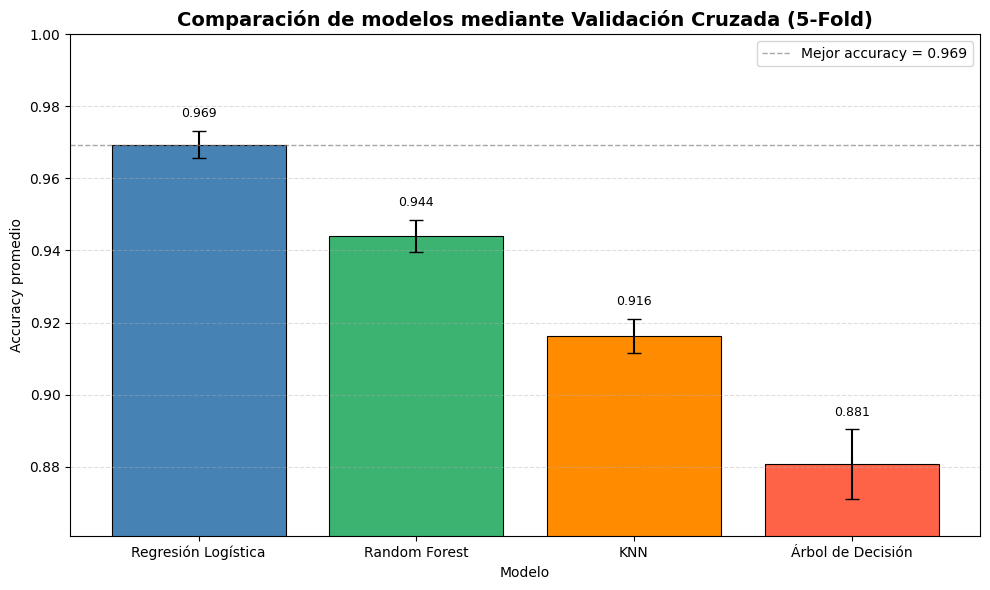

In [46]:
# Gráfico de barras con desvío estándar como barra de error

# Ordenar modelos por accuracy (opcional)
df_plot = df_cv.sort_values("Accuracy promedio", ascending=False)

# Crear figura
fig, ax = plt.subplots(figsize=(10, 6))

colores = ["steelblue", "mediumseagreen", "darkorange", "tomato"]

# Gráfico de barras
barras = ax.bar(
    df_plot["Modelo"],
    df_plot["Accuracy promedio"],
    yerr=df_plot["Desvío estándar"],
    capsize=5,
    color=colores[:len(df_plot)],
    edgecolor="black",
    linewidth=0.8
)

# Etiquetas y título
ax.set_title(
    "Comparación de modelos mediante Validación Cruzada (5-Fold)",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Modelo")
ax.set_ylabel("Accuracy promedio")

# Ajuste automático del eje Y
margen = 0.02
ax.set_ylim(
    max(0, df_plot["Accuracy promedio"].min() - margen),
    min(1.0, df_plot["Accuracy promedio"].max() + 0.05)
)

# Línea del mejor modelo
mejor_accuracy = df_plot["Accuracy promedio"].max()
ax.axhline(
    y=mejor_accuracy,
    linestyle="--",
    linewidth=1,
    color="gray",
    alpha=0.7,
    label=f"Mejor accuracy = {mejor_accuracy:.3f}"
)

# Mostrar valores sobre las barras
for barra, accuracy, desv in zip(
    barras,
    df_plot["Accuracy promedio"],
    df_plot["Desvío estándar"]
):
    ax.text(
        barra.get_x() + barra.get_width()/2,
        accuracy + desv + 0.003,
        f"{accuracy:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Cuadrícula
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Leyenda
ax.legend()

plt.tight_layout()
plt.show()

#### Observaciones - Comparación Visual de la Validación Cruzada

La Regresión Logística lidera en accuracy promedio (0,969) y presenta una de las barras de error más cortas, lo que indica alta estabilidad entre folds. Random Forest la sigue con buen rendimiento (0,944) y desvío bajo. KNN muestra un desempeño intermedio (0,916) y el Árbol de Decisión combina el accuracy más bajo (0,881) con la mayor dispersión entre folds —señal de menor estabilidad y capacidad de generalización.

Los desvíos estándar son bajos en todos los modelos, lo que indica que los resultados son consistentes y no dependen de particiones específicas. La elección del modelo final debe basarse en el rendimiento promedio y en criterios adicionales como interpretabilidad y tipo de error, no en diferencias de estabilidad que son menores en todos los casos.

### 15.2 Comparación original vs GridSearchCV (Optimización de hiperparámetros)

Esta sección retoma los resultados de la Sección 14.2 (GridSearchCV) y los traduce en una visualización comparativa. Para cada uno de los tres modelos optimizados (KNN, Árbol de Decisión y Random Forest) se muestran dos barras lado a lado: el accuracy en validación cruzada con los hiperparámetros originales de la Sección 12, y el accuracy con los hiperparámetros óptimos encontrados por GridSearchCV.

La Regresión Logística se representa como una línea de referencia horizontal — no tiene barras "antes/después" porque no fue sometida a GridSearchCV, pero es el punto de comparación clave: si ninguno de los tres modelos optimizados logra superar esa línea, eso confirma que la optimización de hiperparámetros no alcanza para cerrar la brecha con el modelo lineal en este problema específico.

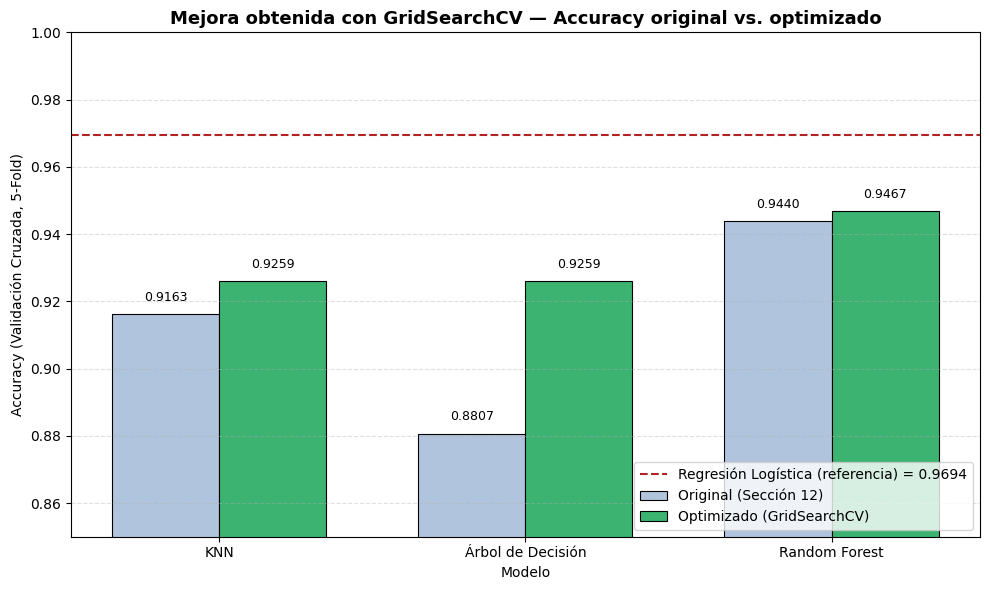

,Modelo,Accuracy original,Accuracy optimizado,Mejora (p.p.),Brecha vs. Reg. Logística
0,KNN,0.9163,0.9259,0.9670,4.3474
1,Árbol de Decisión,0.8807,0.9259,4.5235,4.3472
2,Random Forest,0.9440,0.9467,0.2786,2.2660


In [47]:
# ─────────────────────────────────────────────────────────────
# Gráfico comparativo: Accuracy CV original vs. optimizado
#
# Para KNN, Árbol de Decisión y Random Forest se muestran dos
# barras lado a lado: el accuracy con los hiperparámetros
# originales (Sección 12) y el accuracy con los hiperparámetros
# óptimos encontrados por GridSearchCV (Sección 14.2).
#
# La Regresión Logística se incluye como línea de referencia
# horizontal, ya que no fue optimizada (no tiene barra "antes/
# después"), pero es el punto de comparación clave: ¿alguno de
# los modelos optimizados logra acercarse a su desempeño?
# ─────────────────────────────────────────────────────────────
# ── Datos: accuracy CV antes y después de GridSearchCV ───────
modelos_opt = ["KNN", "Árbol de Decisión", "Random Forest"]
accuracy_original  = [cv_knn_original, cv_arbol_original, cv_rf_original]
accuracy_optimizado = [grid_knn.best_score_, grid_arbol.best_score_, grid_rf.best_score_]

# Referencia: Regresión Logística (sin optimizar)
accuracy_logistica = 0.9694  # CV Accuracy obtenido en la Sección 14

# ── Construcción del gráfico de barras agrupadas ──────────────
x = np.arange(len(modelos_opt))  # posiciones base para cada modelo
ancho_barra = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

barras_originales = ax.bar(
    x - ancho_barra/2, accuracy_original, ancho_barra,
    label="Original (Sección 12)",
    color="lightsteelblue", edgecolor="black", linewidth=0.8
)

barras_optimizadas = ax.bar(
    x + ancho_barra/2, accuracy_optimizado, ancho_barra,
    label="Optimizado (GridSearchCV)",
    color="mediumseagreen", edgecolor="black", linewidth=0.8
)

# ── Línea de referencia: Regresión Logística ─────────────────
ax.axhline(
    y=accuracy_logistica,
    color="firebrick", linestyle="--", linewidth=1.5,
    label=f"Regresión Logística (referencia) = {accuracy_logistica:.4f}"
)

# ── Etiquetas con el valor exacto sobre cada barra ───────────
for barra in barras_originales:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, altura + 0.003,
             f"{altura:.4f}", ha="center", va="bottom", fontsize=9)

for barra in barras_optimizadas:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, altura + 0.003,
             f"{altura:.4f}", ha="center", va="bottom", fontsize=9)

# ── Estética general ──────────────────────────────────────────
ax.set_xlabel("Modelo")
ax.set_ylabel("Accuracy (Validación Cruzada, 5-Fold)")
ax.set_title(
    "Mejora obtenida con GridSearchCV — Accuracy original vs. optimizado",
    fontsize=13, fontweight="bold"
)
ax.set_xticks(x)
ax.set_xticklabels(modelos_opt)
ax.set_ylim(0.85, 1.0)   # recorte del eje Y para que las diferencias sean visibles
ax.legend(loc="lower right")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ── Tabla resumen de las mejoras ───────────────────────────────
mejoras = pd.DataFrame({
    "Modelo": modelos_opt,
    "Accuracy original": accuracy_original,
    "Accuracy optimizado": accuracy_optimizado,
    "Mejora (p.p.)": [
        (opt - orig) * 100
        for orig, opt in zip(accuracy_original, accuracy_optimizado)
    ],
    "Brecha vs. Reg. Logística": [
        (accuracy_logistica - opt) * 100
        for opt in accuracy_optimizado
    ]
})
display(mejoras.round(4))

#### Observaciones — Comparación original vs. optimizado

El gráfico confirma visualmente lo señalado en la Sección 14.2: los tres modelos mejoran con la optimización, pero ninguno alcanza a la Regresión Logística. El Árbol de Decisión es el que más gana, pasando de la posición más baja a equipararse con KNN optimizado —aunque a costa de perder interpretabilidad visual. Random Forest prácticamente no se mueve, lo que ratifica que ya operaba cerca de su techo.

> **Nota sobre la escala:** el eje Y no comienza en 0 para hacer visibles las diferencias entre modelos. En términos absolutos, la brecha entre el mejor (Regresión Logística, 0,9694) y el peor original (Árbol de Decisión, 0,8807) es de aproximadamente 9 puntos porcentuales.

### 15.3 Curvas ROC

Se grafican las cuatro curvas ROC en un mismo gráfico para comparar visualmente la capacidad de discriminación de cada modelo, junto con su AUC (Área Bajo la Curva).

> **Aclaración — Curva ROC vs. Validación Cruzada:** son dos técnicas distintas que no deben confundirse. La validación cruzada (Sección 14)  estima la capacidad de generalización del modelo mediante múltiples particiones del conjunto de entrenamiento, proporcionando una medida promedio de su rendimiento. En cambio, la curva ROC se obtiene a partir de las probabilidades predichas por un modelo ya entrenado sobre el conjunto de prueba (`X_test`) y evalúa cómo varían la sensibilidad y la especificidad al modificar el umbral de decisión. Por lo tanto, ambas técnicas son complementarias: la validación cruzada evalúa la estabilidad del modelo, mientras que la curva ROC analiza su capacidad de discriminación entre clases.

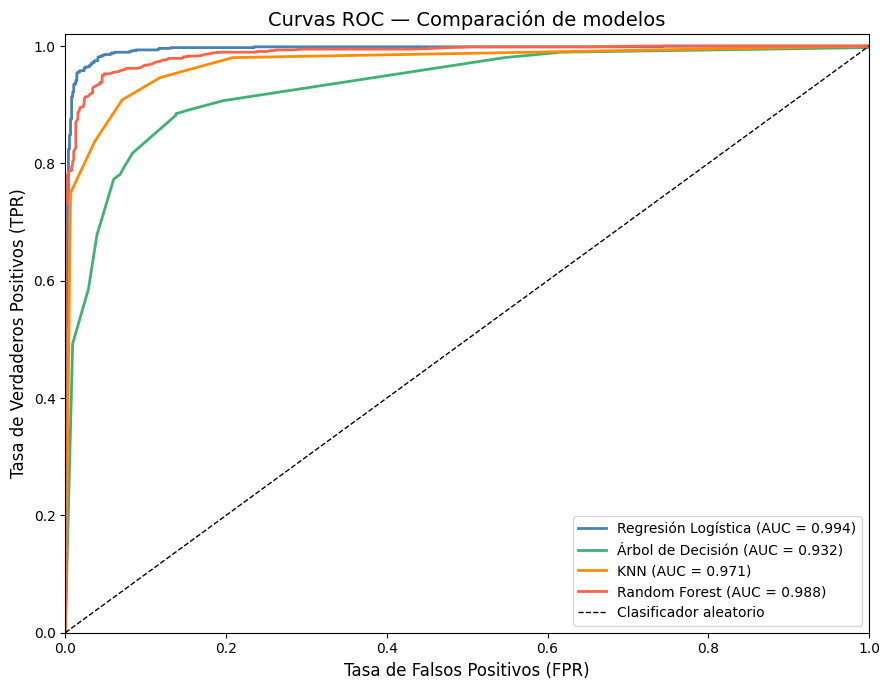

,Modelo,AUC
0,Regresión Logística,0.9941
1,Random Forest,0.9882
2,KNN,0.9708
3,Árbol de Decisión,0.9320


In [48]:
# ─────────────────────────────────────────────────────────────
# Curvas ROC — Comparación de los 4 modelos
# ─────────────────────────────────────────────────────────────

from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(9, 7))

colores = {
    "Regresión Logística": "steelblue",
    "Árbol de Decisión":   "mediumseagreen",
    "KNN":                 "darkorange",
    "Random Forest":       "tomato",
}

# Diccionario de modelos (pipelines)
modelos = {
    "Regresión Logística": pipeline_logistico,
    "Árbol de Decisión": pipeline_arbol,
    "KNN": pipeline_knn,
    "Random Forest": pipeline_bosque,
}

# Guardamos AUC para mostrar después
auc_resultados = []

for nombre, modelo in modelos.items():

    # Probabilidad de la clase positiva (Antiinflamatorio)
    probas = modelo.predict_proba(X_test)[:, 1]

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, probas)

    # Área bajo la curva
    auc = roc_auc_score(y_test, probas)

    auc_resultados.append({
        "Modelo": nombre,
        "AUC": auc
    })

    ax.plot(
        fpr,
        tpr,
        label=f"{nombre} (AUC = {auc:.3f})",
        color=colores[nombre],
        linewidth=2
    )

# Línea diagonal = clasificador aleatorio
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=1,
    label="Clasificador aleatorio"
)

ax.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=12)
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=12)
ax.set_title("Curvas ROC — Comparación de modelos", fontsize=14)

ax.legend(loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

# Tabla de AUC
df_auc = pd.DataFrame(auc_resultados).sort_values(
    "AUC",
    ascending=False
).reset_index(drop=True)

display(df_auc.round(4))

#### Observaciones - Curvas ROC

Los cuatro modelos superan ampliamente la diagonal del clasificador aleatorio (AUC = 0,5). La Regresión Logística obtiene el AUC más alto (0,9941), seguida por Random Forest, KNN y Árbol de Decisión —el mismo orden observado en todas las métricas anteriores, lo que refuerza la consistencia de los resultados.

> **Curva ROC vs. matriz de confusión:** son herramientas complementarias, no alternativas. El AUC resume la capacidad del modelo para separar ambas clases a lo largo de todos los umbrales posibles. La matriz de confusión, en cambio, muestra el desempeño concreto en el umbral efectivamente utilizado (0,5 por defecto) y permite identificar qué tipo de error comete cada modelo —información que el AUC, por sí solo, no aporta.

### 15.4 Tabla Comparativa Final

Se consolidan en una única tabla todas las métricas obtenidas a lo largo del proyecto: test (Sección 13), validación cruzada con su desvío estándar (Sección 14), AUC (Sección 15.3) y los resultados de la optimización de hiperparámetros (Sección 14.2). La tabla se divide en dos bloques: modelos con su configuración original y los tres modelos no lineales tras GridSearchCV. La Regresión Logística no aparece en el bloque optimizado porque no se le aplicó búsqueda de hiperparámetros.

In [49]:
# ─────────────────────────────────────────────────────────────
# TABLA COMPARATIVA FINAL — original + GridSearchCV
# ─────────────────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# ── Bloque 1: modelos originales ─────────────────────────────
bloque_original = (
    resultados
    .merge(df_cv[["Modelo", "Accuracy promedio", "Desvío estándar"]], on="Modelo")
    .merge(df_auc, on="Modelo")
    .rename(columns={
        "Accuracy promedio": "CV Accuracy",
        "Desvío estándar":   "CV Std",
    })
)
bloque_original.insert(0, "Configuración", "Original")

# ── Bloque 2: modelos optimizados (GridSearchCV) ─────────────
bloque_grid = pd.DataFrame([
    {
        "Configuración": "GridSearchCV",
        "Modelo":        "KNN",
        "Accuracy":      accuracy_test_grid_knn,
        "Precision":     precision_score(y_test, grid_knn.predict(X_test)),
        "Recall":        recall_score(y_test, grid_knn.predict(X_test)),
        "F1-Score":      f1_score(y_test, grid_knn.predict(X_test)),
        "CV Accuracy":   grid_knn.best_score_,
        "CV Std":        grid_knn.cv_results_['std_test_score'][grid_knn.best_index_],
        "AUC":           roc_auc_score(y_test, grid_knn.predict_proba(X_test)[:, 1]),
    },
    {
        "Configuración": "GridSearchCV",
        "Modelo":        "Árbol de Decisión",
        "Accuracy":      accuracy_test_grid_arbol,
        "Precision":     precision_score(y_test, grid_arbol.predict(X_test)),
        "Recall":        recall_score(y_test, grid_arbol.predict(X_test)),
        "F1-Score":      f1_score(y_test, grid_arbol.predict(X_test)),
        "CV Accuracy":   grid_arbol.best_score_,
        "CV Std":        grid_arbol.cv_results_['std_test_score'][grid_arbol.best_index_],
        "AUC":           roc_auc_score(y_test, grid_arbol.predict_proba(X_test)[:, 1]),
    },
    {
        "Configuración": "GridSearchCV",
        "Modelo":        "Random Forest",
        "Accuracy":      accuracy_test_grid_rf,
        "Precision":     precision_score(y_test, grid_rf.predict(X_test)),
        "Recall":        recall_score(y_test, grid_rf.predict(X_test)),
        "F1-Score":      f1_score(y_test, grid_rf.predict(X_test)),
        "CV Accuracy":   grid_rf.best_score_,
        "CV Std":        grid_rf.cv_results_['std_test_score'][grid_rf.best_index_],
        "AUC":           roc_auc_score(y_test, grid_rf.predict_proba(X_test)[:, 1]),
    },
])

# ── Combinar, ordenar y mostrar ───────────────────────────────
tabla_final = (
    pd.concat([bloque_original, bloque_grid], ignore_index=True)
    .sort_values(["Modelo", "Configuración"], ascending=[True, False])
    .reset_index(drop=True)
)

display(tabla_final.round(4))

,Configuración,Modelo,Accuracy,Precision,Recall,F1-Score,CV Accuracy,CV Std,AUC
0,Original,KNN,0.9187,0.9277,0.9083,0.9179,0.9163,0.0047,0.9708
1,GridSearchCV,KNN,0.9240,0.9366,0.9096,0.9229,0.9259,0.0093,0.9672
2,Original,Random Forest,0.9515,0.9539,0.9489,0.9514,0.9440,0.0045,0.9882
3,GridSearchCV,Random Forest,0.9482,0.9536,0.9423,0.9479,0.9467,0.0076,0.9875
4,Original,Regresión Logística,0.9685,0.9851,0.9515,0.9680,0.9694,0.0038,0.9941
5,Original,Árbol de Decisión,0.8670,0.9070,0.8178,0.8601,0.8807,0.0097,0.9320
6,GridSearchCV,Árbol de Decisión,0.9115,0.9110,0.9122,0.9116,0.9259,0.0059,0.9235


#### Observaciones — Tabla comparativa final

La tabla consolida cuatro fuentes de evidencia independientes y confirma el mismo orden en todas ellas: **Regresión Logística > Random Forest > KNN > Árbol de Decisión** con configuración original.

La optimización produce efectos distintos según el modelo. El **Árbol de Decisión** es el único que mejora simultáneamente en accuracy CV (+4,52 p.p.) y en estabilidad (CV Std baja de 0,0097 a 0,0059), confirmando que su configuración original estaba subajustada. **KNN** mejora en accuracy pero con un leve aumento del desvío (0,0047 → 0,0093), aún bajo en términos absolutos. **Random Forest** presenta el caso más llamativo: el modelo optimizado obtiene mejor CV Accuracy (0,9467 vs 0,9440) pero menor Accuracy en test (0,9482 vs 0,9515), lo que sugiere que los hiperparámetros originales capturaban mejor la generalización al conjunto de prueba puntual —diferencia en cualquier caso marginal.

Ninguno de los tres modelos optimizados alcanza a la Regresión Logística, que sin ningún ajuste mantiene el mejor resultado en todas las columnas y el CV Std más bajo de la tabla (0,0038).

### 15.5 Importancia de Variables

Se comparan los nutrientes más influyentes según la Regresión Logística (coeficientes) y Random Forest (feature importance), para evaluar si los modelos "redescubren" desde los datos una jerarquía similar a los pesos teóricos del DII (Sección 6).

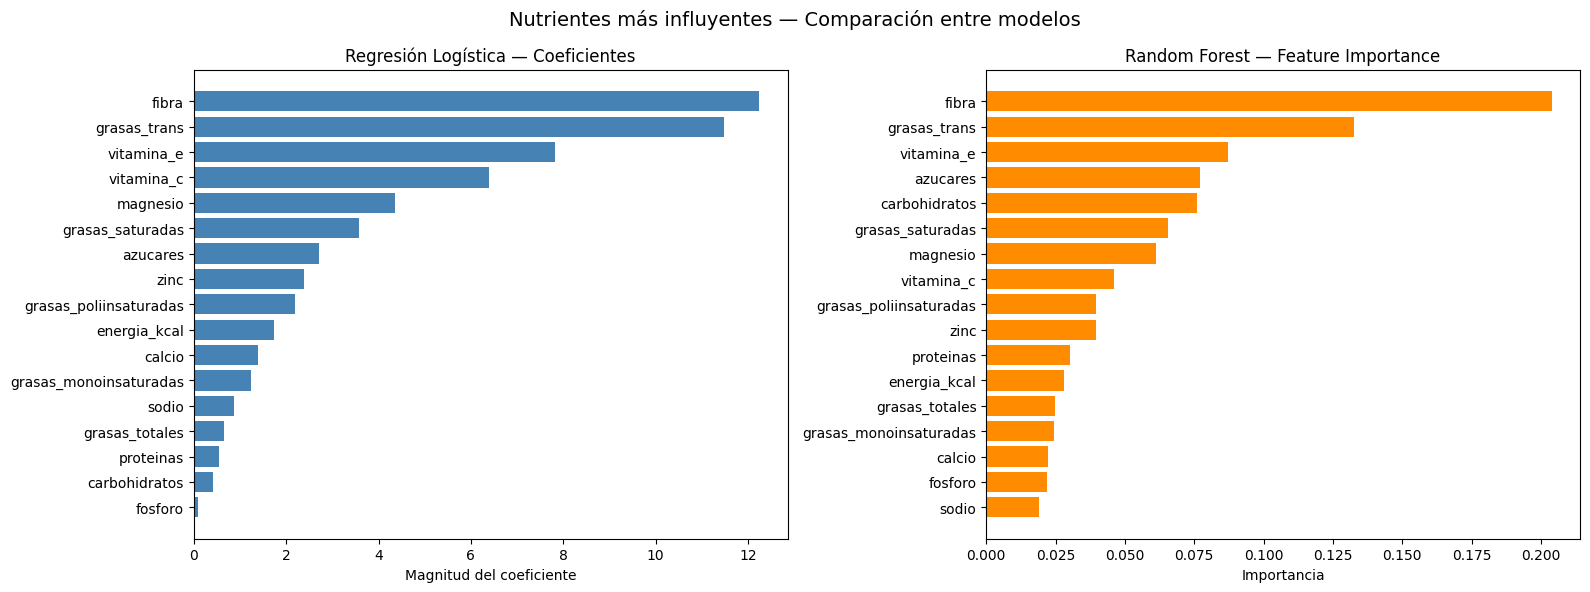

,Nutriente,Coeficiente,Importancia absoluta
4,fibra,12.241750,12.241750
12,grasas_trans,-11.483240,11.483240
10,vitamina_e,7.812468,7.812468
11,vitamina_c,6.400159,6.400159
6,magnesio,4.364615,4.364615
13,grasas_saturadas,-3.575553,3.575553
16,azucares,-2.701851,2.701851
9,zinc,2.388122,2.388122
15,grasas_poliinsaturadas,2.190755,2.190755
3,energia_kcal,-1.745948,1.745948


,Nutriente,Importancia
4,fibra,0.203930
12,grasas_trans,0.132526
10,vitamina_e,0.087071
16,azucares,0.077028
2,carbohidratos,0.076051
13,grasas_saturadas,0.065697
6,magnesio,0.061200
11,vitamina_c,0.046147
15,grasas_poliinsaturadas,0.039767
9,zinc,0.039719


In [50]:
# ─────────────────────────────────────────────────────────────
# Importancia de variables
# ─────────────────────────────────────────────────────────────

# Regresión Logística
coeficientes = pd.DataFrame({
    "Nutriente": X.columns,
    "Coeficiente": pipeline_logistico.named_steps["modelo"].coef_[0]
})

coeficientes["Importancia absoluta"] = coeficientes["Coeficiente"].abs()

coeficientes = (
    coeficientes
    .sort_values("Importancia absoluta", ascending=False)
)

# Random Forest
importancias_rf = pd.DataFrame({
    "Nutriente": X.columns,
    "Importancia": pipeline_bosque.named_steps["modelo"].feature_importances_
})

importancias_rf = (
    importancias_rf
    .sort_values("Importancia", ascending=False)
)

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(
    coeficientes["Nutriente"],
    coeficientes["Importancia absoluta"],
    color="steelblue"
)
axes[0].set_title("Regresión Logística — Coeficientes")
axes[0].set_xlabel("Magnitud del coeficiente")
axes[0].invert_yaxis()

axes[1].barh(
    importancias_rf["Nutriente"],
    importancias_rf["Importancia"],
    color="darkorange"
)
axes[1].set_title("Random Forest — Feature Importance")
axes[1].set_xlabel("Importancia")
axes[1].invert_yaxis()

fig.suptitle(
    "Nutrientes más influyentes — Comparación entre modelos",
    fontsize=14
)

plt.tight_layout()
plt.show()

display(coeficientes.head(10))
display(importancias_rf.head(10))

#### Observaciones - Importancia de Variables

Ambos modelos coinciden en identificar **fibra** y **grasas trans** como los dos nutrientes más influyentes, en el mismo orden. Esto es coherente con los pesos teóricos del DII: la fibra tiene el coeficiente positivo más alto (+0,61) y las grasas trans el negativo más extremo (−0,73) entre los 17 nutrientes utilizados. Los algoritmos redescubrieron desde los datos la jerarquía propuesta por el índice, en línea con lo señalado en la Sección 3 sobre la naturaleza del problema.

### 15.6 Análisis de Errores e Incertidumbre

Más allá del accuracy global, interesa entender dónde se equivoca el modelo y cuándo está inseguro de su predicción. Se analiza la Regresión Logística —modelo seleccionado como final a partir de la evaluación comparativa de la Sección 15.4— desde dos ángulos:

- **Errores:** comparar el perfil nutricional promedio de los alimentos mal clasificados contra los bien clasificados.
- **Incertidumbre:** identificar los alimentos cuya probabilidad predicha está más cerca de 0,5 —los casos límite del DII—.

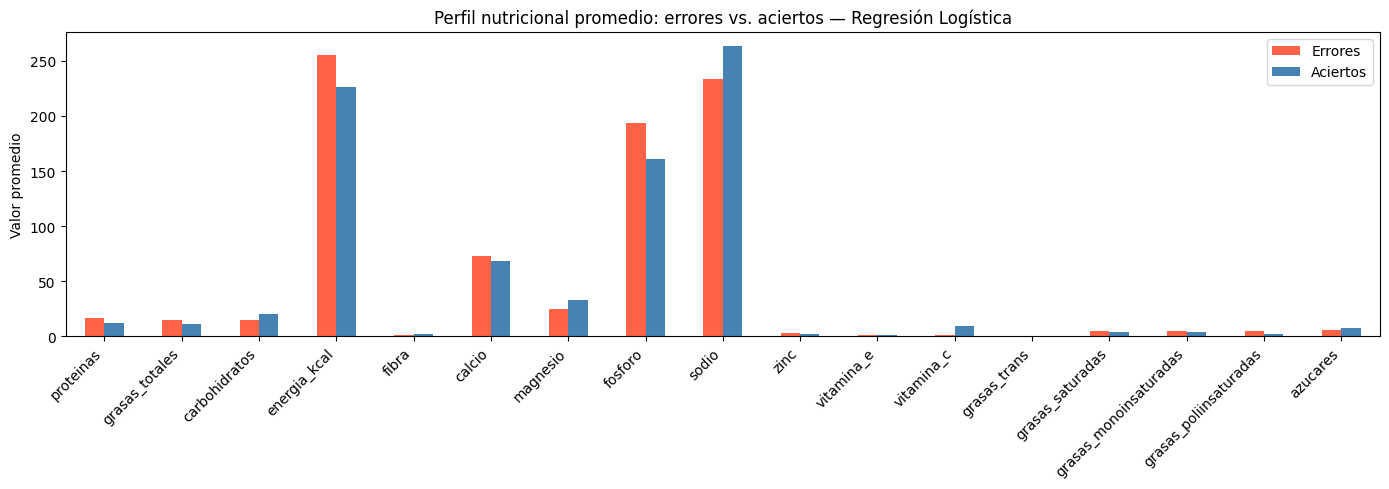


Total de errores: 48 de 1526 (3.1%)



,description,categoria,indice_dii,es_antiinflamatorio
3532,"Salad dressing, poppyseed, creamy",Fats and Oils,-0.123490,1
575,"Restaurant, Chinese, sesame chicken",Restaurant Foods,-0.178210,1
6968,"Emu, top loin, cooked, broiled",Poultry Products,-0.179562,1
5541,"Beef, loin, top sirloin petite roast/filet, bo...",Beef Products,-0.183830,1
5286,"Sweet rolls, cinnamon, refrigerated dough with...",Baked Products,-0.200437,0
3622,"Turkey, retail parts, drumstick, meat and skin...",Poultry Products,-0.182521,1
7548,"Crackers, cheese, low sodium",Baked Products,-0.178740,1
167,"Restaurant, Chinese, orange chicken",Restaurant Foods,-0.166508,1
5855,"Beef, round, knuckle, tip side, steak, separab...",Beef Products,-0.164266,1
6987,"Chicken, dark meat, drumstick, meat only, with...",Poultry Products,-0.179866,1


In [51]:
# ─────────────────────────────────────────────────────────────
# Análisis de errores
# ─────────────────────────────────────────────────────────────

# Errores de la Regresión Logística (modelo de referencia)
y_pred_log = predicciones["Regresión Logística"]

errores_idx  = X_test.index[y_test.values != y_pred_log]
aciertos_idx = X_test.index[y_test.values == y_pred_log]

# Perfil nutricional promedio: errores vs. aciertos
perfil_errores  = X_test.loc[errores_idx].mean()
perfil_aciertos = X_test.loc[aciertos_idx].mean()

comp = pd.DataFrame({
    "Errores":  perfil_errores,
    "Aciertos": perfil_aciertos
})

comp.plot(kind="bar", figsize=(14, 5), color=["tomato", "steelblue"])
plt.title("Perfil nutricional promedio: errores vs. aciertos — Regresión Logística")
plt.ylabel("Valor promedio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Mostrar los alimentos mal clasificados con su descripción
print(f"\nTotal de errores: {len(errores_idx)} de {len(y_test)} ({len(errores_idx)/len(y_test)*100:.1f}%)\n")

df_limpio.loc[errores_idx, ["description", "categoria", "indice_dii", "es_antiinflamatorio"]].head(15)

In [52]:
# ─────────────────────────────────────────────────────────────
# Casos más ambiguos (probabilidad más cercana a 0.5)
# Mientras el bloque anterior analiza los errores del modelo,
# este apartado se centra en su grado de incertidumbre: alimentos
# cuya probabilidad de pertenecer a una clase es cercana a 0.5.
# Estos casos representan los límites del DII, es decir, productos
# con perfiles nutricionales mixtos o intermedios.
#
# Se utiliza el objeto `pipeline_logistico` en lugar de un modelo
# aislado, ya que el pipeline aplica internamente el preprocesamiento
# de manera consistente con el resto del notebook. Por ello, se emplea
# directamente `X_test` sin necesidad de escalar manualmente.
# ─────────────────────────────────────────────────────────────
probas = pipeline_logistico.predict_proba(X_test)

df_probas = pd.DataFrame(
    {"prob_antiinflamatorio": probas[:, 1]},
    index=X_test.index
)
df_probas["distancia_50"] = abs(df_probas["prob_antiinflamatorio"] - 0.5)

# Los 15 casos más ambiguos (menor distancia a 0.5)
indices_ambiguos = df_probas.sort_values("distancia_50").head(15).index

print("Alimentos con clasificación más ambigua (probabilidad cercana a 0.5):\n")
display(
    df_limpio.loc[indices_ambiguos, ["description", "categoria", "indice_dii", "es_antiinflamatorio"]]
    .join(df_probas.loc[indices_ambiguos, "prob_antiinflamatorio"])
)

Alimentos con clasificación más ambigua (probabilidad cercana a 0.5):



,description,categoria,indice_dii,es_antiinflamatorio,prob_antiinflamatorio
15,"Bread, pound cake type, pan de torta salvadoran",Baked Products,-0.143918,1,0.497295
3687,"Beef, shoulder pot roast, boneless, separable ...",Beef Products,-0.133585,1,0.490259
5991,"Babyfood, dinner, macaroni and cheese, strained",Baby Foods,-0.178044,1,0.511515
2433,"Pineapple, canned, extra heavy syrup pack, sol...",Fruits and Fruit Juices,-0.201777,0,0.485293
352,"Pork, fresh, variety meats and by-products, lu...",Pork Products,-0.168416,1,0.515320
4161,"Cereals, corn grits, yellow, regular, quick, e...",Breakfast Cereals,-0.184115,1,0.516324
4907,"Quail, meat only, raw",Poultry Products,-0.165106,1,0.483132
163,"Restaurant, Chinese, general tso's chicken",Restaurant Foods,-0.118885,1,0.517201
4831,"Fish oil, salmon",Fats and Oils,-0.329604,0,0.482480
158,"CRACKER BARREL, grilled sirloin steak",Restaurant Foods,-0.169966,1,0.480936


#### Observaciones - Análisis de Errores e Incertidumbre

Los alimentos mal clasificados tienen, en promedio, valores de fibra y grasas trans más cercanos entre sí que los bien clasificados: los errores ocurren principalmente en alimentos con perfil nutricional mixto, no extremo en ningún sentido. Esto es consistente con la lógica del DII: los alimentos cerca de la mediana —el umbral de corte— son los más difíciles de clasificar correctamente, independientemente del algoritmo utilizado.

La tabla de casos ambiguos confirma esta interpretación: son alimentos cuya probabilidad predicha está muy próxima a 0,5, lo que indica que el modelo duda entre ambas clases porque su composición combina nutrientes antiinflamatorios y proinflamatorios en proporciones similares.

### 15.7 Análisis de sobreajuste (train vs. test)



Para evaluar si cada modelo aprendió patrones útiles o si, por el contrario, se ajustó demasiado a los datos de entrenamiento, se comparan los puntajes obtenidos en ambos conjuntos. Una brecha pequeña indica buena capacidad de generalización; diferencias amplias sugieren sobreajuste; y valores bajos en ambos conjuntos reflejan subajuste.

In [53]:
for nombre, modelo in modelos.items():
    print(f"{nombre} — train: {modelo.score(X_train, y_train):.4f} / test: {modelo.score(X_test, y_test):.4f}")

Regresión Logística — train: 0.9725 / test: 0.9685
Árbol de Decisión — train: 0.8912 / test: 0.8670
KNN — train: 0.9469 / test: 0.9187
Random Forest — train: 1.0000 / test: 0.9515


#### Observaciones - Análisis de sobreajuste

Los resultados evidencian distintos comportamientos de ajuste: la Regresión Logística muestra un aprendizaje estable y generalizable; el Árbol de Decisión presenta subajuste por una profundidad excesivamente limitada, incapaz de captar los patrones del entrenamiento; el KNN refleja un sobreajuste leve, dentro de lo esperable para k=5; y el Random Forest exhibe un sobreajuste estructural, con desempeño perfecto en entrenamiento (1.0000) y una brecha de 4.85 p.p. respecto al conjunto de prueba. Este último caso indica que el modelo memorizó los datos de entrenamiento, fenómeno habitual cuando no se restringe la profundidad, aunque su rendimiento en test sigue siendo sólido y debe documentarse como una limitación técnica.

---

## **16. Guardado de los Modelos Entrenados**

Se guardan los cuatro pipelines completos (preprocesamiento + modelo) en archivos `.pkl` utilizando la librería `joblib`, con el objetivo de permitir su reutilización sin necesidad de reentrenar los modelos desde cero.

Esta estrategia asegura la reproducibilidad del análisis y facilita la aplicación futura de los modelos sobre nuevos datos, manteniendo exactamente las mismas transformaciones y configuraciones utilizadas durante el entrenamiento.

Se conservan los cuatro modelos para preservar la trazabilidad del proceso experimental y permitir la comparación completa entre todos los enfoques evaluados. Adicionalmente, el pipeline correspondiente a la **Regresión Logística** se guarda con un nombre identificable, dado que fue el modelo con mejor desempeño global según las métricas evaluadas (accuracy, F1-score, validación cruzada y AUC), constituyéndose en el principal candidato para usos posteriores dentro del marco de este estudio.

In [54]:
# ─────────────────────────────────────────────────────────────
# Guardado de los cuatro pipelines entrenados
# ─────────────────────────────────────────────────────────────
import joblib

modelos_guardar = {
    "regresion_logistica": pipeline_logistico,
    "arbol_decision": pipeline_arbol,
    "knn": pipeline_knn,
    "random_forest": pipeline_bosque
}

for nombre, modelo in modelos_guardar.items():
    archivo = f"modelo_{nombre}.pkl"
    joblib.dump(modelo, archivo)
    print(f"✅ Guardado: {archivo}")

# ── Modelo final del proyecto ────────────────────────────────
# Se guarda una copia adicional de la Regresión Logística con
# un nombre identificable, ya que fue seleccionada como modelo
# final en la Sección 16 por su mejor desempeño global.
joblib.dump(pipeline_logistico, "modelo_FINAL_antiinflamatorio.pkl")
print("\n⭐ Modelo final del proyecto guardado como: modelo_FINAL_antiinflamatorio.pkl")

✅ Guardado: modelo_regresion_logistica.pkl
✅ Guardado: modelo_arbol_decision.pkl
✅ Guardado: modelo_knn.pkl
✅ Guardado: modelo_random_forest.pkl

⭐ Modelo final del proyecto guardado como: modelo_FINAL_antiinflamatorio.pkl


---

## **17. Conclusiones finales**

**Resumen del proceso realizado**

Este proyecto partió de cuatro archivos del dataset USDA FoodData Central (SR Legacy), integrados mediante operaciones de pivot y merge en un único dataset de 7.793 alimentos con 17 nutrientes. Se realizó una limpieza de datos (verificación de duplicados, imputación por mediana de categoría y revisión de valores extremos) y se construyó la variable objetivo `es_antiinflamatorio` a partir de una adaptación del Índice Inflamatorio Dietético (DII) de Shivappa et al. (2014), con estandarización (StandardScaler) y clipping a ±3 desvíos para controlar la distorsión de alimentos enriquecidos artificialmente.

A partir de un análisis exploratorio que confirmó la coherencia del índice construido, se entrenaron y compararon cuatro modelos —Regresión Logística, Árbol de Decisión, KNN y Random Forest— evaluados con métricas de clasificación, matrices de confusión, validación cruzada, curvas ROC y análisis de sobreajuste. Se aplicó además GridSearchCV sobre los tres modelos no lineales para verificar si la optimización de hiperparámetros podía mejorar su competitividad.

**Comparación de desempeño**

La Regresión Logística obtuvo el mejor resultado en todas las instancias de evaluación: conjunto de prueba (Accuracy = 0,9685, F1 = 0,9680), validación cruzada (CV Accuracy = 0,9694 ± 0,0038) y curva ROC (AUC = 0,9941). Esto es coherente con la naturaleza del problema: el DII es una fórmula lineal ponderada de nutrientes, y un modelo lineal tiene la capacidad de reproducirla casi perfectamente.

**Por qué la elección no se basa solo en el número más alto**

La diferencia de accuracy entre la Regresión Logística (0,9685) y Random Forest (0,9515) es de apenas 1,7 puntos porcentuales —brecha que por sí sola no sería suficiente para descartar a Random Forest—. La elección se apoya en cuatro criterios adicionales:

1. **Consistencia entre métricas:** lidera en accuracy, F1, CV y AUC simultáneamente.
2. **Tipo de error:** comete la menor cantidad de falsos positivos (11), el error más costoso en este problema.
3. **Interpretabilidad:** sus coeficientes son directamente comparables con los pesos teóricos del DII.
4. **Estabilidad:** el CV Std más bajo de la tabla (0,0038), indicando que su rendimiento no depende de la partición utilizada.

**Análisis de sobreajuste (train vs. test)**

El análisis de accuracy sobre el conjunto de entrenamiento revela diferencias importantes entre modelos:

| Modelo | Accuracy train | Accuracy test | Brecha |
|---|---|---|---|
| Regresión Logística | 0,9725 | 0,9685 | 0,4 p.p. |
| KNN | 0,9469 | 0,9187 | 2,8 p.p. |
| Random Forest | **1,0000** | 0,9515 | **4,85 p.p.** |
| Árbol de Decisión | 0,8912 | 0,8670 | 2,4 p.p. |

La **Regresión Logística** presenta la brecha más pequeña (0,4 p.p.), lo que confirma que generaliza sin memorizar el entrenamiento. **KNN** y el **Árbol de Decisión** muestran brechas moderadas y esperables. El caso más relevante es **Random Forest**: alcanza accuracy perfecto en entrenamiento (1,0000), lo que indica sobreajuste estructural —el modelo memorizó el conjunto de entrenamiento en lugar de aprender una regla generalizable—. Esto es habitual en Random Forest sin restricción de profundidad (`max_depth=None`), donde cada árbol puede crecer hasta separar perfectamente cada muestra. Aun así, su accuracy en test (0,9515) sigue siendo el segundo mejor, lo que indica que el mecanismo de ensemble amortigua parcialmente ese sobreajuste. Controlar `max_depth` o `min_samples_leaf` en una iteración futura podría reducir esta brecha. El sobreajuste de Random Forest es un argumento adicional —más allá de las métricas de test— para preferir la Regresión Logística como modelo final.

**Optimización de hiperparámetros (GridSearchCV)**

Se aplicó GridSearchCV a los tres modelos no lineales. Los resultados:

| Modelo | Accuracy CV (original) | Accuracy CV (optimizado) | Mejora |
|---|---|---|---|
| KNN | 0,9163 | 0,9259 | +0,96 p.p. |
| Árbol de Decisión | 0,8807 | 0,9259 | +4,52 p.p. |
| Random Forest | 0,9440 | 0,9467 | +0,27 p.p. |

El Árbol de Decisión fue el más beneficiado —su configuración original estaba subajustada—. Random Forest prácticamente no mejoró, confirmando que ya operaba cerca de su techo. Ninguno alcanzó a la Regresión Logística (CV = 0,9694, sin ajuste alguno). El Árbol optimizado (max_depth=10) también pierde la interpretabilidad visual que justificaba su inclusión. La omisión de GridSearchCV sobre la Regresión Logística se documenta como limitación menor: dado su liderazgo amplio y la naturaleza lineal del problema, el impacto esperado de optimizar sus hiperparámetros de regularización es marginal.

**Nutrientes más influyentes**

Regresión Logística y Random Forest coincidieron en identificar **fibra** y **grasas trans** como las variables más determinantes, en el mismo orden. Esto es consistente con los pesos teóricos del DII: la fibra tiene el coeficiente positivo más alto (+0,61) y las grasas trans el negativo más extremo (−0,73). Los algoritmos redescubrieron desde los datos la jerarquía propuesta por el índice.

**Alcance e interpretación**

Los altos valores en todas las métricas deben leerse en el marco señalado en la Sección 3: los modelos aprendieron a aproximar eficientemente la regla del DII adaptado, no a identificar el efecto inflamatorio real de los alimentos. El valor del ejercicio reside en comparar qué algoritmos capturan mejor esa función de decisión y qué nutrientes resultan más determinantes según cada enfoque.

**Limitaciones del estudio**

*Relativas al DII adaptado:*
- El DII fue diseñado para evaluar patrones dietéticos completos, no alimentos individuales. Adaptarlo a 100g por alimento introduce distorsiones: alimentos enriquecidos artificialmente generaban z-scores extremos (hasta 35 desvíos estándar), lo que obligó a aplicar clipping como solución de compromiso. La porción de 100g tampoco es representativa del consumo real para muchos alimentos (especias, polvos, etc.). Al aplicar el índice a alimentos aislados se pierde además la lógica compensatoria de la dieta completa.

*Relativas al modelado:*
- Random Forest presenta sobreajuste estructural en entrenamiento (accuracy = 1,0000), aunque el ensemble amortigua parcialmente su impacto en test.
- No se optimizaron los hiperparámetros de la Regresión Logística ni se implementó la imputación jerárquica con ceros biológicos diseñada durante el proyecto.
- El dataset se limita a 7.793 alimentos del USDA SR Legacy; los resultados podrían variar con otros datasets o regiones alimentarias.

Estas limitaciones no invalidan el proyecto, pero delimitan su alcance: los resultados deben interpretarse como una adaptación metodológica razonable del DII para fines exploratorios y educativos, no como una herramienta clínica validada.

**Posibilidades de mejora**

- Incorporar información sobre porciones habituales de consumo (dataset FNDDS del USDA) para una clasificación más representativa del impacto real en la dieta.
- Aplicar el índice a patrones dietarios completos, que es el uso para el cual el DII fue originalmente validado.
- Controlar la profundidad de Random Forest (`max_depth`, `min_samples_leaf`) para reducir el sobreajuste observado en entrenamiento.
- Completar la optimización de hiperparámetros de la Regresión Logística (parámetros `C` y tipo de penalización).
- Ampliar el dataset con fuentes externas o datos de otras regiones para evaluar la robustez de los resultados.
- Incluir variables adicionales como el grado de procesamiento (clasificación NOVA) para enriquecer el perfil nutricional.

**Utilidad práctica**

A pesar de las limitaciones señaladas, este proyecto demuestra que es posible construir un clasificador automatizado de alimentos según su perfil inflamatorio utilizando únicamente información nutricional estándar. La Regresión Logística, además de ser el modelo de mejor desempeño, es la más apropiada para este contexto por su interpretabilidad: sus coeficientes pueden comunicarse directamente en términos nutricionales, lo que la hace útil como herramienta exploratoria en educación nutricional o en el análisis de bases de datos alimentarias a gran escala —siempre con las salvedades metodológicas discutidas a lo largo de este trabajo—.

---

## **18. Anexo**

### Dataset utilizado

- **Nombre:** USDA FoodData Central — SR Legacy  
- **Fuente:** [https://fdc.nal.usda.gov/download-datasets](https://fdc.nal.usda.gov/download-datasets)  
- **Archivos utilizados:** `food.csv`, `food_nutrient.csv`, `nutrient.csv`, `food_category.csv`  
- **Registros:** 7.793 alimentos con información nutricional estandarizada

### Referencias

- Shivappa, N., Steck, S. E., Hurley, T. G., Hussey, J. R., & Hébert, J. R. (2014).
  Designing and developing a literature-derived, population-based dietary inflammatory
  index. *Public Health Nutrition*, 17(8), 1689–1696.
  https://doi.org/10.1017/S1368980013002115

### Aclaraciones metodológicas

- Los 17 nutrientes utilizados para construir el DII adaptado representan un subconjunto
  de los 45 componentes del índice original, limitado por la disponibilidad de variables
  en el dataset USDA SR Legacy.
- La variable objetivo `es_antiinflamatorio` fue construida artificialmente a partir del
  DII y no proviene de mediciones clínicas directas.
- El DII fue diseñado para evaluar dietas completas. Su aplicación a alimentos
  individuales por 100g introduce limitaciones metodológicas discutidas en la Sección 14.
- Los modelos fueron entrenados sobre datos escalados con `StandardScaler` para
  garantizar comparabilidad entre variables de distinta magnitud.

- Se excluyeron 165 alimentos de la categoría "American Indian/Alaska Native Foods" por presentar tasas de valores faltantes superiores al 40% en la mayoría de los nutrientes, lo que hacía poco confiable cualquier estrategia de imputación para ese grupo.
- Para el cálculo del índice DII se aplicó un *clipping* (recorte) de los z-scores a ±3 desvíos estándar, con el fin de limitar la distorsión generada por alimentos enriquecidos artificialmente con vitaminas y minerales (ver discusión completa en la Sección 16).
- La imputación de valores faltantes se realizó con la mediana de cada categoría alimentaria, no con la media, debido a la fuerte asimetría observada en las distribuciones nutricionales (Sección 5).
- Los modelos guardados en formato `.pkl` (Sección 16) incluyen el pipeline completo de preprocesamiento (imputación y escalado), no solo el clasificador — esto es necesario porque cualquier dato nuevo que se quiera clasificar debe pasar por exactamente las mismas transformaciones que se aplicaron al conjunto de entrenamiento.
- **Estos modelos no están listos para uso en producción ni para asesoramiento nutricional real.** Antes de cualquier aplicación práctica, sería necesario validar su desempeño sobre datos adicionales (idealmente de otras fuentes, no solo USDA), realizar una revisión exhaustiva de los casos de error con criterio nutricional profesional, y evaluar el impacto real de una recomendación incorrecta en un contexto de uso concreto.